In [1]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent.parent
ML_DIR = PROJECT_DIR / "ml"
DATA_DIR = ML_DIR / "data"

print("PROJECT:")
print(PROJECT_DIR)

print("\nML:")
print(ML_DIR)

print("\nDATA:")
print(DATA_DIR)

print("\nData folder contents:")
for item in DATA_DIR.rglob("*"):
    print(item)

PROJECT:
/Users/apple/Desktop/Bhanu/CAPSTONE PROJECT

ML:
/Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml

DATA:
/Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml/data

Data folder contents:
/Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml/data/products
/Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml/data/movies
/Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml/data/products/Electronics.jsonl.gz
/Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml/data/movies/ml-32m


# APEX Movie/Product Recommendation System

## Phase 1 — Dataset Inspection

### Objective

This notebook performs the initial inspection of the actual MovieLens and Amazon Electronics datasets used in the APEX recommendation system.

The purpose of this phase is to understand:

- Dataset structure
- Dataset size
- Columns and data types
- Missing values
- Duplicate records
- Users
- Items
- Ratings
- Interaction density
- Important recommendation features

No data is modified during this phase.
No model is trained during this phase.

## 1. Environment and Library Setup

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Project Directory Structure

In [3]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent.parent
ML_DIR = PROJECT_DIR / "ml"
DATA_DIR = ML_DIR / "data"

print("Project Directory:", PROJECT_DIR)
print("ML Directory:", ML_DIR)
print("Data Directory:", DATA_DIR)

Project Directory: /Users/apple/Desktop/Bhanu/CAPSTONE PROJECT
ML Directory: /Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml
Data Directory: /Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml/data


## 3. Dataset Discovery

The dataset locations are discovered from the project directory instead of assuming filenames or folder paths.

In [4]:
print("All files under ml/data:\n")

for path in sorted(DATA_DIR.rglob("*")):
    if path.is_file():
        print(path.relative_to(DATA_DIR))

All files under ml/data:

products/Electronics.jsonl.gz


In [5]:
MOVIES_DIR = DATA_DIR / "movies" / "ml-32m"

MOVIES_FILE = MOVIES_DIR / "movies.csv"
RATINGS_FILE = MOVIES_DIR / "ratings.csv"
TAGS_FILE = MOVIES_DIR / "tags.csv"
LINKS_FILE = MOVIES_DIR / "links.csv"

PRODUCTS_FILE = DATA_DIR / "products" / "Electronics.jsonl.gz"

print("Movies:", MOVIES_FILE.exists())
print("Ratings:", RATINGS_FILE.exists())
print("Tags:", TAGS_FILE.exists())
print("Links:", LINKS_FILE.exists())
print("Products:", PRODUCTS_FILE.exists())

Movies: True
Ratings: True
Tags: True
Links: True
Products: True


## 4. MovieLens Dataset Loading

The MovieLens dataset contains movie metadata and user-movie rating interactions.

The main files used are:

- movies.csv — movie metadata
- ratings.csv — user-movie interactions
- tags.csv — user-generated tags
- links.csv — external identifiers

In [6]:
movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)
tags = pd.read_csv(TAGS_FILE)
links = pd.read_csv(LINKS_FILE)

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
print("Tags shape:", tags.shape)
print("Links shape:", links.shape)

Movies shape: (87585, 3)
Ratings shape: (32000204, 4)
Tags shape: (2000072, 4)
Links shape: (87585, 3)


In [7]:
from pathlib import Path

MOVIES_ROOT = DATA_DIR / "movies"

print("Movies root exists:", MOVIES_ROOT.exists())
print("Movies root path:", MOVIES_ROOT)

print("\nContents inside movies folder:")

if MOVIES_ROOT.exists():
    for item in MOVIES_ROOT.rglob("*"):
        print(item)
else:
    print("MOVIES FOLDER NOT FOUND")

Movies root exists: True
Movies root path: /Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml/data/movies

Contents inside movies folder:
/Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml/data/movies/ml-32m


In [8]:
from pathlib import Path

PROJECT_ROOT = Path("/Users/apple/Desktop/Bhanu/CAPSTONE PROJECT")

print("Searching for MovieLens files...\n")

for filename in ["movies.csv", "ratings.csv", "tags.csv", "links.csv"]:
    matches = list(PROJECT_ROOT.rglob(filename))
    
    print(f"{filename}:")
    if matches:
        for path in matches:
            print("  ", path)
    else:
        print("   NOT FOUND")

Searching for MovieLens files...



movies.csv:
   /Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml/movies/ml-32m/movies.csv
ratings.csv:
   /Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml/movies/ml-32m/ratings.csv


tags.csv:
   /Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml/movies/ml-32m/tags.csv
links.csv:
   /Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml/movies/ml-32m/links.csv


In [9]:
MOVIES_DIR = ML_DIR / "movies" / "ml-32m"

MOVIES_FILE = MOVIES_DIR / "movies.csv"
RATINGS_FILE = MOVIES_DIR / "ratings.csv"
TAGS_FILE = MOVIES_DIR / "tags.csv"
LINKS_FILE = MOVIES_DIR / "links.csv"

print("Movies:", MOVIES_FILE.exists())
print("Ratings:", RATINGS_FILE.exists())
print("Tags:", TAGS_FILE.exists())
print("Links:", LINKS_FILE.exists())

Movies: True
Ratings: True
Tags: True
Links: True


In [10]:
movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)
tags = pd.read_csv(TAGS_FILE)
links = pd.read_csv(LINKS_FILE)

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
print("Tags shape:", tags.shape)
print("Links shape:", links.shape)

Movies shape: (87585, 3)
Ratings shape: (32000204, 4)
Tags shape: (2000072, 4)
Links shape: (87585, 3)


## 6. Movie Dataset Overview

This section examines the structure of the movie metadata dataset, including its columns, data types, sample records, and number of unique movies.

In [11]:
from IPython.display import display

print("First 5 movie records:")
display(movies.head())

print("\nMovie dataset columns:")
print(movies.columns.tolist())

print("\nMovie dataset data types:")
print(movies.dtypes)

print("\nNumber of movie records:", len(movies))
print("Number of unique movies:", movies["movieId"].nunique())

First 5 movie records:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Movie dataset columns:
['movieId', 'title', 'genres']

Movie dataset data types:
movieId    int64
title        str
genres       str
dtype: object

Number of movie records: 87585
Number of unique movies: 87585


### Observation

The movie metadata dataset contains unique movie identifiers along with movie titles and genre information.

The `movieId` field provides a unique identifier for each movie, while the `title` and `genres` fields provide important content information.

These content attributes will later be useful for building the content-based recommendation component.

## 7. Movie Rating Interaction Analysis

The ratings dataset represents interactions between users and movies.

Each rating connects a user with a movie and provides an explicit preference signal that can be used for collaborative filtering.

In [12]:
print("First 5 rating records:")
display(ratings.head())

print("\nRating dataset columns:")
print(ratings.columns.tolist())

print("\nRating dataset data types:")
print(ratings.dtypes)

print("\nRating dataset shape:", ratings.shape)

print("\nUnique users:", ratings["userId"].nunique())
print("Unique movies rated:", ratings["movieId"].nunique())

First 5 rating records:


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858



Rating dataset columns:
['userId', 'movieId', 'rating', 'timestamp']

Rating dataset data types:
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

Rating dataset shape: (32000204, 4)



Unique users: 200948


Unique movies rated: 84432


## 8. Rating Statistics

This section examines the distribution of movie ratings to understand the overall preference behavior of users.

In [13]:
print("Rating statistics:")
display(ratings["rating"].describe())

print("\nMinimum rating:", ratings["rating"].min())
print("Maximum rating:", ratings["rating"].max())
print("Average rating:", ratings["rating"].mean())
print("Median rating:", ratings["rating"].median())

Rating statistics:


count    3.200020e+07
mean     3.540396e+00
std      1.058986e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


Minimum rating: 0.5
Maximum rating: 5.0
Average rating: 3.5403956487277393


Median rating: 3.5


### Observation

The rating statistics provide the minimum, maximum, average, and median user ratings.

These values help establish the overall rating scale and user preference distribution before recommendation-model development.

## 9. Rating Distribution

This section analyzes how frequently each rating value occurs in the MovieLens interaction data.

In [14]:
rating_distribution = (
    ratings["rating"]
    .value_counts()
    .sort_index()
)

display(rating_distribution)

rating
0.5     525132
1.0     946675
1.5     531063
2.0    2028622
2.5    1685386
3.0    6054990
3.5    4290105
4.0    8367654
4.5    2974000
5.0    4596577
Name: count, dtype: int64

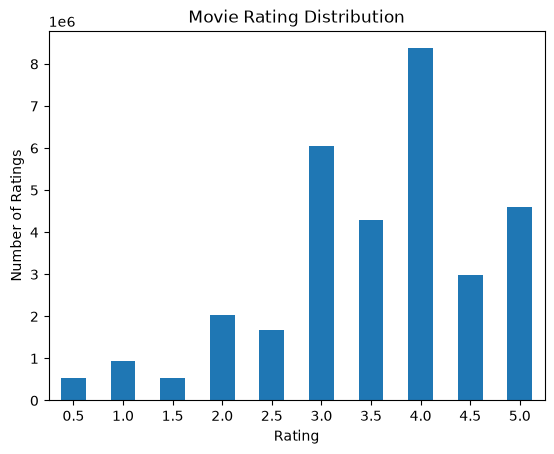

In [15]:
import matplotlib.pyplot as plt

rating_distribution.plot(kind="bar")

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.show()

### Observation

The rating distribution shows how user preferences are distributed across the available rating scale.

This helps identify whether ratings are concentrated around particular preference levels and provides useful information for later collaborative-filtering analysis.

## 10. Missing Value Analysis

Missing values can affect feature engineering and recommendation quality.

The movie metadata, ratings, tags, and links datasets are checked separately for missing values.

In [16]:
print("Missing values in movies:")
display(movies.isnull().sum())

print("\nMissing values in ratings:")
display(ratings.isnull().sum())

print("\nMissing values in tags:")
display(tags.isnull().sum())

print("\nMissing values in links:")
display(links.isnull().sum())

Missing values in movies:


movieId    0
title      0
genres     0
dtype: int64


Missing values in ratings:


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


Missing values in tags:


userId        0
movieId       0
tag          17
timestamp     0
dtype: int64


Missing values in links:


movieId      0
imdbId       0
tmdbId     124
dtype: int64

### Observation

Missing-value analysis identifies incomplete fields in the MovieLens datasets.

Fields with missing values will be handled during the data-cleaning and preprocessing phase.

No records are removed during the initial inspection phase.

## 11. Duplicate Record Analysis

Duplicate records are checked to determine whether repeated observations exist in the datasets.

In [17]:
print("Duplicate movie records:", movies.duplicated().sum())
print("Duplicate rating records:", ratings.duplicated().sum())
print("Duplicate tag records:", tags.duplicated().sum())
print("Duplicate link records:", links.duplicated().sum())

Duplicate movie records: 0


Duplicate rating records: 0


Duplicate tag records: 0
Duplicate link records: 0


### Observation

Duplicate analysis determines whether repeated records are present.

The results will be considered during the subsequent preprocessing phase before model training.

## 12. User Interaction Analysis

Understanding user activity is important for collaborative filtering because users provide the interaction history from which personalized preferences can be learned.

In [18]:
ratings_per_user = ratings.groupby("userId").size()

print("Average ratings per user:", ratings_per_user.mean())
print("Median ratings per user:", ratings_per_user.median())
print("Minimum ratings by a user:", ratings_per_user.min())
print("Maximum ratings by a user:", ratings_per_user.max())

Average ratings per user: 159.24619304496684
Median ratings per user: 73.0
Minimum ratings by a user: 20
Maximum ratings by a user: 33332


### Observation

Users have different levels of interaction with the movie catalog.

Users with more historical ratings provide stronger preference signals for collaborative filtering, while users with very few interactions may contribute to the cold-start challenge.

## 13. Movie Interaction Analysis

This section measures how frequently users interact with individual movies.

In [19]:
ratings_per_movie = ratings.groupby("movieId").size()

print("Average ratings per movie:", ratings_per_movie.mean())
print("Median ratings per movie:", ratings_per_movie.median())
print("Minimum ratings for a movie:", ratings_per_movie.min())
print("Maximum ratings for a movie:", ratings_per_movie.max())

Average ratings per movie: 379.0056376729202
Median ratings per movie: 5.0
Minimum ratings for a movie: 1
Maximum ratings for a movie: 102929


### Observation

Movie interaction frequency varies across the catalog.

Movies with many ratings have stronger collaborative signals, whereas movies with fewer interactions may require content-based information to improve recommendation quality.

## 14. Most Interacted Movies

The most frequently rated movies are identified to understand the popularity distribution in the dataset.

In [20]:
movie_rating_counts = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="rating_count")
    .sort_values("rating_count", ascending=False)
)

top_movies = (
    movie_rating_counts
    .merge(movies[["movieId", "title"]], on="movieId", how="left")
    .head(10)
)

display(top_movies)

,movieId,rating_count,title
0,318,102929,"Shawshank Redemption, The (1994)"
1,356,100296,Forrest Gump (1994)
2,296,98409,Pulp Fiction (1994)
3,2571,93808,"Matrix, The (1999)"
4,593,90330,"Silence of the Lambs, The (1991)"
5,260,85010,Star Wars: Episode IV - A New Hope (1977)
6,2959,77332,Fight Club (1999)
7,480,75233,Jurassic Park (1993)
8,527,73849,Schindler's List (1993)
9,4993,73122,"Lord of the Rings: The Fellowship of the Ring,..."


### Observation

The most interacted movies receive substantially more user ratings than less frequently rated movies.

This popularity information can support ranking and baseline recommendation strategies, while the final APEX system will combine popularity with personalized recommendation signals.

## 15. User-Item Interaction Sparsity

Collaborative filtering uses a user-item interaction matrix.

However, most users interact with only a small portion of the available movies.

This creates sparsity in the user-item matrix, which is an important consideration when designing the collaborative recommendation model.

In [21]:
num_users = ratings["userId"].nunique()
num_movies = ratings["movieId"].nunique()
num_interactions = len(ratings)

possible_interactions = num_users * num_movies

sparsity = 1 - (
    num_interactions / possible_interactions
)

print("Unique users:", num_users)
print("Unique movies:", num_movies)
print("Observed interactions:", num_interactions)
print("Possible interactions:", possible_interactions)
print("Sparsity:", sparsity)
print("Sparsity percentage:", sparsity * 100)

Unique users: 200948
Unique movies: 84432
Observed interactions: 32000204
Possible interactions: 16966441536
Sparsity: 0.9981139118693746
Sparsity percentage: 99.81139118693746


### Observation

The user-movie interaction matrix is expected to be highly sparse because each user interacts with only a small subset of the available movie catalog.

This observation supports the use of collaborative filtering techniques that can learn latent preference patterns while also motivating a hybrid approach that incorporates movie content features.

## 16. Movie Genre Analysis

Genre information provides content-level information about movies.

It will later be used as an important feature for the content-based recommendation component.

In [22]:
genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

display(genre_counts.head(20))

genres
Drama                 34175
Comedy                23124
Thriller              11823
Romance               10369
Action                 9668
Documentary            9363
Horror                 8654
(no genres listed)     7080
Crime                  6976
Adventure              5402
Sci-Fi                 4907
Animation              4617
Children               4520
Mystery                4013
Fantasy                3851
War                    2325
Western                1696
Musical                1059
Film-Noir               353
IMAX                    195
Name: count, dtype: int64

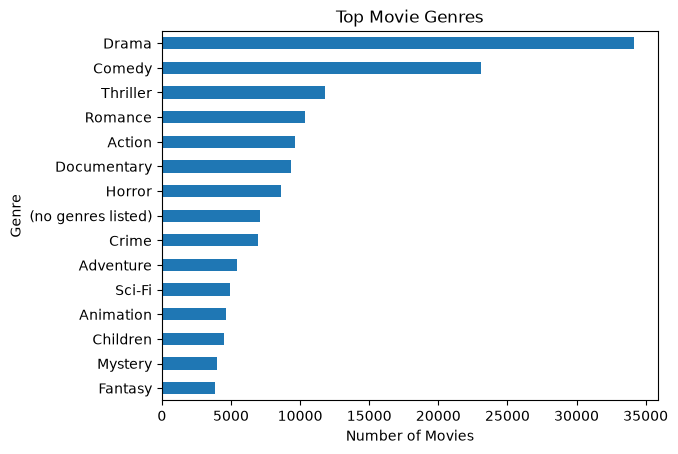

In [23]:
genre_counts.head(15).sort_values().plot(kind="barh")

plt.title("Top Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

### Observation

The movie catalog contains multiple genres with different frequencies.

Genre information provides a useful content signal for measuring similarity between movies and will be incorporated into the content-based recommendation component.

## 17. Movie Tag Analysis

User-generated tags provide additional semantic information about movies.

Tags can potentially improve content representation beyond predefined genres.

In [24]:
print("Number of unique tags:", tags["tag"].nunique())

display(
    tags["tag"]
    .value_counts()
    .head(20)
)

Number of unique tags: 140979


tag
sci-fi                10996
atmospheric            9589
action                 8473
comedy                 8139
funny                  7467
surreal                7231
visually appealing     7090
based on a book        6617
twist ending           6521
dark comedy            6053
thought-provoking      6000
dystopia               5646
violence               5389
cinematography         5277
romance                5271
murder                 5180
social commentary      5152
stylized               4917
fantasy                4844
psychology             4827
Name: count, dtype: int64

### Observation

User-generated tags provide additional semantic signals about movie characteristics and user perception.

These signals may be considered during feature engineering if they provide sufficient coverage and useful information.

# Phase 2 — Movie Data Cleaning

The MovieLens dataset has been inspected in the previous phase.

This phase prepares the raw movie data for exploratory analysis and machine-learning model development.

The cleaning process includes:

- Schema validation
- Data type validation
- Missing-value analysis
- Duplicate detection
- Rating validation
- User and movie ID validation
- Movie title cleaning
- Genre normalization
- Timestamp conversion
- Interaction filtering

The original raw datasets are preserved and are not overwritten.

## 18.2 Movie Data Cleaning Workflow

```text
                 RAW MOVIELENS DATA
                         │
                         ↓
                 Schema Validation
                         │
                         ↓
                  Data Type Check
                         │
                         ↓
                 Missing Values
                         │
                         ↓
                   Duplicates
                         │
                         ↓
                 Rating Validation
                         │
                         ↓
              User/Movie ID Validation
                         │
                         ↓
                Title Normalization
                         │
                         ↓
                 Genre Normalization
                         │
                         ↓
              Timestamp Transformation
                         │
                         ↓
               Interaction Filtering
                         │
                         ↓
                  CLEAN DATASET


---

# 18.3 — Load Raw MovieLens Data

### 📝 Markdown

```markdown
## 18.3 Loading the Raw MovieLens Dataset

The original MovieLens files are loaded into separate DataFrames.

The raw DataFrames are retained so that the cleaned data can always be compared against the original data.

In [25]:
movies_raw = movies.copy()
ratings_raw = ratings.copy()
tags_raw = tags.copy()
links_raw = links.copy()

print("Raw datasets copied successfully.")

print("Movies:", movies_raw.shape)
print("Ratings:", ratings_raw.shape)
print("Tags:", tags_raw.shape)
print("Links:", links_raw.shape)

Raw datasets copied successfully.
Movies: (87585, 3)
Ratings: (32000204, 4)
Tags: (2000072, 4)
Links: (87585, 3)


### Observation

Separate copies of the original datasets have been created.

This preserves the raw data and allows all preprocessing decisions to be reproduced and validated later.

## 18.4 Schema Validation

Before cleaning the data, the expected columns of each MovieLens dataset are verified.

Schema validation ensures that required fields are available before further processing.

In [26]:
print("Movies columns:")
print(movies.columns.tolist())

print("\nRatings columns:")
print(ratings.columns.tolist())

print("\nTags columns:")
print(tags.columns.tolist())

print("\nLinks columns:")
print(links.columns.tolist())

Movies columns:
['movieId', 'title', 'genres']

Ratings columns:
['userId', 'movieId', 'rating', 'timestamp']

Tags columns:
['userId', 'movieId', 'tag', 'timestamp']

Links columns:
['movieId', 'imdbId', 'tmdbId']


In [27]:
required_movie_columns = {"movieId", "title", "genres"}
required_rating_columns = {"userId", "movieId", "rating", "timestamp"}
required_tag_columns = {"userId", "movieId", "tag", "timestamp"}
required_link_columns = {"movieId", "imdbId", "tmdbId"}

print("Missing movie columns:",
      required_movie_columns - set(movies.columns))

print("Missing rating columns:",
      required_rating_columns - set(ratings.columns))

print("Missing tag columns:",
      required_tag_columns - set(tags.columns))

print("Missing link columns:",
      required_link_columns - set(links.columns))

Missing movie columns: set()
Missing rating columns: set()
Missing tag columns: set()
Missing link columns: set()


### Observation

Schema validation confirms whether the required MovieLens fields are available.

A missing required field would affect downstream feature engineering or model development and must therefore be identified before cleaning continues.

## 18.6 Data Type Validation

Correct data types are necessary for reliable statistical analysis and machine-learning preprocessing.

In [28]:
print("Movies data types:")
display(movies.dtypes)

print("\nRatings data types:")
display(ratings.dtypes)

print("\nTags data types:")
display(tags.dtypes)

print("\nLinks data types:")
display(links.dtypes)

Movies data types:


movieId    int64
title        str
genres       str
dtype: object


Ratings data types:


userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object


Tags data types:


userId       int64
movieId      int64
tag            str
timestamp    int64
dtype: object


Links data types:


movieId      int64
imdbId       int64
tmdbId     float64
dtype: object

In [29]:
movies["movieId"] = pd.to_numeric(
    movies["movieId"],
    errors="coerce"
)

ratings["userId"] = pd.to_numeric(
    ratings["userId"],
    errors="coerce"
)

ratings["movieId"] = pd.to_numeric(
    ratings["movieId"],
    errors="coerce"
)

tags["userId"] = pd.to_numeric(
    tags["userId"],
    errors="coerce"
)

tags["movieId"] = pd.to_numeric(
    tags["movieId"],
    errors="coerce"
)

links["movieId"] = pd.to_numeric(
    links["movieId"],
    errors="coerce"
)

In [30]:
print("Missing movie IDs:", movies["movieId"].isna().sum())
print("Missing rating user IDs:", ratings["userId"].isna().sum())
print("Missing rating movie IDs:", ratings["movieId"].isna().sum())
print("Missing tag user IDs:", tags["userId"].isna().sum())
print("Missing tag movie IDs:", tags["movieId"].isna().sum())

Missing movie IDs: 0
Missing rating user IDs: 0
Missing rating movie IDs: 0
Missing tag user IDs: 0
Missing tag movie IDs: 0


### Observation

Identifier validation checks whether user and movie identifiers contain invalid or missing values.

These identifiers are fundamental to constructing the user-item interaction matrix and joining metadata with ratings.

## 18.9 Missing Value Analysis

Missing values are examined after data-type normalization.

Different fields require different handling strategies depending on their role in the recommendation system.

In [31]:
print("Movies missing values:")
display(movies.isnull().sum())

print("\nRatings missing values:")
display(ratings.isnull().sum())

print("\nTags missing values:")
display(tags.isnull().sum())

print("\nLinks missing values:")
display(links.isnull().sum())

Movies missing values:


movieId    0
title      0
genres     0
dtype: int64


Ratings missing values:


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


Tags missing values:


userId        0
movieId       0
tag          17
timestamp     0
dtype: int64


Links missing values:


movieId      0
imdbId       0
tmdbId     124
dtype: int64

In [32]:
before = len(movies)

movies = movies.dropna(
    subset=["movieId"]
).copy()

print("Movie records removed:", before - len(movies))
print("Movies remaining:", len(movies))

Movie records removed: 0
Movies remaining: 87585


## 18.11 Rating Validation

MovieLens ratings represent explicit user preferences.

Ratings outside the valid rating scale are treated as invalid records.

The valid rating range is determined from the MovieLens dataset specification.

In [33]:
print("Minimum rating:", ratings["rating"].min())
print("Maximum rating:", ratings["rating"].max())

invalid_ratings = ratings[
    (ratings["rating"] < 0.5) |
    (ratings["rating"] > 5.0)
]

print("Invalid rating records:", len(invalid_ratings))

Minimum rating: 0.5
Maximum rating: 5.0


Invalid rating records: 0


### Observation

The rating range is checked before model training.

Invalid ratings, if present, could distort rating prediction and recommendation evaluation and therefore must be handled during preprocessing.

In [34]:
ratings = ratings[
    (ratings["rating"] >= 0.5) &
    (ratings["rating"] <= 5.0)
].copy()

print("Clean ratings shape:", ratings.shape)

Clean ratings shape: (32000204, 4)


## 18.13 Duplicate Interaction Analysis

Duplicate user-movie-rating interactions can artificially increase the importance of an interaction.

Duplicate records are therefore identified before constructing recommendation matrices.

In [35]:
print("Duplicate movie records:", movies.duplicated().sum())
print("Duplicate rating records:", ratings.duplicated().sum())
print("Duplicate tag records:", tags.duplicated().sum())
print("Duplicate link records:", links.duplicated().sum())

Duplicate movie records: 0


Duplicate rating records: 0


Duplicate tag records: 0
Duplicate link records: 0


In [36]:
movies = movies.drop_duplicates().copy()
ratings = ratings.drop_duplicates().copy()
tags = tags.drop_duplicates().copy()
links = links.drop_duplicates().copy()

print("Duplicates removed.")

Duplicates removed.


### Observation

Exact duplicate records have been removed to prevent repeated observations from biasing downstream analysis.

Only exact duplicate rows are removed at this stage.

## 18.15 Movie ID Consistency

Ratings must refer to movies that exist in the movie metadata table.

This validation prevents orphan interactions from entering the recommendation model.

In [37]:
valid_movie_ids = set(movies["movieId"])

invalid_rating_movie_ids = ~ratings["movieId"].isin(
    valid_movie_ids
)

print(
    "Ratings referring to unknown movies:",
    invalid_rating_movie_ids.sum()
)

Ratings referring to unknown movies: 0


In [38]:
ratings = ratings[
    ratings["movieId"].isin(valid_movie_ids)
].copy()

print("Ratings after movie ID validation:", ratings.shape)

Ratings after movie ID validation: (32000204, 4)


### Observation

Only rating interactions associated with valid movie metadata are retained.

This ensures that every interaction used by the recommendation model can be connected to corresponding movie information.

In [39]:
print("Number of unique users:", ratings["userId"].nunique())
print("Minimum user ID:", ratings["userId"].min())
print("Maximum user ID:", ratings["userId"].max())

Number of unique users: 200948
Minimum user ID: 1


Maximum user ID: 200948


## 18.18 Movie Title Normalization

Movie titles are important content features for the content-based recommendation model.

Basic normalization is applied while preserving the original movie meaning.

In [40]:
movies["title"] = (
    movies["title"]
    .astype(str)
    .str.strip()
)

In [41]:
display(movies[["movieId", "title"]].head(10))

,movieId,title
0,1,Toy Story (1995)
1,2,Jumanji (1995)
2,3,Grumpier Old Men (1995)
3,4,Waiting to Exhale (1995)
4,5,Father of the Bride Part II (1995)
5,6,Heat (1995)
6,7,Sabrina (1995)
7,8,Tom and Huck (1995)
8,9,Sudden Death (1995)
9,10,GoldenEye (1995)


## 18.19 Genre Normalization

Movie genres are represented as pipe-separated values.

The genre strings are normalized so that they can later be transformed into machine-learning features.

In [42]:
movies["genres"] = (
    movies["genres"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s*\|\s*", "|", regex=True)
)

display(
    movies[["movieId", "title", "genres"]].head(10)
)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [43]:
unknown_genres = movies[
    movies["genres"].str.contains(
        r"^\(no genres listed\)$",
        regex=True,
        na=False
    )
]

print(
    "Movies with no listed genres:",
    len(unknown_genres)
)

Movies with no listed genres: 7080


### Observation

Movies without listed genres cannot contribute genre-based similarity directly.

These records will not automatically be deleted because their titles and rating interactions may still provide useful recommendation information.

## 18.21 Timestamp Transformation

MovieLens timestamps are stored as Unix timestamps.

They are converted into datetime format to support temporal analysis and time-aware feature engineering.

In [44]:
ratings["timestamp"] = pd.to_datetime(
    ratings["timestamp"],
    unit="s"
)

tags["timestamp"] = pd.to_datetime(
    tags["timestamp"],
    unit="s"
)

display(ratings.head())

,userId,movieId,rating,timestamp
0,1,17,4.0,1999-12-03 19:24:37
1,1,25,1.0,1999-12-03 19:43:48
2,1,29,2.0,1999-11-22 00:36:16
3,1,30,5.0,1999-12-03 19:24:37
4,1,32,5.0,1999-11-22 00:00:58


In [45]:
ratings["rating_year"] = ratings["timestamp"].dt.year
ratings["rating_month"] = ratings["timestamp"].dt.month

display(
    ratings[
        ["userId", "movieId", "rating", "timestamp",
         "rating_year", "rating_month"]
    ].head()
)

,userId,movieId,rating,timestamp,rating_year,rating_month
0,1,17,4.0,1999-12-03 19:24:37,1999,12
1,1,25,1.0,1999-12-03 19:43:48,1999,12
2,1,29,2.0,1999-11-22 00:36:16,1999,11
3,1,30,5.0,1999-12-03 19:24:37,1999,12
4,1,32,5.0,1999-11-22 00:00:58,1999,11


## 18.23 User Interaction Filtering

Collaborative filtering performs better when interaction histories contain sufficient information.

Users with extremely few interactions can create weak preference signals.

A minimum interaction threshold will therefore be investigated rather than arbitrarily removing users.

In [46]:
user_activity = ratings.groupby("userId").size()

print("Minimum user interactions:", user_activity.min())
print("Median user interactions:", user_activity.median())
print("Maximum user interactions:", user_activity.max())

Minimum user interactions: 20
Median user interactions: 73.0
Maximum user interactions: 33332


In [47]:
movie_activity = ratings.groupby("movieId").size()

print("Minimum movie interactions:", movie_activity.min())
print("Median movie interactions:", movie_activity.median())
print("Maximum movie interactions:", movie_activity.max())

Minimum movie interactions: 1
Median movie interactions: 5.0
Maximum movie interactions: 102929


In [48]:
print("MOVIE CLEANING SUMMARY")
print("=" * 60)

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)
print("Links:", links.shape)

print("\nUnique users:", ratings["userId"].nunique())
print("Unique movies:", ratings["movieId"].nunique())

print("\nAverage rating:", ratings["rating"].mean())
print("Minimum rating:", ratings["rating"].min())
print("Maximum rating:", ratings["rating"].max())

MOVIE CLEANING SUMMARY
Movies: (87585, 3)
Ratings: (32000204, 6)
Tags: (2000072, 4)
Links: (87585, 3)

Unique users: 200948


Unique movies: 84432

Average rating: 3.5403956487277393
Minimum rating: 0.5
Maximum rating: 5.0


In [49]:
print("BEFORE CLEANING")
print("-" * 40)
print("Movies:", movies_raw.shape)
print("Ratings:", ratings_raw.shape)
print("Tags:", tags_raw.shape)
print("Links:", links_raw.shape)

print("\nAFTER CLEANING")
print("-" * 40)
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)
print("Links:", links.shape)

BEFORE CLEANING
----------------------------------------
Movies: (87585, 3)
Ratings: (32000204, 4)
Tags: (2000072, 4)
Links: (87585, 3)

AFTER CLEANING
----------------------------------------
Movies: (87585, 3)
Ratings: (32000204, 6)
Tags: (2000072, 4)
Links: (87585, 3)


## 18.27 Final Movie Cleaning Flow

```text
RAW MOVIELENS
      │
      ↓
Schema Validation
      │
      ↓
Data Type Validation
      │
      ↓
Missing Values
      │
      ↓
Duplicate Removal
      │
      ↓
Rating Validation
      │
      ↓
Movie ID Validation
      │
      ↓
Title Normalization
      │
      ↓
Genre Normalization
      │
      ↓
Timestamp Conversion
      │
      ↓
Interaction Analysis
      │
      ↓
CLEAN MOVIELENS


---

# 18.28 — Final Observation

### Markdown

```markdown
## 18.28 Movie Data Cleaning — Final Observation

The MovieLens datasets have been validated and prepared for machine-learning analysis.

The cleaning process preserved the original datasets while creating validated working DataFrames.

The cleaned data now provides a consistent foundation for:

- Statistical analysis
- Exploratory data analysis
- Feature engineering
- Rating prediction
- Collaborative filtering
- Content-based recommendation
- Hybrid recommendation

The next phase will focus on deeper exploratory data analysis and visualization of the cleaned MovieLens dataset.

# Phase 3 — Movie Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed on the cleaned MovieLens dataset to understand user behavior, movie popularity, rating patterns, genre distribution, temporal trends, and the structure of the user-movie interaction data.

The objective is to identify meaningful patterns that can guide feature engineering and recommendation-model design.

EDA does not train the final recommendation model. It is used to understand the data before modeling.

## 19.2 EDA Workflow

```text
                 CLEAN MOVIELENS
                       │
          ┌────────────┼────────────┐
          ↓            ↓            ↓
       RATINGS       USERS        MOVIES
          │            │            │
          ↓            ↓            ↓
     Distribution   Activity     Popularity
          │            │            │
          └────────────┼────────────┘
                       ↓
                  GENRE ANALYSIS
                       ↓
                TEMPORAL ANALYSIS
                       ↓
                CORRELATION STUDY
                       ↓
                SPARSITY ANALYSIS
                       ↓
             MODELING INSIGHTS

In [50]:
movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)
tags = pd.read_csv(TAGS_FILE)
links = pd.read_csv(LINKS_FILE)

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
print("Tags shape:", tags.shape)
print("Links shape:", links.shape)

Movies shape: (87585, 3)
Ratings shape: (32000204, 4)
Tags shape: (2000072, 4)
Links shape: (87585, 3)


### Observation

The cleaned MovieLens dataset contains a large number of user-movie interactions.

The average and median ratings provide an initial indication of the overall preference tendency of users, while the standard deviation indicates the variability in ratings.

## 19.4 Rating Distribution

The rating distribution shows how frequently users assign different rating values.

This is important because a highly concentrated rating distribution can affect rating prediction models and recommendation ranking.

In [51]:
rating_counts = (
    ratings["rating"]
    .value_counts()
    .sort_index()
)

display(rating_counts)

rating
0.5     525132
1.0     946675
1.5     531063
2.0    2028622
2.5    1685386
3.0    6054990
3.5    4290105
4.0    8367654
4.5    2974000
5.0    4596577
Name: count, dtype: int64

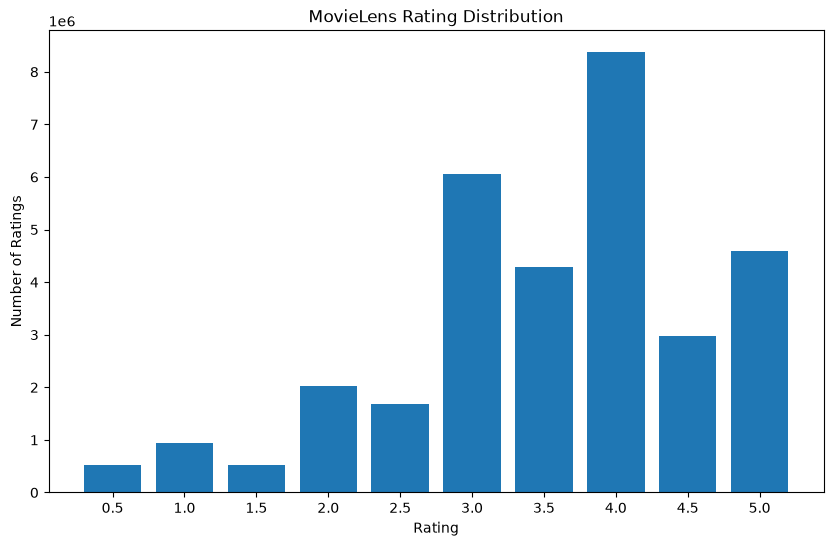

In [52]:
plt.figure(figsize=(10, 6))

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.title("MovieLens Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

### Observation

The rating distribution reveals which rating values are most frequently used by users.

The distribution will be considered when selecting rating-prediction baselines and interpreting model errors.

## 19.5 Rating Variability and Outlier Analysis

A box plot is used to visualize the central tendency, spread, and potential outliers of movie ratings.

/var/folders/bt/ss_t404n6b973mpv1hx2ykdr0000gn/T/ipykernel_11543/3012552253.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


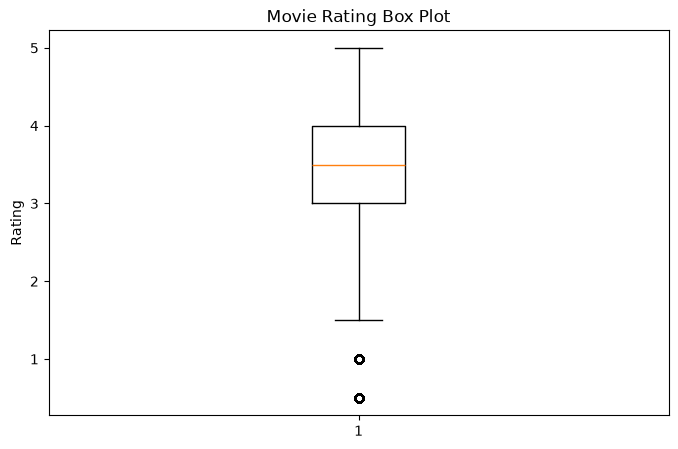

In [53]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    ratings["rating"],
    vert=True
)

plt.title("Movie Rating Box Plot")
plt.ylabel("Rating")

plt.show()

### Observation

The box plot summarizes the central distribution of ratings and identifies unusually low or high observations.

The rating scale itself is bounded, so extreme values should be interpreted within the valid MovieLens rating range.

## 19.6 User Activity Distribution

User activity is measured by the number of ratings submitted by each user.

This analysis helps identify highly active users and users with limited interaction history.

In [54]:
ratings_per_user = (
    ratings.groupby("userId")
    .size()
)

print("Minimum:", ratings_per_user.min())
print("Maximum:", ratings_per_user.max())
print("Mean:", ratings_per_user.mean())
print("Median:", ratings_per_user.median())

Minimum: 20
Maximum: 33332
Mean: 159.24619304496684
Median: 73.0


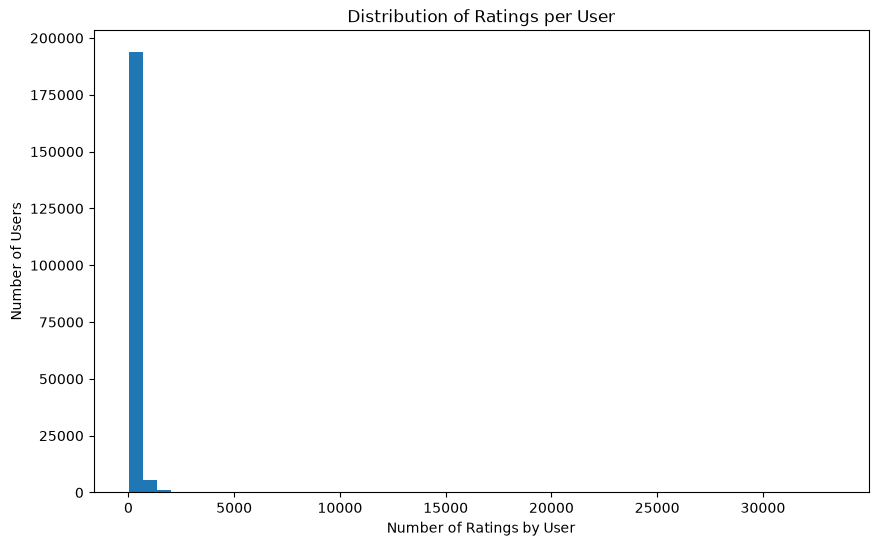

In [55]:
plt.figure(figsize=(10, 6))

plt.hist(
    ratings_per_user,
    bins=50
)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings by User")
plt.ylabel("Number of Users")

plt.show()

/var/folders/bt/ss_t404n6b973mpv1hx2ykdr0000gn/T/ipykernel_11543/4190617004.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


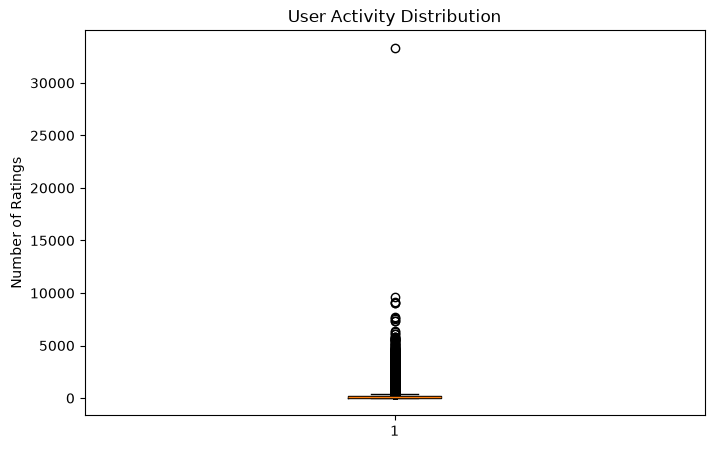

In [56]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    ratings_per_user,
    vert=True
)

plt.title("User Activity Distribution")
plt.ylabel("Number of Ratings")

plt.show()

### Observation

User activity is unevenly distributed.

Some users contribute substantially more interactions than others.

This imbalance is important for collaborative filtering because highly active users provide stronger preference histories, while users with limited histories contribute weaker personalization signals.

In [57]:
top_users = (
    ratings_per_user
    .sort_values(ascending=False)
    .head(10)
)

display(
    top_users.reset_index(
        name="rating_count"
    )
)

,userId,rating_count
0,175325,33332
1,17035,9577
2,55653,9178
3,123465,9044
4,171795,9016
5,10202,7748
6,198515,7594
7,49305,7488
8,22744,7372
9,7858,7322


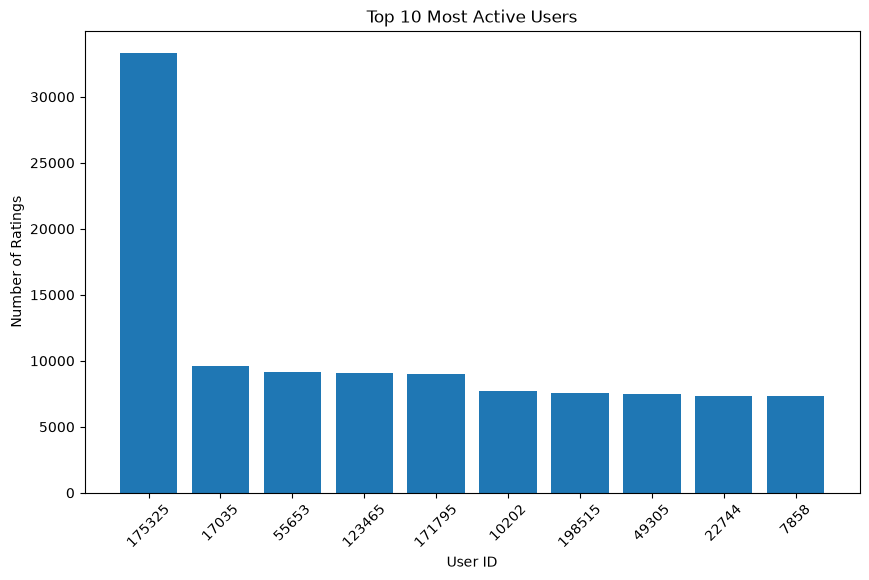

In [58]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_users.index.astype(str),
    top_users.values
)

plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")

plt.xticks(rotation=45)

plt.show()

### Observation

A small group of users may contribute a large number of interactions.

Such users can strongly influence collaborative-filtering models and should be considered when analyzing popularity and user-activity bias.

## 19.9 Movie Popularity Distribution

Movie popularity is measured using the number of ratings received by each movie.

This helps identify the difference between highly popular movies and the long tail of less-interacted movies.

In [59]:
ratings_per_movie = (
    ratings.groupby("movieId")
    .size()
)

print("Minimum:", ratings_per_movie.min())
print("Maximum:", ratings_per_movie.max())
print("Mean:", ratings_per_movie.mean())
print("Median:", ratings_per_movie.median())

Minimum: 1
Maximum: 102929
Mean: 379.0056376729202
Median: 5.0


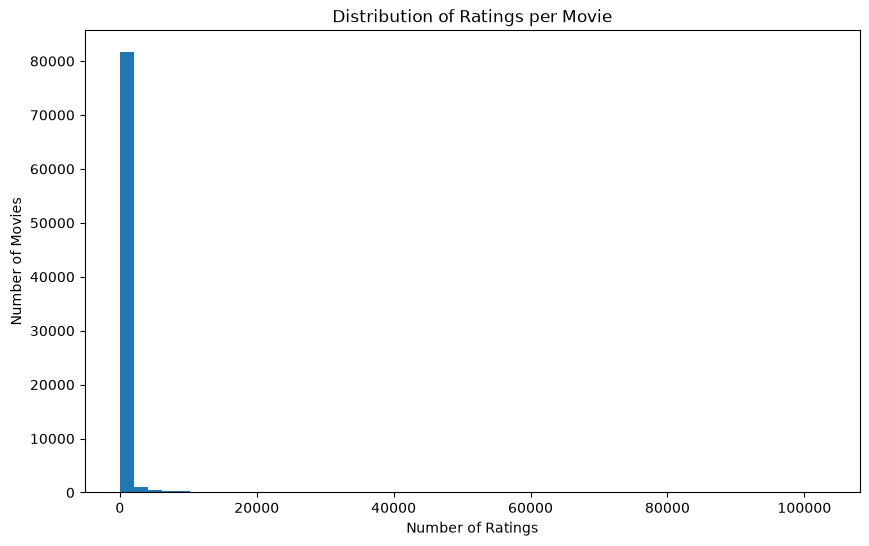

In [60]:
plt.figure(figsize=(10, 6))

plt.hist(
    ratings_per_movie,
    bins=50
)

plt.title("Distribution of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")

plt.show()

## 19.10 Movie Popularity and Long-Tail Analysis

Recommendation datasets often contain a small number of highly popular items and a large number of less popular items.

This phenomenon is known as the long-tail distribution.

Understanding the long tail is important because a recommendation system that recommends only popular movies may have high exposure but poor catalog coverage and personalization.

In [61]:
movie_popularity = (
    ratings.groupby("movieId")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="rating_count")
)

movie_popularity["rank"] = (
    np.arange(1, len(movie_popularity) + 1)
)

display(movie_popularity.head(10))

,movieId,rating_count,rank
0,318,102929,1
1,356,100296,2
2,296,98409,3
3,2571,93808,4
4,593,90330,5
5,260,85010,6
6,2959,77332,7
7,480,75233,8
8,527,73849,9
9,4993,73122,10


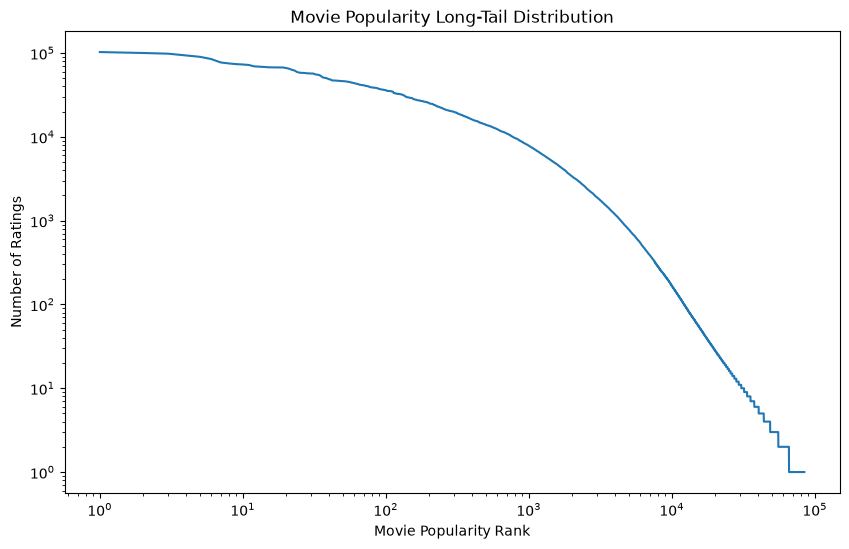

In [62]:
plt.figure(figsize=(10, 6))

plt.plot(
    movie_popularity["rank"],
    movie_popularity["rating_count"]
)

plt.title("Movie Popularity Long-Tail Distribution")
plt.xlabel("Movie Popularity Rank")
plt.ylabel("Number of Ratings")

plt.yscale("log")
plt.xscale("log")

plt.show()

### Observation

Movie popularity follows a long-tail pattern in which a relatively small group of movies receives many interactions while a much larger number of movies receive fewer interactions.

This creates a popularity bias challenge.

The final APEX recommendation system should therefore balance personalized relevance with catalog coverage rather than recommending only globally popular movies.

In [63]:
top_movie_counts = (
    movie_popularity
    .head(20)
    .merge(
        movies[["movieId", "title"]],
        on="movieId",
        how="left"
    )
)

display(
    top_movie_counts[
        ["movieId", "title", "rating_count"]
    ]
)

,movieId,title,rating_count
0,318,"Shawshank Redemption, The (1994)",102929
1,356,Forrest Gump (1994),100296
2,296,Pulp Fiction (1994),98409
3,2571,"Matrix, The (1999)",93808
4,593,"Silence of the Lambs, The (1991)",90330
5,260,Star Wars: Episode IV - A New Hope (1977),85010
6,2959,Fight Club (1999),77332
7,480,Jurassic Park (1993),75233
8,527,Schindler's List (1993),73849
9,4993,"Lord of the Rings: The Fellowship of the Ring,...",73122


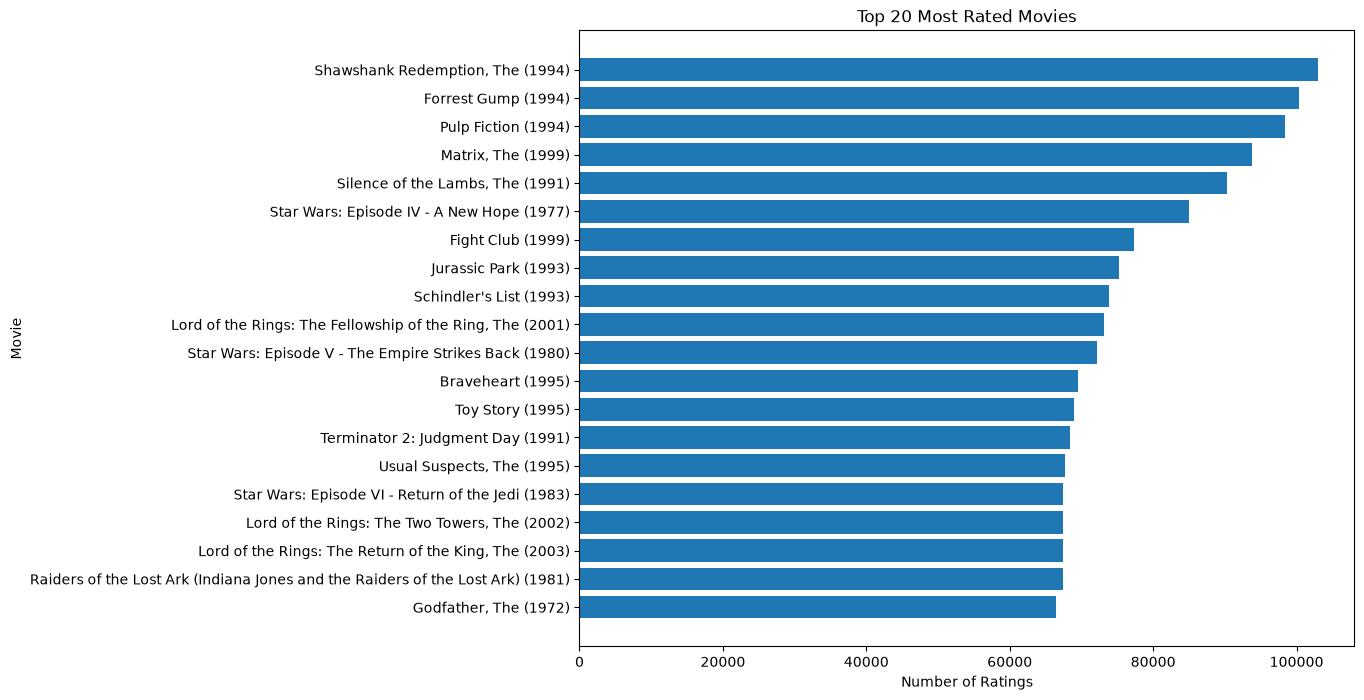

In [64]:
top20 = top_movie_counts.sort_values("rating_count")

plt.figure(figsize=(10, 8))

plt.barh(
    top20["title"],
    top20["rating_count"]
)

plt.title("Top 20 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.show()

## 19.12 Average Movie Rating

Average movie rating is calculated to understand perceived preference while considering the number of interactions separately.

Average rating alone should not be used as the final popularity measure because movies with very few ratings can obtain unstable averages.

In [65]:
movie_rating_stats = (
    ratings.groupby("movieId")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

display(
    movie_rating_stats.head()
)

,movieId,average_rating,rating_count
0,1,3.897438,68997
1,2,3.275758,28904
2,3,3.139447,13134
3,4,2.845331,2806
4,5,3.059602,13154


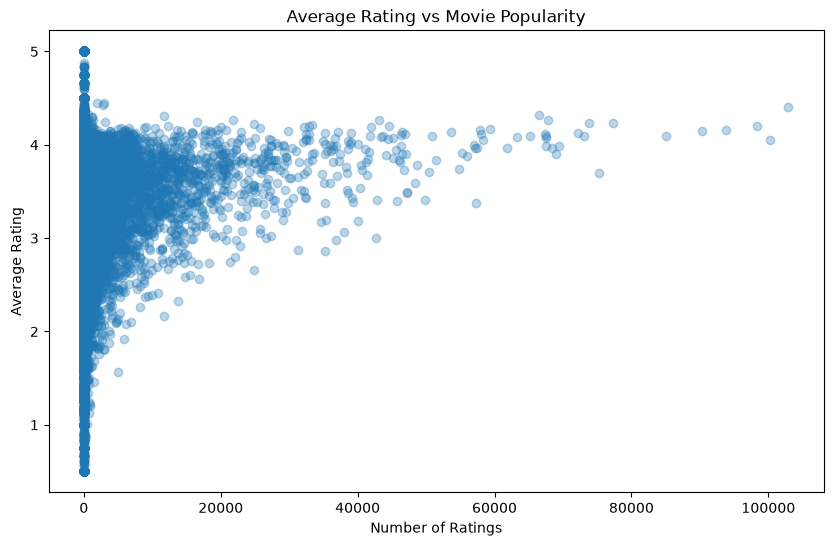

In [66]:
plt.figure(figsize=(10, 6))

plt.scatter(
    movie_rating_stats["rating_count"],
    movie_rating_stats["average_rating"],
    alpha=0.3
)

plt.title("Average Rating vs Movie Popularity")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")

plt.show()

### Observation

The relationship between average rating and rating count is not necessarily linear.

Movies with very few ratings can have unstable average ratings, while highly rated movies with large interaction counts provide more reliable preference signals.

Therefore, both rating quality and interaction volume should be considered when designing popularity-based baselines.

In [67]:
genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

display(genre_counts)

genres
Drama                 34175
Comedy                23124
Thriller              11823
Romance               10369
Action                 9668
Documentary            9363
Horror                 8654
(no genres listed)     7080
Crime                  6976
Adventure              5402
Sci-Fi                 4907
Animation              4617
Children               4520
Mystery                4013
Fantasy                3851
War                    2325
Western                1696
Musical                1059
Film-Noir               353
IMAX                    195
Name: count, dtype: int64

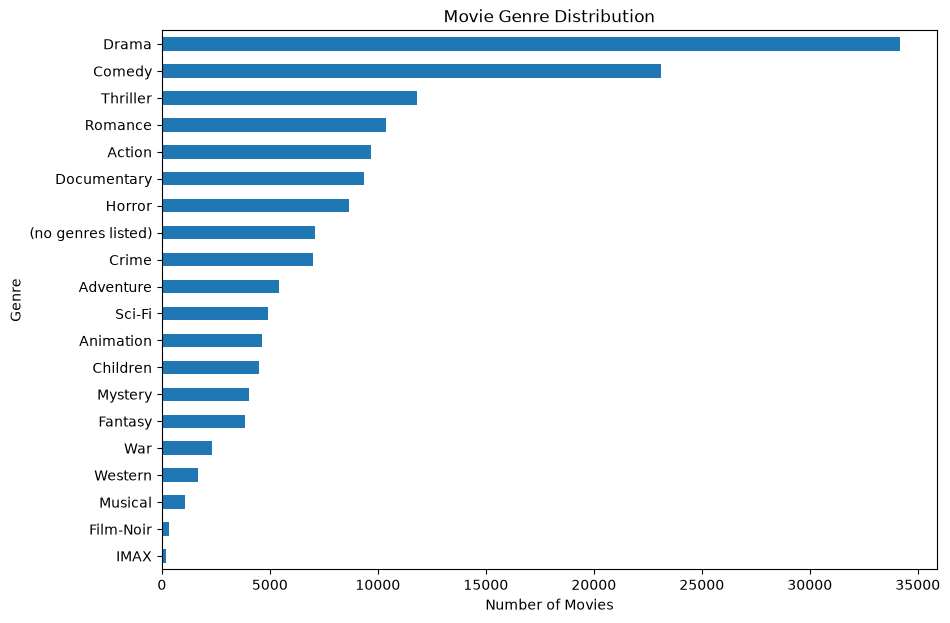

In [68]:
plt.figure(figsize=(10, 7))

genre_counts.head(20).sort_values().plot(
    kind="barh"
)

plt.title("Movie Genre Distribution")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

In [69]:
movie_genres = (
    movies[
        ["movieId", "genres"]
    ]
    .copy()
)

movie_genres["genre"] = (
    movie_genres["genres"]
    .str.split("|")
)

movie_genres = movie_genres.explode("genre")

genre_popularity = (
    movie_genres
    .merge(
        ratings[["movieId", "rating"]],
        on="movieId",
        how="inner"
    )
    .groupby("genre")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .sort_values(
        "rating_count",
        ascending=False
    )
)

display(genre_popularity.head(20))

,average_rating,rating_count
genre,,
Drama,3.682454,13973271
Comedy,3.432386,11206926
Action,3.476407,9665213
Thriller,3.531702,8679464
Adventure,3.523439,7590522
Sci-Fi,3.491699,5717337
Romance,3.545003,5524615
Crime,3.691771,5373051
Fantasy,3.512175,3702759


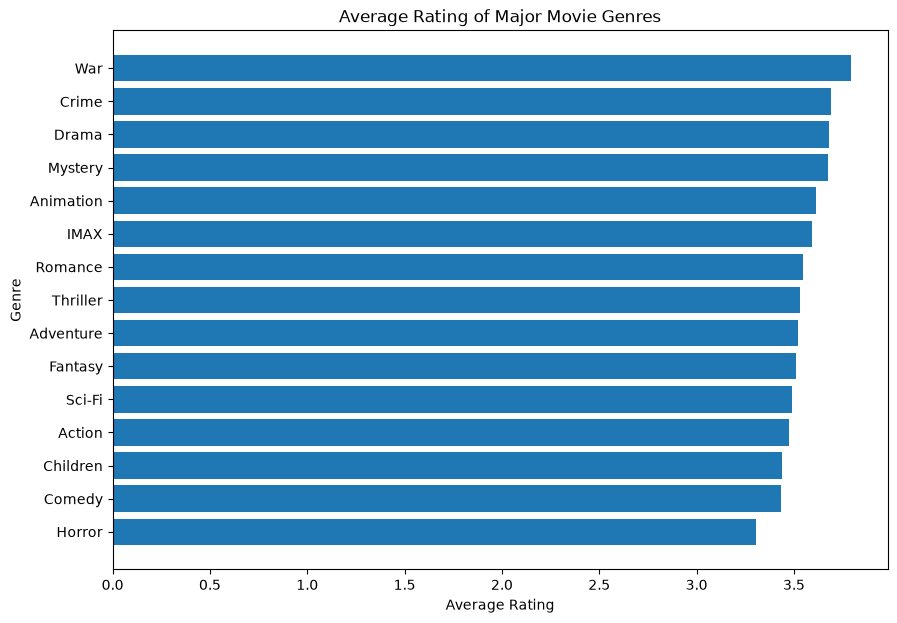

In [70]:
top_genres = (
    genre_popularity
    .head(15)
    .sort_values("average_rating")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_genres.index,
    top_genres["average_rating"]
)

plt.title("Average Rating of Major Movie Genres")
plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.show()

### Observation

Different genres exhibit different levels of representation and user interaction.

Genre information can therefore contribute to content-based recommendation, but genre popularity should not be confused with personalized user preference.

## 19.17 Temporal Rating Analysis

Rating timestamps are analyzed to identify changes in user activity over time.

Temporal patterns can reveal periods of higher or lower interaction activity and can provide useful context for future time-aware modeling.

In [71]:
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")

yearly_ratings = (
    ratings
    .groupby(ratings["timestamp"].dt.year)
    .size()
)

display(yearly_ratings)

timestamp
1995          4
1996    1571368
1997     685388
1998     301691
1999    1174629
2000    1912322
2001    1160098
2002     849762
2003    1011000
2004    1139068
2005    1752573
2006    1141704
2007    1023813
2008    1117071
2009     890696
2010     860073
2011     729301
2012     695493
2013     563301
2014     518537
2015    1743866
2016    1918739
2017    1827953
2018    1391057
2019    1385467
2020    1688159
2021    1239912
2022     913105
2023     794054
dtype: int64

In [72]:
ratings["timestamp"] = pd.to_datetime(
    ratings["timestamp"],
    unit="s",
    errors="coerce"
)

print(ratings["timestamp"].dtype)
print(ratings["timestamp"].head())

datetime64[s]
0   1999-12-03 19:24:37
1   1999-12-03 19:43:48
2   1999-11-22 00:36:16
3   1999-12-03 19:24:37
4   1999-11-22 00:00:58
Name: timestamp, dtype: datetime64[s]


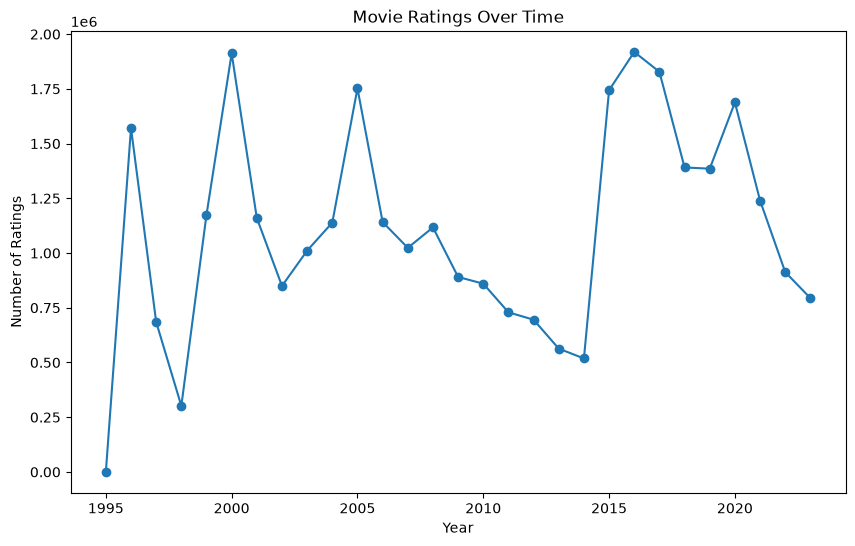

In [73]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_ratings.index,
    yearly_ratings.values,
    marker="o"
)

plt.title("Movie Ratings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")

plt.show()

## 19.18 Monthly Rating Activity

Monthly rating activity is analyzed to understand how user interactions are distributed across the months of the year.

This analysis helps identify recurring seasonal patterns in user engagement.

In [74]:
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")

monthly_ratings = (
    ratings
    .groupby(ratings["timestamp"].dt.month)
    .size()
)

display(monthly_ratings)

timestamp
1     2890840
2     2423642
3     2756958
4     2558728
5     2617166
6     2513454
7     2766421
8     2657719
9     2331584
10    2651946
11    2981127
12    2850619
dtype: int64

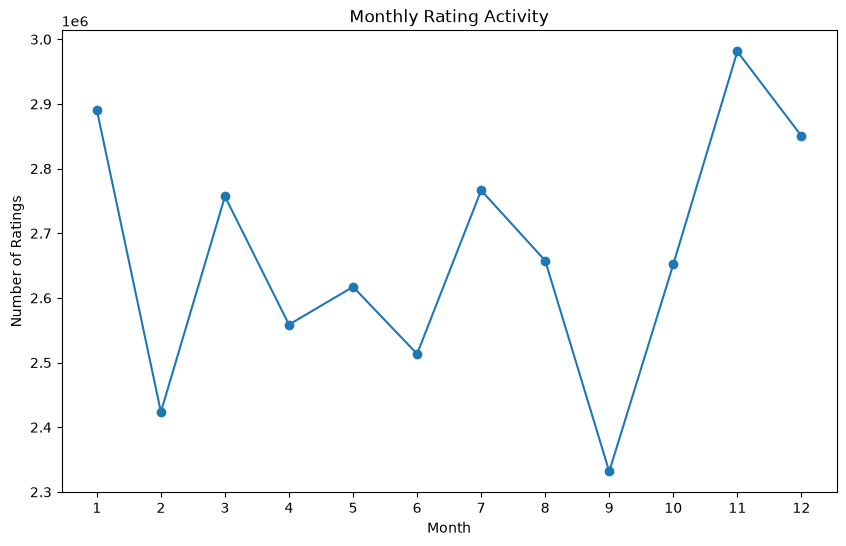

In [75]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_ratings.index,
    monthly_ratings.values,
    marker="o"
)

plt.title("Monthly Rating Activity")
plt.xlabel("Month")
plt.ylabel("Number of Ratings")
plt.xticks(range(1, 13))

plt.show()

### Observation

The monthly rating distribution shows how user activity varies across different months.

Any noticeable peaks or drops indicate differences in interaction activity during specific periods.

This analysis provides useful exploratory information but does not by itself imply a causal seasonal effect.

## 19.19 Average Rating Over Time

The average rating for each year is calculated to determine whether the overall rating behavior of users changes over time.

In [76]:
yearly_average_rating = (
    ratings
    .groupby(ratings["timestamp"].dt.year)["rating"]
    .mean()
)

display(yearly_average_rating)

timestamp
1995    3.750000
1996    3.546181
1997    3.588810
1998    3.514003
1999    3.616688
2000    3.576486
2001    3.533513
2002    3.484735
2003    3.473930
2004    3.430688
2005    3.434048
2006    3.465750
2007    3.470483
2008    3.540774
2009    3.507094
2010    3.533963
2011    3.562168
2012    3.608984
2013    3.645403
2014    3.611611
2015    3.559331
2016    3.536441
2017    3.548444
2018    3.570690
2019    3.578934
2020    3.598791
2021    3.582822
2022    3.499670
2023    3.569507
Name: rating, dtype: float64

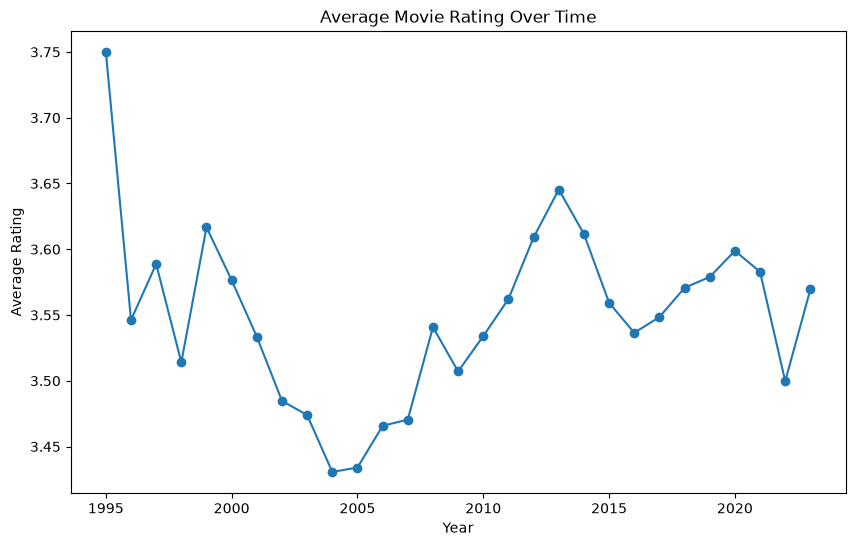

In [77]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_average_rating.index,
    yearly_average_rating.values,
    marker="o"
)

plt.title("Average Movie Rating Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.show()

### Observation

The yearly average rating provides a view of changes in overall rating behavior over time.

Small variations may occur because the set of movies and users contributing ratings changes across different periods.

## 19.20 Rating Count vs Average Rating

This analysis investigates whether movies with a larger number of ratings tend to have systematically different average ratings.

Rating count represents popularity, while average rating represents observed user preference.

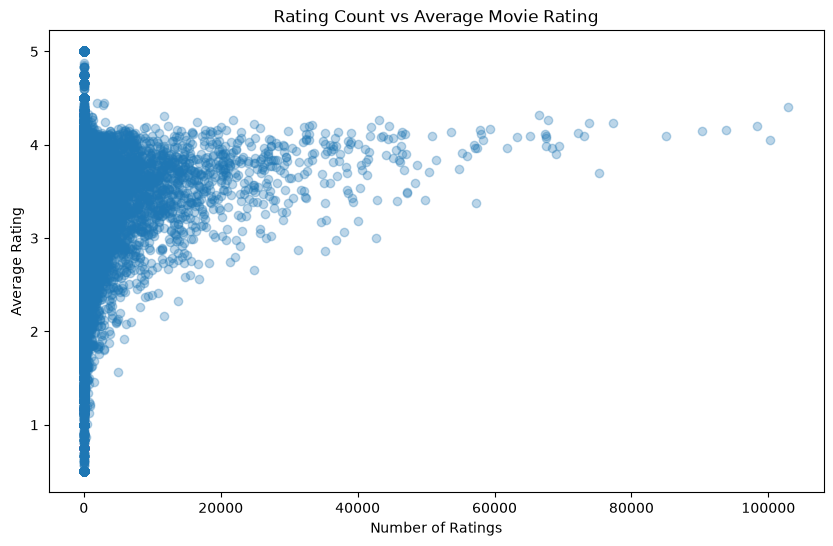

In [78]:
plt.figure(figsize=(10, 6))

plt.scatter(
    movie_rating_stats["rating_count"],
    movie_rating_stats["average_rating"],
    alpha=0.3
)

plt.title("Rating Count vs Average Movie Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")

plt.show()

### Observation

The relationship between movie popularity and average rating is not necessarily linear.

Movies with a small number of ratings may have unstable average ratings, whereas movies with many ratings provide stronger evidence of collective user preference.

Therefore, popularity and rating quality should be treated as separate features.

## 19.21 Top-Rated Movies with Minimum Rating Support

A movie with only a few ratings can have an artificially high average rating.

Therefore, top-rated movies are evaluated together with a minimum number of ratings to improve statistical reliability.

In [79]:
minimum_ratings = 100

supported_movies = movie_rating_stats[
    movie_rating_stats["rating_count"] >= minimum_ratings
].copy()

top_rated_movies = (
    supported_movies
    .sort_values(
        "average_rating",
        ascending=False
    )
    .head(20)
    .merge(
        movies[["movieId", "title"]],
        on="movieId",
        how="left"
    )
)

display(
    top_rated_movies[
        [
            "movieId",
            "title",
            "average_rating",
            "rating_count"
        ]
    ]
)

,movieId,title,average_rating,rating_count
0,171011,Planet Earth II (2016),4.446830,1956
1,159817,Planet Earth (2006),4.444369,2948
2,170705,Band of Brothers (2001),4.426539,2811
3,318,"Shawshank Redemption, The (1994)",4.404614,102929
4,171495,Cosmos,4.330081,615
5,858,"Godfather, The (1972)",4.317030,66440
6,202439,Parasite (2019),4.312254,11670
7,179135,Blue Planet II (2017),4.300086,1163
8,198185,Twin Peaks (1989),4.298684,1140
9,220528,Twelve Angry Men (1954),4.286192,449


### Observation

Applying a minimum rating-support threshold reduces the influence of movies with very few observations.

This produces a more reliable view of highly rated movies and demonstrates why recommendation systems should consider both rating quality and interaction volume.

## 19.22 Genre Frequency Analysis

Genre frequency is analyzed to understand how the movie catalog is distributed across different genres.

Because a movie can belong to multiple genres, the genre field is split before counting.

In [80]:
genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

display(genre_counts)

genres
Drama                 34175
Comedy                23124
Thriller              11823
Romance               10369
Action                 9668
Documentary            9363
Horror                 8654
(no genres listed)     7080
Crime                  6976
Adventure              5402
Sci-Fi                 4907
Animation              4617
Children               4520
Mystery                4013
Fantasy                3851
War                    2325
Western                1696
Musical                1059
Film-Noir               353
IMAX                    195
Name: count, dtype: int64

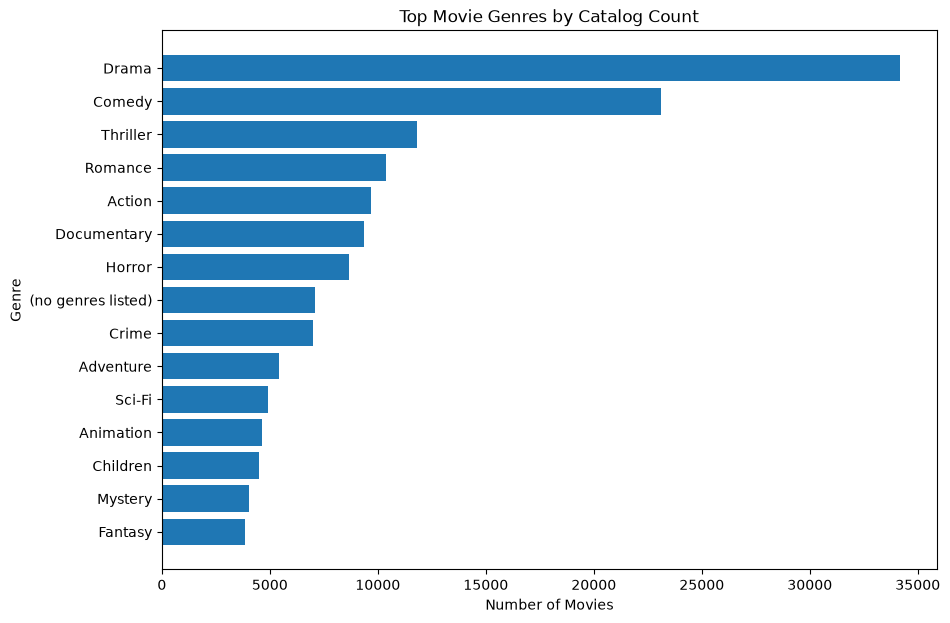

In [81]:
top_genres = genre_counts.head(15).sort_values()

plt.figure(figsize=(10, 7))

plt.barh(
    top_genres.index,
    top_genres.values
)

plt.title("Top Movie Genres by Catalog Count")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

### Observation

The movie catalog is not uniformly distributed across genres.

Some genres occur much more frequently than others.

This imbalance should be considered when constructing content-based features because highly represented genres may contribute more frequently to similarity calculations.

## 19.23 Genre-wise Rating Analysis

Average ratings are aggregated by genre to compare observed user preferences across different genre categories.

Because movies may have multiple genres, one movie can contribute to multiple genre-level statistics.

In [82]:
genre_movie_data = (
    movies[["movieId", "genres"]]
    .copy()
)

genre_movie_data["genre"] = (
    genre_movie_data["genres"]
    .str.split("|")
)

genre_movie_data = genre_movie_data.explode("genre")

genre_rating_stats = (
    genre_movie_data
    .merge(
        ratings[["movieId", "rating"]],
        on="movieId",
        how="inner"
    )
    .groupby("genre")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .sort_values(
        "rating_count",
        ascending=False
    )
)

display(genre_rating_stats)

,average_rating,rating_count
genre,,
Drama,3.682454,13973271
Comedy,3.432386,11206926
Action,3.476407,9665213
Thriller,3.531702,8679464
Adventure,3.523439,7590522
Sci-Fi,3.491699,5717337
Romance,3.545003,5524615
Crime,3.691771,5373051
Fantasy,3.512175,3702759


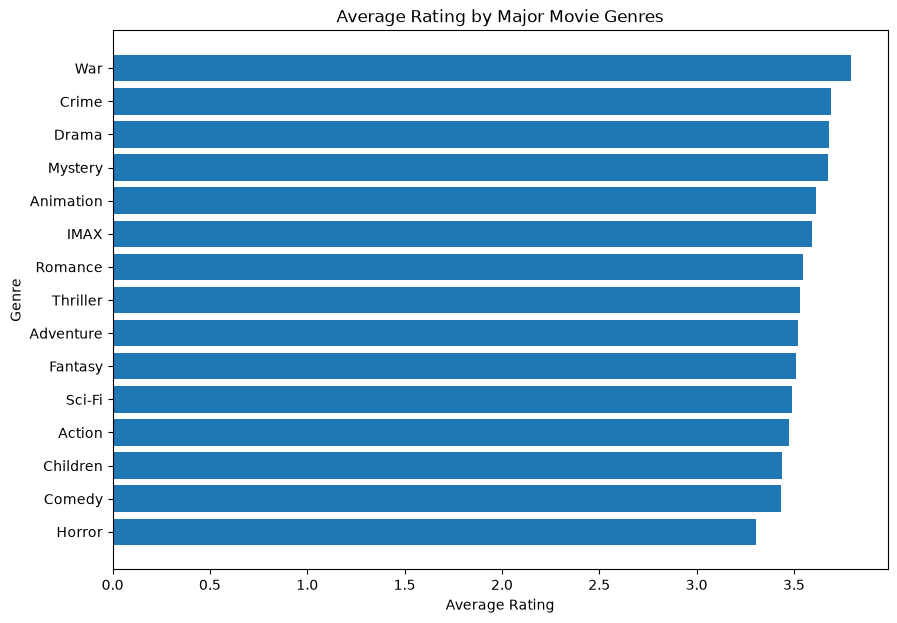

In [83]:
genre_plot = (
    genre_rating_stats
    .head(15)
    .sort_values("average_rating")
)

plt.figure(figsize=(10, 7))

plt.barh(
    genre_plot.index,
    genre_plot["average_rating"]
)

plt.title("Average Rating by Major Movie Genres")
plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.show()

### Observation

Different genres show different average rating patterns.

However, average genre rating should not be interpreted as a direct measure of individual user preference because the calculation aggregates ratings from many users and movies.

## 19.24 User Average Rating Distribution

The average rating given by each user is analyzed to understand differences in individual rating behavior.

Some users may generally give high ratings, while others may use the rating scale more conservatively.

In [84]:
user_rating_stats = (
    ratings
    .groupby("userId")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
)

display(user_rating_stats.head())

,average_rating,rating_count
userId,,
1,3.531915,141
2,4.269231,52
3,3.588435,147
4,2.629630,27
5,3.272727,33


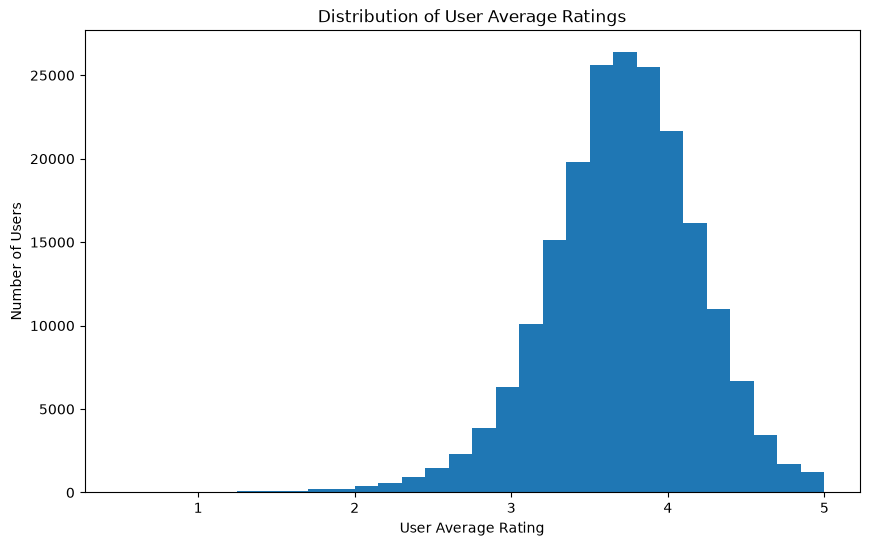

In [85]:
plt.figure(figsize=(10, 6))

plt.hist(
    user_rating_stats["average_rating"],
    bins=30
)

plt.title("Distribution of User Average Ratings")
plt.xlabel("User Average Rating")
plt.ylabel("Number of Users")

plt.show()

### Observation

Users exhibit different average-rating behaviors.

This indicates that raw ratings can contain individual user bias.

Such behavior is important for collaborative filtering and rating-prediction models because two users may use the same rating scale differently.

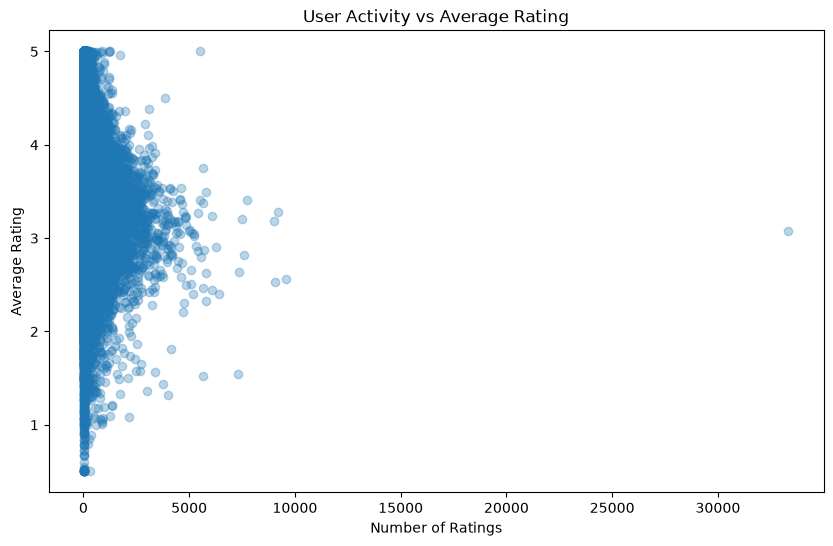

In [86]:
plt.figure(figsize=(10, 6))

plt.scatter(
    user_rating_stats["rating_count"],
    user_rating_stats["average_rating"],
    alpha=0.3
)

plt.title("User Activity vs Average Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")

plt.show()

### Observation

User activity and average rating represent different behavioral dimensions.

Highly active users provide more evidence about their preferences, while users with very few ratings provide weaker behavioral signals.

## 19.26 User-Movie Interaction Sparsity

The recommendation problem can be represented as a user-movie interaction matrix.

Most possible user-movie combinations do not have an observed rating, creating a sparse matrix.

In [87]:
num_users = ratings["userId"].nunique()
num_movies = ratings["movieId"].nunique()
num_ratings = len(ratings)

total_possible = num_users * num_movies

sparsity = (
    1 - (num_ratings / total_possible)
)

print("Number of users:", num_users)
print("Number of movies:", num_movies)
print("Observed ratings:", num_ratings)
print("Possible interactions:", total_possible)
print("Sparsity:", round(sparsity * 100, 4), "%")

Number of users: 200948
Number of movies: 84432
Observed ratings: 32000204
Possible interactions: 16966441536
Sparsity: 99.8114 %


### Observation

The user-movie interaction space is highly sparse.

This is one of the central challenges of collaborative filtering.

The sparsity motivates the use of latent-factor models and content-based information to improve recommendation quality.

## 19.27 Correlation Analysis of Movie-Level Features

Correlation analysis is used to examine relationships among numerical movie-level statistics.

The analysis is exploratory and does not imply causation.

In [88]:
movie_correlation_data = movie_rating_stats[
    [
        "average_rating",
        "rating_count"
    ]
]

correlation_matrix = (
    movie_correlation_data
    .corr()
)

display(correlation_matrix)

,average_rating,rating_count
average_rating,1.000000,0.097605
rating_count,0.097605,1.000000


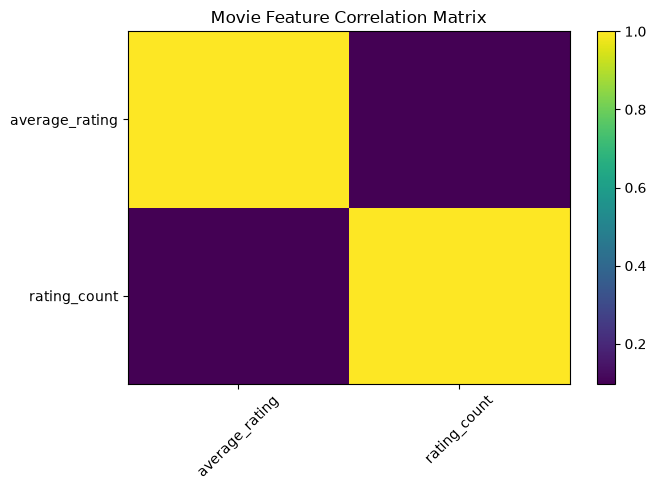

In [89]:
plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Movie Feature Correlation Matrix")

plt.colorbar()

plt.tight_layout()

plt.show()

### Observation

The correlation matrix provides an exploratory view of relationships between movie-level numerical features.

These relationships help determine which variables may provide useful signals for subsequent feature engineering and modeling.

## 19.28 EDA Findings and Machine-Learning Decisions

The exploratory analysis provides the following modeling insights:

| EDA Finding | Modeling Decision |
|---|---|
| Sparse user-movie interactions | Use collaborative filtering and matrix factorization |
| Popularity imbalance | Create popularity baseline and monitor popularity bias |
| Genre information available | Use content-based features |
| Titles and tags available | Apply text representation such as TF-IDF |
| Different user rating behavior | Consider user-level preference signals |
| Different movie popularity | Include interaction-count features |
| Temporal information available | Preserve timestamp-derived features |
| Multiple complementary signals | Develop a hybrid recommender |

## 19.29 Complete Movie EDA Flow

```text
                 CLEAN MOVIELENS
                        │
                        ↓
              ┌──────────────────┐
              │ Rating Analysis  │
              └────────┬─────────┘
                       ↓
              Distribution / Spread
                       │
                       ↓
              ┌──────────────────┐
              │ User Analysis    │
              └────────┬─────────┘
                       ↓
             Activity / Behavior
                       │
                       ↓
              ┌──────────────────┐
              │ Movie Analysis   │
              └────────┬─────────┘
                       ↓
            Popularity / Long Tail
                       │
                       ↓
              ┌──────────────────┐
              │ Genre Analysis   │
              └────────┬─────────┘
                       ↓
             Catalog Distribution
                       │
                       ↓
              ┌──────────────────┐
              │ Time Analysis    │
              └────────┬─────────┘
                       ↓
             Temporal Behaviour
                       │
                       ↓
              ┌──────────────────┐
              │ Sparsity Analysis│
              └────────┬─────────┘
                       ↓
             Collaborative Need
                       │
                       ↓
              MODELING STRATEGY


---

# 📝 19.30 — FINAL EDA OBSERVATION

### Markdown Cell

```markdown
## 19.30 Movie EDA — Final Observation

The MovieLens exploratory analysis reveals several characteristics that directly influence recommendation-system design.

The dataset contains substantial user-movie interaction information, but the interaction matrix is sparse and movie popularity is highly uneven.

User rating behavior also varies across users, while movie genres and textual metadata provide additional content signals.

These findings justify a multi-model recommendation architecture combining:

1. Statistical baselines
2. Regression-based rating prediction
3. Collaborative filtering
4. Matrix factorization
5. Content-based recommendation
6. Hybrid recommendation

The next phase will convert the observed movie metadata and interaction patterns into model-ready numerical and textual features.

# Phase 4 — Movie Feature Engineering

Feature engineering transforms the cleaned MovieLens data into representations that machine-learning and recommendation algorithms can use effectively.

The MovieLens dataset contains different types of information:

- Movie metadata
- Genres
- Titles
- User ratings
- User activity
- Movie popularity
- Tags
- Timestamps

These signals will be transformed into numerical, categorical, textual, and interaction-based features.

The objective is to create model-ready representations while avoiding unnecessary information leakage.

## 20.2 Feature Engineering Architecture

```text
                     MOVIELENS DATA
                           │
          ┌────────────────┼────────────────┐
          ↓                ↓                ↓
       MOVIES           RATINGS           TAGS
          │                │                │
          ↓                ↓                ↓
   Title + Genres     User Behaviour     Tag Text
          │                │                │
          ↓                ↓                ↓
      Text Features    Interaction      Text Features
          │             Features             │
          ↓                ↓                ↓
       TF-IDF       User/Movie Stats       TF-IDF
          │                │                │
          └────────────────┼────────────────┘
                           ↓
                  MODEL-READY FEATURES


---

# 20.3 — Create Movie Feature Table

### 📝 Markdown

```markdown
## 20.3 Movie-Level Feature Table

A movie-level feature table is created by combining movie metadata with rating statistics.

This table will provide the foundation for content-based and hybrid recommendation models.

In [90]:
movie_features = movies.copy()

movie_features = movie_features.merge(
    movie_rating_stats,
    on="movieId",
    how="left"
)

movie_features.head()

,movieId,title,genres,average_rating,rating_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.897438,68997.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.275758,28904.0
2,3,Grumpier Old Men (1995),Comedy|Romance,3.139447,13134.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.845331,2806.0
4,5,Father of the Bride Part II (1995),Comedy,3.059602,13154.0


In [91]:
print("Movie feature table shape:", movie_features.shape)

print("\nColumns:")
print(movie_features.columns.tolist())

display(movie_features.head())

Movie feature table shape: (87585, 5)

Columns:
['movieId', 'title', 'genres', 'average_rating', 'rating_count']


,movieId,title,genres,average_rating,rating_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.897438,68997.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.275758,28904.0
2,3,Grumpier Old Men (1995),Comedy|Romance,3.139447,13134.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.845331,2806.0
4,5,Father of the Bride Part II (1995),Comedy,3.059602,13154.0


### Observation

The movie feature table combines static movie metadata with aggregated interaction statistics.

This creates a unified representation that can later support both content-based and hybrid recommendation approaches.

## 20.5 Release Year Extraction

The release year is extracted from movie titles when available.

Release year can provide a useful numerical feature and can also support temporal analysis of the movie catalog.

In [92]:
movie_features["release_year"] = (
    movie_features["title"]
    .str.extract(r"\((\d{4})\)$")[0]
    .astype("float")
)

display(
    movie_features[
        ["movieId", "title", "release_year"]
    ].head(10)
)

,movieId,title,release_year
0,1,Toy Story (1995),1995.0
1,2,Jumanji (1995),1995.0
2,3,Grumpier Old Men (1995),1995.0
3,4,Waiting to Exhale (1995),1995.0
4,5,Father of the Bride Part II (1995),1995.0
5,6,Heat (1995),1995.0
6,7,Sabrina (1995),1995.0
7,8,Tom and Huck (1995),1995.0
8,9,Sudden Death (1995),1995.0
9,10,GoldenEye (1995),1995.0


In [93]:
print(
    "Missing release years:",
    movie_features["release_year"].isna().sum()
)

print(
    "Minimum release year:",
    movie_features["release_year"].min()
)

print(
    "Maximum release year:",
    movie_features["release_year"].max()
)

Missing release years: 771
Minimum release year: 1874.0
Maximum release year: 2023.0


### Observation

The release year provides a compact numerical representation of movie age.

Missing release years are retained rather than assigning arbitrary values.

In [94]:
movie_features["genre_count"] = (
    movie_features["genres"]
    .apply(
        lambda x: 0
        if x == "(no genres listed)"
        else len(x.split("|"))
    )
)

display(
    movie_features[
        ["title", "genres", "genre_count"]
    ].head(10)
)

,title,genres,genre_count
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5
1,Jumanji (1995),Adventure|Children|Fantasy,3
2,Grumpier Old Men (1995),Comedy|Romance,2
3,Waiting to Exhale (1995),Comedy|Drama|Romance,3
4,Father of the Bride Part II (1995),Comedy,1
5,Heat (1995),Action|Crime|Thriller,3
6,Sabrina (1995),Comedy|Romance,2
7,Tom and Huck (1995),Adventure|Children,2
8,Sudden Death (1995),Action,1
9,GoldenEye (1995),Action|Adventure|Thriller,3


### Observation

Genre count captures the number of genre categories associated with each movie.

It provides a simple numerical representation of genre complexity.

## 20.8 Movie Popularity Feature

The number of ratings received by a movie is used as an interaction-based popularity feature.

Popularity is useful as a baseline signal but should not dominate personalized recommendations.

In [95]:
movie_features["rating_count"] = (
    movie_features["rating_count"]
    .fillna(0)
)

display(
    movie_features[
        ["movieId", "title", "rating_count"]
    ].head()
)

,movieId,title,rating_count
0,1,Toy Story (1995),68997.0
1,2,Jumanji (1995),28904.0
2,3,Grumpier Old Men (1995),13134.0
3,4,Waiting to Exhale (1995),2806.0
4,5,Father of the Bride Part II (1995),13154.0


## 20.9 Log-Transformed Popularity

Movie rating counts typically follow a long-tail distribution.

A logarithmic transformation reduces the influence of extremely popular movies while preserving relative popularity information.

In [96]:
movie_features["log_rating_count"] = np.log1p(
    movie_features["rating_count"]
)

display(
    movie_features[
        [
            "title",
            "rating_count",
            "log_rating_count"
        ]
    ].head()
)

,title,rating_count,log_rating_count
0,Toy Story (1995),68997.0,11.141833
1,Jumanji (1995),28904.0,10.271770
2,Grumpier Old Men (1995),13134.0,9.483036
3,Waiting to Exhale (1995),2806.0,7.939872
4,Father of the Bride Part II (1995),13154.0,9.484557


### Observation

The logarithmic transformation compresses large popularity values.

This can make popularity-based numerical features more stable for statistical and machine-learning models.

In [97]:
movie_features["average_rating"] = (
    movie_features["average_rating"]
    .fillna(ratings["rating"].mean())
)

display(
    movie_features[
        ["title", "average_rating"]
    ].head()
)

,title,average_rating
0,Toy Story (1995),3.897438
1,Jumanji (1995),3.275758
2,Grumpier Old Men (1995),3.139447
3,Waiting to Exhale (1995),2.845331
4,Father of the Bride Part II (1995),3.059602


### Observation

Movies without observed ratings receive the global average as a temporary numerical fallback.

This fallback is used only for feature representation and does not imply that the movie actually received that rating.

## 20.11 Numerical Feature Scaling

Numerical features such as release year, average rating, and popularity operate on different scales.

Standardization is useful for algorithms that are sensitive to feature magnitude.

The scaler will be fitted only on training data when these features are used for supervised evaluation.

In [98]:
from sklearn.preprocessing import StandardScaler

numerical_features = [
    "release_year",
    "genre_count",
    "rating_count",
    "log_rating_count",
    "average_rating"
]

numerical_data = movie_features[
    numerical_features
].copy()

numerical_data = numerical_data.fillna(
    numerical_data.median()
)

scaler = StandardScaler()

numerical_scaled = scaler.fit_transform(
    numerical_data
)

numerical_scaled.shape

(87585, 5)

## 20.12 Multi-Hot Genre Encoding

Movies can belong to multiple genres simultaneously.

Therefore, genres are represented using multi-hot encoding rather than single-label categorical encoding.

For example:

Action | Comedy | Drama

A movie belonging to Action and Drama becomes:

1 | 0 | 1

In [99]:
genre_matrix = (
    movie_features["genres"]
    .str.get_dummies(sep="|")
)

genre_matrix.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [100]:
print("Genre feature matrix shape:")
print(genre_matrix.shape)

print("\nNumber of genre features:")
print(genre_matrix.shape[1])

Genre feature matrix shape:
(87585, 20)

Number of genre features:
20


### Observation

Multi-hot encoding converts each genre into an independent binary feature.

This representation is especially useful for content-based similarity because movies can share one or more genre characteristics.

## 20.14 Movie Content Representation

A combined textual representation is created using movie titles, genres, and user-generated tags.

This representation will later be converted into TF-IDF vectors for content-based recommendation.

Combining multiple content signals allows similarity to capture more than genre alone.

In [101]:
tags_clean = tags[["movieId", "tag"]].copy()

tags_clean["tag"] = (
    tags_clean["tag"]
    .fillna("")
    .astype(str)
    .str.strip()
)

movie_tags = (
    tags_clean
    .groupby("movieId", as_index=False)["tag"]
    .agg(" ".join)
)

movie_tags.head()

,movieId,tag
0,1,children Disney animation children Disney Disn...
1,2,Robin Williams fantasy Robin Williams time tra...
2,3,comedinha de velhinhos engraÃƒÂ§ada comedinha ...
3,4,characters slurs based on novel or book chick ...
4,5,Fantasy pregnancy remake family Steve Martin s...


## 20.16 Merge Tags with Movies

The aggregated user-generated tags are merged with the movie metadata using movieId.

A left join is used so that every movie in the main movie dataset is retained, including movies that do not have user-generated tags.


In [102]:
movie_features = movie_features.merge(
    movie_tags,
    on="movieId",
    how="left"
)

movie_features["tag"] = (
    movie_features["tag"]
    .fillna("")
)

display(
    movie_features[
        ["movieId", "title", "genres", "tag"]
    ].head(10)
)

,movieId,title,genres,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,children Disney animation children Disney Disn...
1,2,Jumanji (1995),Adventure|Children|Fantasy,Robin Williams fantasy Robin Williams time tra...
2,3,Grumpier Old Men (1995),Comedy|Romance,comedinha de velhinhos engraÃƒÂ§ada comedinha ...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,characters slurs based on novel or book chick ...
4,5,Father of the Bride Part II (1995),Comedy,Fantasy pregnancy remake family Steve Martin s...
5,6,Heat (1995),Action|Crime|Thriller,atmospheric dialogue Tumey's DVDs atmospheric ...
6,7,Sabrina (1995),Comedy|Romance,as good maybe better than original great cast ...
7,8,Tom and Huck (1995),Adventure|Children,Library System based on a book Mark Twain 19th...
8,9,Sudden Death (1995),Action,Action Jean-Claude Van Damme Can't remember ac...
9,10,GoldenEye (1995),Action|Adventure|Thriller,james bond Tumey's DVDs 007 Bond casual sex es...


### Observation

The movie metadata and aggregated user-generated tags have been successfully combined.

Movies without tags are retained because a left join was used, and their missing tag values are represented as empty strings.

## 20.17 Build Combined Movie Content Representation

Movie title, genres, and user-generated tags are combined into a single textual representation.

This allows the content-based recommender to use multiple sources of movie information rather than relying only on genres.

In [103]:
movie_features["content_text"] = (
    movie_features["title"].fillna("")
    + " "
    + movie_features["genres"]
        .fillna("")
        .str.replace("|", " ", regex=False)
    + " "
    + movie_features["tag"].fillna("")
)

display(
    movie_features[
        [
            "movieId",
            "title",
            "genres",
            "tag",
            "content_text"
        ]
    ].head(10)
)

,movieId,title,genres,tag,content_text
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,children Disney animation children Disney Disn...,Toy Story (1995) Adventure Animation Children ...
1,2,Jumanji (1995),Adventure|Children|Fantasy,Robin Williams fantasy Robin Williams time tra...,Jumanji (1995) Adventure Children Fantasy Robi...
2,3,Grumpier Old Men (1995),Comedy|Romance,comedinha de velhinhos engraÃƒÂ§ada comedinha ...,Grumpier Old Men (1995) Comedy Romance comedin...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,characters slurs based on novel or book chick ...,Waiting to Exhale (1995) Comedy Drama Romance ...
4,5,Father of the Bride Part II (1995),Comedy,Fantasy pregnancy remake family Steve Martin s...,Father of the Bride Part II (1995) Comedy Fant...
5,6,Heat (1995),Action|Crime|Thriller,atmospheric dialogue Tumey's DVDs atmospheric ...,Heat (1995) Action Crime Thriller atmospheric ...
6,7,Sabrina (1995),Comedy|Romance,as good maybe better than original great cast ...,Sabrina (1995) Comedy Romance as good maybe be...
7,8,Tom and Huck (1995),Adventure|Children,Library System based on a book Mark Twain 19th...,Tom and Huck (1995) Adventure Children Library...
8,9,Sudden Death (1995),Action,Action Jean-Claude Van Damme Can't remember ac...,Sudden Death (1995) Action Action Jean-Claude ...
9,10,GoldenEye (1995),Action|Adventure|Thriller,james bond Tumey's DVDs 007 Bond casual sex es...,GoldenEye (1995) Action Adventure Thriller jam...


### Observation

A unified textual representation has been created for each movie using title, genre, and tag information.

This representation will be converted into numerical TF-IDF vectors in the next stage.

## 20.18 Text Cleaning and Normalization

The combined movie content text is normalized before converting it into numerical TF-IDF features.

The text is converted to lowercase and extra whitespace is removed.

The original movie metadata remains unchanged, while the normalized representation is stored in `content_text`.

In [104]:
movie_features["content_text"] = (
    movie_features["content_text"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

display(
    movie_features[
        ["movieId", "title", "content_text"]
    ].head(10)
)

,movieId,title,content_text
0,1,Toy Story (1995),toy story (1995) adventure animation children ...
1,2,Jumanji (1995),jumanji (1995) adventure children fantasy robi...
2,3,Grumpier Old Men (1995),grumpier old men (1995) comedy romance comedin...
3,4,Waiting to Exhale (1995),waiting to exhale (1995) comedy drama romance ...
4,5,Father of the Bride Part II (1995),father of the bride part ii (1995) comedy fant...
5,6,Heat (1995),heat (1995) action crime thriller atmospheric ...
6,7,Sabrina (1995),sabrina (1995) comedy romance as good maybe be...
7,8,Tom and Huck (1995),tom and huck (1995) adventure children library...
8,9,Sudden Death (1995),sudden death (1995) action action jean-claude ...
9,10,GoldenEye (1995),goldeneye (1995) action adventure thriller jam...


In [105]:
print("Missing content text:", movie_features["content_text"].isna().sum())
print("Empty content text:", (movie_features["content_text"] == "").sum())

Missing content text: 0
Empty content text: 0


### Observation

The combined movie content has been normalized successfully.

Lowercase conversion and whitespace normalization provide a consistent textual representation for TF-IDF processing.

The original movie title, genres, and tags are preserved separately for future interpretation and explainability.

## 20.19 TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts the normalized movie content into numerical feature vectors.

Term Frequency measures how frequently a term appears within a movie representation.

Inverse Document Frequency reduces the importance of terms that occur across many movie descriptions.

The resulting vectors provide a numerical representation of movie content that can be used for similarity-based recommendation.

In [106]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=50000
)

tfidf_matrix = tfidf.fit_transform(
    movie_features["content_text"]
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (87585, 50000)


In [107]:
print("Number of movies:", tfidf_matrix.shape[0])
print("Number of TF-IDF features:", tfidf_matrix.shape[1])
print("Matrix type:", type(tfidf_matrix).__name__)

Number of movies: 87585
Number of TF-IDF features: 50000
Matrix type: csr_matrix


### Observation

The movie content has been transformed into a high-dimensional sparse TF-IDF matrix.

Each row represents one movie, while each column represents a learned textual feature.

The sparse representation is memory-efficient because most movie-feature combinations have zero values.

This TF-IDF matrix will serve as the textual feature representation for the content-based recommendation model.

## 20.20 TF-IDF Vocabulary Analysis

The TF-IDF vocabulary contains the textual terms learned from the movie content representation.

Inspecting the vocabulary helps verify that the text-processing pipeline has generated meaningful features from movie titles, genres, and tags.


In [108]:
feature_names = tfidf.get_feature_names_out()

print("Total TF-IDF features:", len(feature_names))

print("\nFirst 50 TF-IDF features:")
print(feature_names[:50])


Total TF-IDF features: 50000

First 50 TF-IDF features:
['000' '007' '007 007' '007 action' '007 bond' '007 daniel'
 '007 espionage' '007 james' '007 series' '01' '01 06' '01 10' '01 11'
 '01 12' '02' '02 06' '02 10' '02 11' '03' '03 06' '03 09' '03 10' '03 11'
 '04' '04 11' '05' '05 10' '05 11' '06' '06 10' '06 11' '06 bibliothek'
 '06 oscar' '07' '07 10' '08' '08 09' '08 10' '09' '09 09' '09 10' '09 11'
 '09 12' '10' '10 000' '10 01' '10 02' '10 03' '10 05' '10 06']


In [109]:
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary size:", len(feature_names))
print("Minimum document frequency:", tfidf.min_df)
print("Maximum features configured:", tfidf.max_features)

TF-IDF matrix shape: (87585, 50000)
Vocabulary size: 50000
Minimum document frequency: 2
Maximum features configured: 50000


### Observation

The TF-IDF vectorizer has generated a vocabulary from the combined movie content.

Each vocabulary term becomes a numerical feature in the TF-IDF representation.

Unigrams and bigrams are included to capture both individual terms and short combinations of terms.

The vocabulary size depends on the available movie content and the configured filtering parameters.

In [110]:
movie_index = 0

movie_vector = tfidf_matrix[movie_index]

print("Movie:")
print(movie_features.iloc[movie_index]["title"])

print("\nNon-zero TF-IDF features:")

non_zero_indices = movie_vector.nonzero()[1]

for index in non_zero_indices[:20]:
    print(
        feature_names[index],
        "->",
        round(movie_vector[0, index], 4)
    )

Movie:
Toy Story (1995)

Non-zero TF-IDF features:
toy -> 0.0911
story -> 0.0098
1995 -> 0.0032
adventure -> 0.0689
animation -> 0.2754
children -> 0.0705
comedy -> 0.0371
fantasy -> 0.023
disney -> 0.1922
pixar -> 0.611
funny -> 0.1391
tumey -> 0.0068
vhs -> 0.0035
classic -> 0.0718
friendship -> 0.1036
computer -> 0.1308
toys -> 0.1574
animated -> 0.0687
clever -> 0.1098
family -> 0.0861


### Observation

Only a subset of the complete vocabulary contributes non-zero values to an individual movie.

This demonstrates the sparse nature of TF-IDF representations.

Terms with stronger relevance to a movie receive comparatively higher TF-IDF weights.

## 20.22 TF-IDF Matrix Sparsity Analysis

The TF-IDF matrix is expected to be highly sparse because each movie contains only a small subset of the complete vocabulary.

The proportion of non-zero values is calculated to quantify this sparsity.

In [111]:
total_values = (
    tfidf_matrix.shape[0] *
    tfidf_matrix.shape[1]
)

non_zero_values = tfidf_matrix.nnz

sparsity = (
    1 -
    (non_zero_values / total_values)
)

print("Total matrix values:", total_values)
print("Non-zero values:", non_zero_values)
print("Sparsity:", round(sparsity * 100, 4), "%")

Total matrix values: 4379250000
Non-zero values: 2625001
Sparsity: 99.9401 %


### Observation

The TF-IDF matrix contains a very high proportion of zero values.

This confirms that the textual feature representation is sparse.

Sparse matrix storage is therefore appropriate because storing the complete dense matrix would require substantially more memory.

## 20.23 Cosine Similarity for Movie Content

Cosine similarity measures the similarity between two movie TF-IDF vectors.

A higher cosine similarity indicates that two movies have more similar textual content.

Cosine similarity is appropriate for TF-IDF vectors because it compares the orientation of vectors rather than their absolute magnitude.

In [112]:
from sklearn.metrics.pairwise import cosine_similarity

sample_similarity = cosine_similarity(
    tfidf_matrix[:5],
    tfidf_matrix
)

print(
    "Similarity matrix shape:",
    sample_similarity.shape
)

Similarity matrix shape: (5, 87585)


### Observation

Cosine similarity successfully compares movie content representations.

For each selected movie, similarity scores can be calculated against the complete movie catalog.

The highest similarity scores can later be used to retrieve content-based movie recommendations.

## 20.24 Content-Based Recommendation Flow

```text
Movie Title + Genres + Tags
             │
             ↓
       Text Cleaning
             │
             ↓
        TF-IDF Vector
             │
             ↓
     Movie Representation
             │
             ↓
      Cosine Similarity
             │
             ↓
   Similarity Scores
             │
             ↓
      Rank Movies
             │
             ↓
 Top-K Similar Movies


### 📝 Observation Cell

```markdown
### Observation

The content-based pipeline can recommend movies without requiring another user's ratings.

This makes the approach useful when sufficient interaction data is unavailable for a particular movie or user.

## 20.25 Content-Based Movie Recommendation Function

The TF-IDF representation and cosine similarity are now used to create a reusable movie recommendation function.

The function accepts a movie title and returns the most similar movies based on their content representation.

The recommendations are ranked according to cosine similarity.

In [113]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_similar_movies(movie_title, top_k=10):
    
    matches = movie_features[
        movie_features["title"].str.lower() == movie_title.lower()
    ]
    
    if matches.empty:
        return pd.DataFrame(
            columns=[
                "movieId",
                "title",
                "genres",
                "similarity_score"
            ]
        )
    
    movie_index = matches.index[0]
    
    similarity_scores = cosine_similarity(
        tfidf_matrix[movie_index],
        tfidf_matrix
    ).flatten()
    
    similar_indices = similarity_scores.argsort()[::-1]
    
    similar_indices = [
        i for i in similar_indices
        if i != movie_index
    ][:top_k]
    
    recommendations = movie_features.iloc[
        similar_indices
    ][
        ["movieId", "title", "genres"]
    ].copy()
    
    recommendations["similarity_score"] = (
        similarity_scores[similar_indices]
    )
    
    return recommendations.reset_index(drop=True)

 ## 20.26 Testing the Content-Based Recommender

The recommendation function is tested using an actual movie from the MovieLens dataset.

The output contains the recommended movie title, genre information, and content similarity score.

In [114]:
test_movie = movie_features["title"].iloc[0]

print("Input movie:")
print(test_movie)

print("\nRecommended movies:")

display(
    recommend_similar_movies(
        test_movie,
        top_k=10
    )
)

Input movie:
Toy Story (1995)

Recommended movies:


,movieId,title,genres,similarity_score
0,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.844682
1,2355,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.727049
2,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.624529
3,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.588955
4,6377,Finding Nemo (2003),Adventure|Animation|Children|Comedy,0.578689
5,157296,Finding Dory (2016),Adventure|Animation|Comedy,0.576940
6,8961,"Incredibles, The (2004)",Action|Adventure|Animation|Children|Comedy,0.567225
7,50872,Ratatouille (2007),Animation|Children|Drama,0.536141
8,45517,Cars (2006),Animation|Children|Comedy,0.529994
9,201588,Toy Story 4 (2019),Adventure|Animation|Children|Comedy,0.501340


 ### Observation

The content-based recommendation function successfully generates a ranked list of movies based on content similarity.

The similarity score indicates how closely each recommended movie matches the input movie's textual representation.

## 20.27 Manual Recommendation Test

A known movie title can be supplied to inspect whether the generated recommendations are semantically meaningful.

In [115]:
search_title = "Toy Story (1995)"

recommendations = recommend_similar_movies(
    search_title,
    top_k=10
)

display(recommendations)

,movieId,title,genres,similarity_score
0,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.844682
1,2355,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.727049
2,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.624529
3,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.588955
4,6377,Finding Nemo (2003),Adventure|Animation|Children|Comedy,0.578689
5,157296,Finding Dory (2016),Adventure|Animation|Comedy,0.576940
6,8961,"Incredibles, The (2004)",Action|Adventure|Animation|Children|Comedy,0.567225
7,50872,Ratatouille (2007),Animation|Children|Drama,0.536141
8,45517,Cars (2006),Animation|Children|Comedy,0.529994
9,201588,Toy Story 4 (2019),Adventure|Animation|Children|Comedy,0.501340


In [116]:
if not recommendations.empty:
    print(
        "Minimum similarity:",
        recommendations["similarity_score"].min()
    )

    print(
        "Maximum similarity:",
        recommendations["similarity_score"].max()
    )

    print(
        "Average similarity:",
        recommendations["similarity_score"].mean()
    )
else:
    print("No recommendations found.")

Minimum similarity: 0.5013403364684905
Maximum similarity: 0.8446815294822938
Average similarity: 0.6075543796217411


### Observation

The recommendation scores provide a quantitative measure of content similarity.

Higher scores indicate stronger similarity between the input movie and the recommended movie.

The scores are used for ranking and should not be interpreted as predicted user ratings.

## 20.29 Recommendation Result Validation

The recommendation output is checked for duplicate movie IDs and duplicate titles.

Each recommended movie should appear only once in the final ranked list.

In [117]:
if not recommendations.empty:
    print(
        "Duplicate movie IDs:",
        recommendations["movieId"].duplicated().sum()
    )

    print(
        "Duplicate titles:",
        recommendations["title"].duplicated().sum()
    )

Duplicate movie IDs: 0
Duplicate titles: 0


 ## 20.30 Final Content-Based Recommendation Flow

```text
                 INPUT MOVIE
                     │
                     ↓
              Find Movie Index
                     │
                     ↓
              TF-IDF Vector
                     │
                     ↓
       Compare Against Movie Catalog
                     │
                     ↓
          Cosine Similarity Scores
                     │
                     ↓
              Sort Descending
                     │
                     ↓
              Remove Input Movie
                     │
                     ↓
                 Top-K
                     │
                     ↓
       CONTENT-BASED RECOMMENDATIONS


---

# 20.31 — Content-Based Strengths & Limitations

### 📝 Markdown Cell

```markdown
## 20.31 Content-Based Model — Strengths and Limitations

### Strengths

- Does not require other users' ratings for similarity calculation.
- Can recommend less popular movies when their content is similar.
- Provides interpretable similarity based on movie attributes.
- Can support new-item recommendations when metadata is available.

### Limitations

- Recommendations depend heavily on available metadata.
- Similar content can lead to less diverse recommendations.
- It does not directly learn collaborative user preferences.
- Strong personalization requires a reliable representation of the user's interests.

These limitations motivate the development of a collaborative-filtering model and eventually a hybrid recommendation system.

## 20.32 Movie Feature Engineering — Final Observation

The MovieLens data has been transformed into model-ready representations.

The feature-engineering pipeline now contains:

1. Movie metadata
2. Release year
3. Genre count
4. Average rating
5. Rating count
6. Log-transformed popularity
7. Multi-hot genre features
8. Combined title, genre, and tag text
9. TF-IDF representation
10. Cosine-similarity-based content representation

The content-based recommendation function has also been implemented and tested.

The next phase will establish statistical and popularity-based baseline models before moving to regression and collaborative-filtering approaches.

# Phase 5 — Statistical and Baseline Models

Before developing advanced recommendation algorithms, simple baseline models are established.

Baselines provide a reference point against which machine-learning and recommendation models can be evaluated.

The following baselines will be investigated:

1. Global Mean Rating
2. Movie Mean Rating
3. User Mean Rating
4. Popularity-Based Recommendation

These models are intentionally simple, but they provide important benchmarks for evaluating whether more complex models actually improve recommendation quality.

## 21.2 Baseline Modeling Workflow

```text
                 CLEAN RATINGS
                       │
                       ↓
               Train / Test Split
                       │
          ┌────────────┼────────────┐
          ↓            ↓            ↓
     Global Mean   Movie Mean   User Mean
          │            │            │
          └────────────┼────────────┘
                       ↓
                Rating Prediction
                       │
                       ↓
                  MAE / RMSE
                       │
                       ↓
              Baseline Comparison
                       │
                       ↓
            Popularity Recommendation


---

# 21.3 — Create Evaluation Split

🔥 **Important:** ippudu nunchi evaluation-safe approach maintain chestham.

### 📝 Markdown Cell

```markdown
## 21.3 Train-Test Split for Baseline Evaluation

The rating interactions are divided into training and testing subsets.

The training set is used to calculate baseline statistics, while the test set is reserved for evaluating predictions.

A fixed random state is used to make the experiment reproducible.

In [118]:
from sklearn.model_selection import train_test_split

ratings_model = ratings[
    ["userId", "movieId", "rating"]
].copy()

train_ratings, test_ratings = train_test_split(
    ratings_model,
    test_size=0.2,
    random_state=42
)

print("Training ratings:", train_ratings.shape)
print("Testing ratings:", test_ratings.shape)

Training ratings: (25600163, 3)
Testing ratings: (6400041, 3)


### Observation

The rating interactions have been separated into training and testing sets.

The training set contains 80% of the interactions, while the testing set contains 20%.

The test set will remain unseen while calculating baseline statistics to avoid evaluation leakage.

In [119]:
print("Training users:", train_ratings["userId"].nunique())
print("Testing users:", test_ratings["userId"].nunique())

print("Training movies:", train_ratings["movieId"].nunique())
print("Testing movies:", test_ratings["movieId"].nunique())

Training users: 200948
Testing users: 200749


Training movies: 80318
Testing movies: 54098


### Observation

The train-test split preserves a large portion of the user and movie population.

Some users or movies may appear only in the test set, which is relevant when discussing cold-start and unseen-entity behavior later.

## 21.5 Global Mean Rating Baseline

The global mean baseline predicts the same rating for every user-movie pair.

The predicted value is the average rating observed in the training dataset.

Although this model does not personalize recommendations, it provides the simplest reference point for rating prediction.

In [120]:
global_mean = train_ratings["rating"].mean()

print("Global mean rating:", round(global_mean, 4))

Global mean rating: 3.5403


In [121]:
global_predictions = np.full(
    len(test_ratings),
    global_mean
)

print("Number of predictions:", len(global_predictions))

Number of predictions: 6400041


In [122]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

global_mae = mean_absolute_error(
    test_ratings["rating"],
    global_predictions
)

global_rmse = np.sqrt(
    mean_squared_error(
        test_ratings["rating"],
        global_predictions
    )
)

print("Global Mean MAE:", round(global_mae, 4))
print("Global Mean RMSE:", round(global_rmse, 4))

Global Mean MAE: 0.8377
Global Mean RMSE: 1.0587


### Observation

The global mean provides a simple but non-personalized prediction.

Its performance establishes the minimum benchmark that subsequent rating-prediction models should improve upon.

## 21.8 Movie Mean Rating Baseline

The movie mean baseline predicts a movie's average training-set rating for every user who has not provided a rating for that movie.

This model captures differences in movie-level popularity and perceived quality.

In [123]:
movie_mean = (
    train_ratings
    .groupby("movieId")["rating"]
    .mean()
)

display(
    movie_mean.head()
)

movieId
1    3.894778
2    3.272305
3    3.135147
4    2.843792
5    3.064695
Name: rating, dtype: float64

In [124]:
movie_predictions = test_ratings["movieId"].map(
    movie_mean
)

movie_predictions = movie_predictions.fillna(
    global_mean
)

print("Missing predictions:", movie_predictions.isna().sum())

Missing predictions: 0


### Observation

Movies with sufficient training interactions receive their own mean rating.

If a test movie is not present in the training data, the global mean is used as a fallback.

This creates a simple cold-start fallback mechanism for unseen movies.

In [125]:
movie_mae = mean_absolute_error(
    test_ratings["rating"],
    movie_predictions
)

movie_rmse = np.sqrt(
    mean_squared_error(
        test_ratings["rating"],
        movie_predictions
    )
)

print("Movie Mean MAE:", round(movie_mae, 4))
print("Movie Mean RMSE:", round(movie_rmse, 4))

Movie Mean MAE: 0.7402
Movie Mean RMSE: 0.9595


## 21.11 User Mean Rating Baseline

The user mean baseline predicts a user's average historical training rating for the movies in the test set.

This model captures individual rating tendencies but does not consider movie-specific characteristics.

In [126]:
user_mean = (
    train_ratings
    .groupby("userId")["rating"]
    .mean()
)

display(
    user_mean.head()
)

userId
1    3.478632
2    4.128205
3    3.525641
4    2.590909
5    3.178571
Name: rating, dtype: float64

In [127]:
user_predictions = test_ratings["userId"].map(
    user_mean
)

user_predictions = user_predictions.fillna(
    global_mean
)

print(
    "Missing predictions:",
    user_predictions.isna().sum()
)

Missing predictions: 0


### Observation

Users with historical training ratings receive personalized mean predictions.

For users not observed in the training data, the global mean provides a fallback.

This demonstrates the basic difference between a global baseline and a personalized baseline.

In [128]:
user_mae = mean_absolute_error(
    test_ratings["rating"],
    user_predictions
)

user_rmse = np.sqrt(
    mean_squared_error(
        test_ratings["rating"],
        user_predictions
    )
)

print("User Mean MAE:", round(user_mae, 4))
print("User Mean RMSE:", round(user_rmse, 4))

User Mean MAE: 0.7292
User Mean RMSE: 0.946


## 21.14 Baseline Model Comparison

The baseline models are compared using MAE and RMSE.

Lower values indicate better rating-prediction performance.

In [129]:
baseline_results = pd.DataFrame({
    "Model": [
        "Global Mean",
        "Movie Mean",
        "User Mean"
    ],
    "MAE": [
        global_mae,
        movie_mae,
        user_mae
    ],
    "RMSE": [
        global_rmse,
        movie_rmse,
        user_rmse
    ]
})

baseline_results

,Model,MAE,RMSE
0,Global Mean,0.837699,1.058698
1,Movie Mean,0.740197,0.959541
2,User Mean,0.729202,0.945987


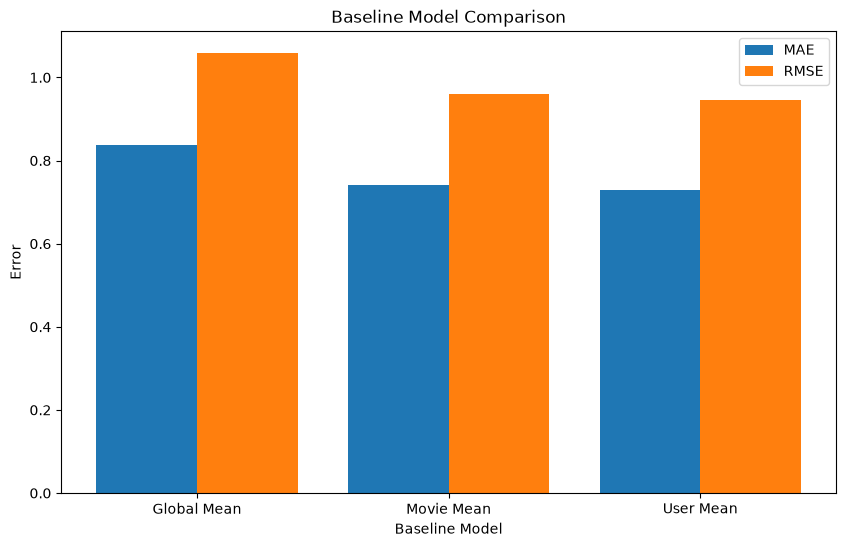

In [130]:
plt.figure(figsize=(10, 6))

x = np.arange(len(baseline_results))

plt.bar(
    x - 0.2,
    baseline_results["MAE"],
    width=0.4,
    label="MAE"
)

plt.bar(
    x + 0.2,
    baseline_results["RMSE"],
    width=0.4,
    label="RMSE"
)

plt.xticks(
    x,
    baseline_results["Model"]
)

plt.ylabel("Error")
plt.xlabel("Baseline Model")
plt.title("Baseline Model Comparison")
plt.legend()

plt.show()

### Observation

The baseline comparison shows how much predictive information is captured by global, movie-level, and user-level statistics.

The strongest baseline will become the reference point for the upcoming machine-learning models.

A complex model should demonstrate measurable improvement over these simple benchmarks.

## 21.16 Popularity-Based Recommendation Baseline

A popularity-based recommender ranks movies according to the number of ratings received in the training data.

This model does not personalize recommendations.

It serves as an important benchmark because popular items are often strong candidates in real-world recommendation systems.

In [131]:
movie_popularity_train = (
    train_ratings
    .groupby("movieId")
    .agg(
        rating_count=("rating", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

movie_popularity_train = (
    movie_popularity_train
    .merge(
        movies[["movieId", "title", "genres"]],
        on="movieId",
        how="left"
    )
)

movie_popularity_train = (
    movie_popularity_train
    .sort_values(
        ["rating_count", "average_rating"],
        ascending=[False, False]
    )
)

display(
    movie_popularity_train.head(20)
)

,movieId,rating_count,average_rating,title,genres
314,318,82183,4.403812,"Shawshank Redemption, The (1994)",Crime|Drama
351,356,80297,4.050880,Forrest Gump (1994),Comedy|Drama|Romance|War
292,296,78457,4.197458,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2480,2571,75088,4.155970,"Matrix, The (1999)",Action|Sci-Fi|Thriller
585,593,72227,4.147168,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
257,260,68025,4.097508,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
2867,2959,61729,4.225729,Fight Club (1999),Action|Crime|Drama|Thriller
475,480,60107,3.697955,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
522,527,59158,4.236190,Schindler's List (1993),Drama|War
4887,4993,58358,4.093929,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy


In [132]:
def popular_movies(top_k=10):
    
    return (
        movie_popularity_train[
            [
                "movieId",
                "title",
                "genres",
                "rating_count",
                "average_rating"
            ]
        ]
        .head(top_k)
        .reset_index(drop=True)
    )

In [133]:
popular_movies(10)

,movieId,title,genres,rating_count,average_rating
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,82183,4.403812
1,356,Forrest Gump (1994),Comedy|Drama|Romance|War,80297,4.050880
2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,78457,4.197458
3,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,75088,4.155970
4,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,72227,4.147168
5,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,68025,4.097508
6,2959,Fight Club (1999),Action|Crime|Drama|Thriller,61729,4.225729
7,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,60107,3.697955
8,527,Schindler's List (1993),Drama|War,59158,4.236190
9,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,58358,4.093929


## 21.18 Popularity-Based Recommendation Flow

```text
                 TRAIN RATINGS
                       │
                       ↓
               Group by Movie
                       │
                       ↓
             Count Interactions
                       │
                       ↓
              Calculate Average
                       │
                       ↓
              Rank Movies
                       │
                       ↓
                  Top-K
                       │
                       ↓
        POPULARITY RECOMMENDATIONS


### 📝 Observation

```markdown
### Observation

The popularity-based model provides a simple recommendation strategy without requiring user-specific preference information.

Its main limitation is personalization: the same popular movies are recommended to every user.

This limitation motivates collaborative filtering and hybrid recommendation models.

## 21.19 Baseline Modeling — Final Observation

Three rating-prediction baselines and one recommendation baseline have been established.

### Rating Prediction Baselines

- Global Mean
- Movie Mean
- User Mean

### Recommendation Baseline

- Popularity-Based Recommendation

These baselines establish reference performance for subsequent machine-learning models.

The upcoming Linear Regression model must be evaluated against these baselines to determine whether additional features provide predictive value.

## 21.20 Viva Explanation

### Why do we need baseline models?

Baseline models provide a simple reference point.

If a complex machine-learning model cannot outperform a simple baseline, the additional model complexity may not be justified.

### Why Global Mean?

It represents the overall average rating and provides the simplest prediction.

### Why Movie Mean?

Different movies receive different average ratings, so this model captures movie-level preference differences.

### Why User Mean?

Different users use rating scales differently, so user-level averages capture basic personalization.

### Why Popularity Baseline?

It provides a simple recommendation strategy and helps us measure whether advanced personalized models improve beyond popularity alone.

# Phase 6 — Linear Regression

Linear Regression is introduced as a supervised-learning baseline for predicting a user's movie rating.

The model learns a relationship between numerical user/movie features and the observed rating.

Target variable:

    rating

The objective is to determine whether simple linear relationships between engineered features and ratings can provide useful predictive performance.

Linear Regression is used as a rating-prediction model, not as the final recommendation algorithm.

## 22.2 Linear Regression Workflow

```text
                RATING INTERACTIONS
                        │
                        ↓
                  Feature Join
                        │
                        ↓
              Numerical Features
                        │
                        ↓
                 Train / Test
                        │
                        ↓
              Linear Regression
                        │
                        ↓
              Predicted Ratings
                        │
          ┌─────────────┼─────────────┐
          ↓             ↓             ↓
         MAE          RMSE            R²
          │             │             │
          └─────────────┼─────────────┘
                        ↓
                  Error Analysis
                        ↓
                 Model Comparison


---

# 22.3 — Define Regression Dataset

### 📝 Markdown Cell

```markdown
## 22.3 Creating the Regression Dataset

For rating prediction, each observation represents a user-movie interaction.

Movie-level features are joined with the corresponding rating interactions.

The target variable is the observed user rating.

Only features available without using the target rating itself are used as predictors.

In [134]:
regression_data = train_ratings.merge(
    movie_features[
        [
            "movieId",
            "release_year",
            "genre_count",
            "rating_count",
            "log_rating_count"
        ]
    ],
    on="movieId",
    how="left"
)

print("Regression dataset shape:", regression_data.shape)

display(regression_data.head())

Regression dataset shape: (25600163, 7)


,userId,movieId,rating,release_year,genre_count,rating_count,log_rating_count
0,161935,2324,5.0,1997.0,4,29819.0,10.302935
1,23152,134130,5.0,2015.0,3,28104.0,10.243703
2,152931,4357,4.5,1953.0,3,964.0,6.872128
3,177271,111622,4.5,2013.0,2,1981.0,7.591862
4,167551,5378,3.5,2002.0,4,27415.0,10.218882


## 22.4 User-Level Feature Engineering

User-level statistics are calculated using only the training interactions.

These features represent each user's historical rating behavior without using the target test rating.

This prevents direct target leakage.

In [135]:
user_features = (
    train_ratings
    .groupby("userId")
    .agg(
        user_avg_rating=("rating", "mean"),
        user_rating_count=("rating", "count")
    )
    .reset_index()
)

display(user_features.head())

,userId,user_avg_rating,user_rating_count
0,1,3.478632,117
1,2,4.128205,39
2,3,3.525641,117
3,4,2.590909,22
4,5,3.178571,28


In [136]:
regression_data = regression_data.merge(
    user_features,
    on="userId",
    how="left"
)

display(
    regression_data.head()
)

,userId,movieId,rating,release_year,genre_count,rating_count,log_rating_count,user_avg_rating,user_rating_count
0,161935,2324,5.0,1997.0,4,29819.0,10.302935,4.088889,45
1,23152,134130,5.0,2015.0,3,28104.0,10.243703,4.092000,125
2,152931,4357,4.5,1953.0,3,964.0,6.872128,4.312199,1246
3,177271,111622,4.5,2013.0,2,1981.0,7.591862,4.660000,100
4,167551,5378,3.5,2002.0,4,27415.0,10.218882,3.524648,142


### Observation

The regression dataset now contains both movie-level and user-level behavioral features.

These features provide the model with information about movie popularity and individual user rating tendencies.

## 22.6 Feature Matrix and Target Variable

The regression target is the observed rating.

Predictor variables include:

- Release year
- Genre count
- Movie rating count
- Log-transformed movie popularity
- User average rating
- User rating count

The observed rating itself is excluded from the feature matrix.

In [137]:
feature_columns = [
    "release_year",
    "genre_count",
    "rating_count",
    "log_rating_count",
    "user_avg_rating",
    "user_rating_count"
]

X_train = regression_data[
    feature_columns
].copy()

y_train = regression_data["rating"].copy()

print("Feature matrix:", X_train.shape)
print("Target:", y_train.shape)

Feature matrix: (25600163, 6)
Target: (25600163,)


In [138]:
X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_train = X_train.fillna(
    X_train.median()
)

print("Remaining missing values:")
display(X_train.isna().sum())

Remaining missing values:


release_year         0
genre_count          0
rating_count         0
log_rating_count     0
user_avg_rating      0
user_rating_count    0
dtype: int64

### Observation

Missing numerical feature values have been replaced using training-set medians.

The target variable is kept separate from feature preprocessing to prevent leakage.

## 22.8 Preparing the Test Feature Matrix

The same feature definitions are applied to the held-out test interactions.

Training-derived statistics are reused when creating test features.

The test ratings remain unseen until final evaluation.

In [139]:
test_regression = test_ratings.merge(
    movie_features[
        [
            "movieId",
            "release_year",
            "genre_count",
            "rating_count",
            "log_rating_count"
        ]
    ],
    on="movieId",
    how="left"
)

test_regression = test_regression.merge(
    user_features,
    on="userId",
    how="left"
)

X_test = test_regression[
    feature_columns
].copy()

y_test = test_regression["rating"].copy()

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan
)

X_test = X_test.fillna(
    X_train.median()
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (25600163, 6)
X_test: (6400041, 6)


## 22.9 Feature Scaling

The numerical features have different scales.

StandardScaler transforms the training features to a comparable scale.

The scaler is fitted only on the training data and then applied to the test data.

This prevents information from the test set from influencing the transformation.

In [140]:
from sklearn.preprocessing import StandardScaler

regression_scaler = StandardScaler()

X_train_scaled = regression_scaler.fit_transform(
    X_train
)

X_test_scaled = regression_scaler.transform(
    X_test
)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (25600163, 6)
Scaled testing shape: (6400041, 6)


## 22.10 Training the Linear Regression Model

Linear Regression models the target rating as a weighted combination of the input features.

Conceptually:

    predicted_rating =
    intercept
    + coefficient₁ × feature₁
    + coefficient₂ × feature₂
    + ...

The coefficients indicate the direction and magnitude of the learned linear relationship.

In [141]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [142]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Observation

The coefficients describe the learned linear relationship between each standardized feature and predicted rating.

A positive coefficient indicates that higher values of the corresponding feature are associated with higher predicted ratings within this model.

A negative coefficient indicates the opposite relationship.

Because the features are standardized, coefficient magnitudes can be compared more meaningfully than when raw feature scales differ.

In [143]:
linear_predictions = linear_model.predict(
    X_test_scaled
)

print("Number of predictions:", len(linear_predictions))

print("\nFirst 10 predictions:")
print(linear_predictions[:10])

Number of predictions: 6400041

First 10 predictions:
[3.51429472 3.22784093 3.15125566 3.54573088 3.03441471 3.71792441
 2.68353758 4.08611    3.37267125 4.52886161]


In [144]:
print("Minimum predicted rating:",
      linear_predictions.min())

print("Maximum predicted rating:",
      linear_predictions.max())

print("Actual minimum rating:",
      y_test.min())

print("Actual maximum rating:",
      y_test.max())

Minimum predicted rating: 0.14775692082188696
Maximum predicted rating: 5.615487032772348
Actual minimum rating: 0.5
Actual maximum rating: 5.0


### Observation

Linear Regression is an unconstrained regression model and therefore may produce predictions outside the valid MovieLens rating range.

The raw predictions are retained for evaluation because clipping predictions would modify the model output.

This behavior is one limitation of using ordinary Linear Regression for bounded rating prediction.

In [145]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = linear_model.score(
    X_test_scaled,
    y_test
)

print("Linear Regression MAE:",
      round(linear_mae, 4))

print("Linear Regression RMSE:",
      round(linear_rmse, 4))

print("Linear Regression R²:",
      round(linear_r2, 4))

Linear Regression MAE: 0.7155
Linear Regression RMSE: 0.9287
Linear Regression R²: 0.2304


## 22.15 Actual vs Predicted Ratings

Actual ratings are compared with model predictions.

A strong regression model should produce predictions that follow the overall pattern of the observed ratings.

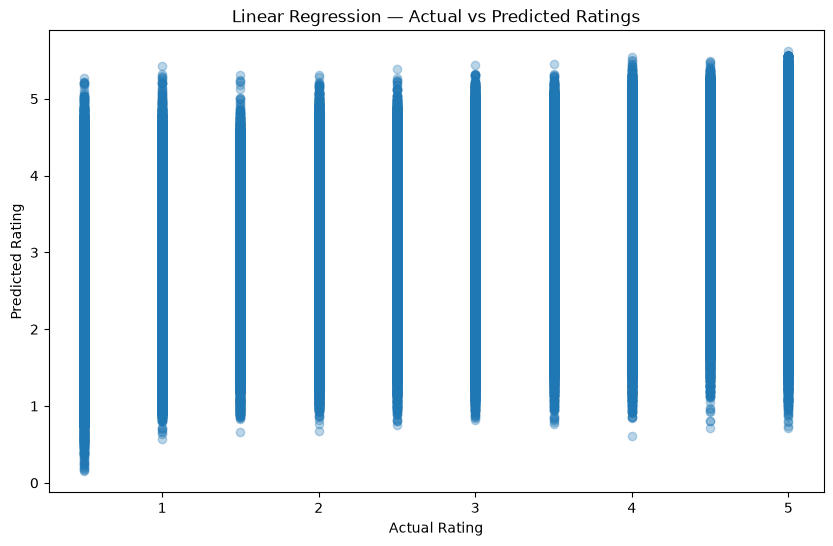

In [146]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.3
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Linear Regression — Actual vs Predicted Ratings")

plt.show()

### Observation

The scatter plot shows how closely predicted ratings follow actual user ratings.

A strong concentration around an increasing diagonal pattern would indicate stronger predictive agreement.

Deviation from the expected pattern represents prediction error.

## 22.16 Residual Analysis

A residual is the difference between an observed rating and the model's predicted rating.

    Residual = Actual Rating − Predicted Rating

Residual analysis helps identify systematic prediction errors.

In [147]:
residuals = (
    y_test.values -
    linear_predictions
)

print("Mean residual:",
      residuals.mean())

print("Residual standard deviation:",
      residuals.std())

Mean residual: 0.0003869892591694356
Residual standard deviation: 0.9287345221841941


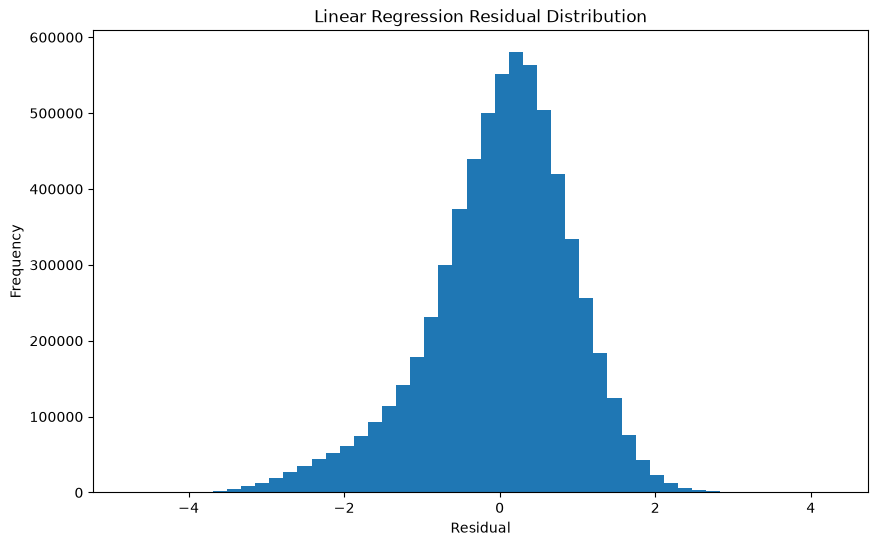

In [148]:
plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=50
)

plt.title("Linear Regression Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

### Observation

The residual distribution shows the magnitude and direction of prediction errors.

A distribution centered around zero indicates that the model does not have a large overall systematic bias, although individual prediction errors may still be substantial.

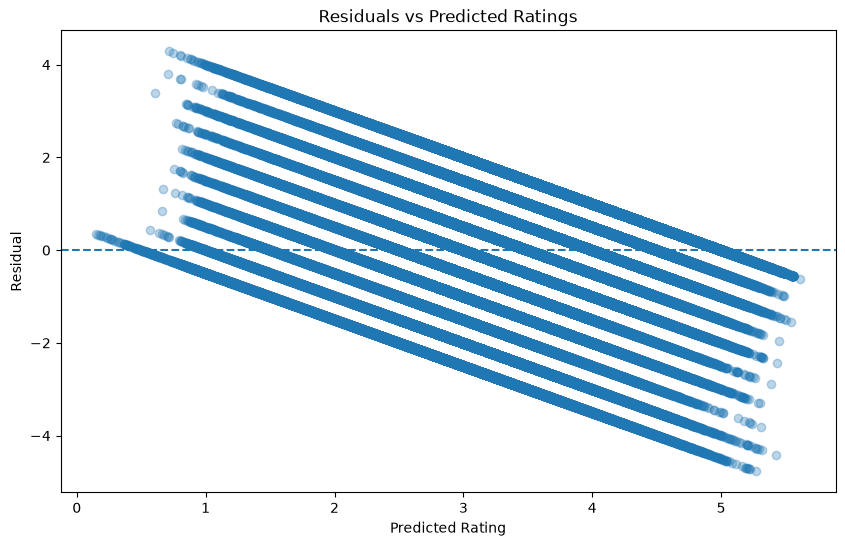

In [149]:
plt.figure(figsize=(10, 6))

plt.scatter(
    linear_predictions,
    residuals,
    alpha=0.3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Residuals vs Predicted Ratings")
plt.xlabel("Predicted Rating")
plt.ylabel("Residual")

plt.show()

### Observation

Residual patterns are examined to identify potential non-linear relationships or changing error variance.

A strong systematic pattern would indicate that the linear model is unable to fully represent the underlying rating behavior.

In [150]:
linear_result = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [linear_mae],
    "RMSE": [linear_rmse],
    "R2": [linear_r2]
})

baseline_comparison = baseline_results.copy()

baseline_comparison["R2"] = np.nan

model_comparison = pd.concat(
    [
        baseline_comparison,
        linear_result
    ],
    ignore_index=True
)

display(model_comparison)

,Model,MAE,RMSE,R2
0,Global Mean,0.837699,1.058698,NaN
1,Movie Mean,0.740197,0.959541,NaN
2,User Mean,0.729202,0.945987,NaN
3,Linear Regression,0.715523,0.928735,0.230446


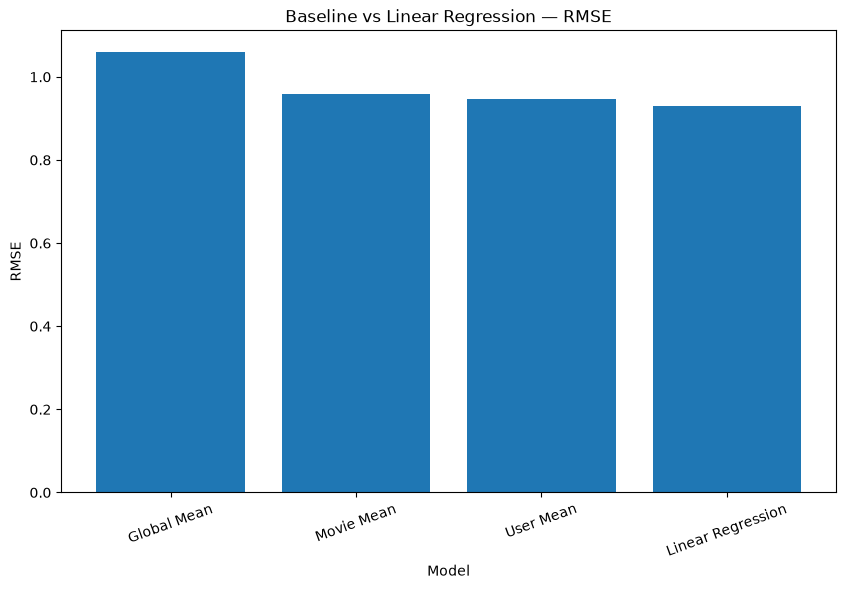

In [151]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

plt.title("Baseline vs Linear Regression — RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

### Observation

Linear Regression is compared against simple statistical baselines.

The comparison determines whether engineered user-level and movie-level features provide additional predictive value beyond simple mean-based predictions.

The model should only be considered an improvement if its evaluation metrics demonstrate better performance on unseen test interactions.

## 22.21 Linear Regression — Complete Flow

```text
             TRAINING RATINGS
                    │
                    ↓
          Movie + User Features
                    │
                    ↓
              Feature Matrix
                    │
                    ↓
              Missing Handling
                    │
                    ↓
              Standard Scaling
                    │
                    ↓
           Linear Regression
                    │
                    ↓
              Rating Prediction
                    │
          ┌─────────┼─────────┐
          ↓         ↓         ↓
         MAE      RMSE       R²
          │         │         │
          └─────────┼─────────┘
                    ↓
             Residual Analysis
                    ↓
             Baseline Comparison


---

# 22.22 — Viva Concepts 🎓

### 📝 Markdown Cell

```markdown
## 22.22 Linear Regression — Viva Preparation

### What is Linear Regression?

Linear Regression predicts a continuous target using a weighted linear combination of input features.

### What is our target?

The target is the user's observed movie rating.

### Why are we using Linear Regression?

It provides an interpretable supervised-learning baseline for rating prediction.

### Why do we scale features?

Our features have different numerical ranges. Standardization places them on comparable scales.

### What is MAE?

Mean Absolute Error measures the average absolute difference between actual and predicted ratings.

### What is RMSE?

Root Mean Squared Error gives greater penalty to larger prediction errors.

### What is R²?

R² measures how much of the variance in the target is explained by the regression model.

### Is Linear Regression our final recommender?

No.

It is a rating-prediction baseline. The final system will combine stronger personalized recommendation approaches.

## 22.23 Linear Regression — Final Observation

Linear Regression provides an interpretable machine-learning approach for predicting movie ratings from user and movie-level numerical features.

The model is evaluated using MAE, RMSE, and R² and compared against statistical baselines.

Residual analysis is used to understand prediction errors and identify limitations of the linear assumption.

The results provide a reference point for more advanced collaborative-filtering and matrix-factorization approaches.

The next phase will develop Collaborative Filtering to learn personalized preferences directly from user-movie interactions.

# Phase 7 — Collaborative Filtering

Collaborative Filtering is a recommendation approach that learns user preferences from historical user-item interactions.

Unlike content-based recommendation, which focuses on movie attributes, collaborative filtering focuses on the behavior of users and their interactions with movies.

The main assumption is:

Users who have shown similar preferences in the past are likely to have similar preferences in the future.

This phase will investigate both:

1. User-Based Collaborative Filtering
2. Item-Based Collaborative Filtering

The resulting recommendations will be evaluated before integrating collaborative signals into the hybrid recommendation system.

## 23.2 Collaborative Filtering Concept

The MovieLens ratings can be represented as a user-movie interaction matrix.

Rows represent users and columns represent movies.

Each observed value represents the rating given by a user to a movie.

Most cells are empty because users interact with only a small portion of the movie catalog.

                USER-MOVIE RATINGS
                       │
                       ↓
              User-Movie Matrix
                       │
             ┌─────────┴─────────┐
             ↓                   ↓
       User Similarity      Movie Similarity
             ↓                   ↓
      Similar Users        Similar Movies
             ↓                   ↓
      Their Preferences    Their Ratings
             └─────────┬─────────┘
                       ↓
                 Predictions
                       ↓
                 Top-K Movies

### Observation

Collaborative Filtering uses interaction behavior rather than movie metadata.

Therefore, it can discover preference patterns that may not be explicitly represented by movie genres, titles, or tags.

## 23.3 Preparing the User-Movie Interaction Data

The training ratings are used to construct the collaborative-filtering interaction matrix.

Only training interactions are used at this stage so that the test set remains unseen for later evaluation.

In [152]:
cf_train = train_ratings[
    ["userId", "movieId", "rating"]
].copy()

print("Collaborative Filtering training data:")
print(cf_train.shape)

display(cf_train.head())

Collaborative Filtering training data:
(25600163, 3)


,userId,movieId,rating
25787007,161935,2324,5.0
3685123,23152,134130,5.0
24394174,152931,4357,4.5
28280692,177271,111622,4.5
26655739,167551,5378,3.5


### Observation

The collaborative-filtering dataset contains user IDs, movie IDs, and observed ratings.

The training subset is used to learn preference relationships without accessing the held-out test ratings.

In [153]:
print("ratings" in globals())
print("movies" in globals())
print("train_ratings" in globals())

True
True
True


In [154]:
import os
import pandas as pd
import numpy as np

BASE_DIR = "/Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml"

MOVIES_FILE = os.path.join(
    BASE_DIR,
    "movies/ml-32m/movies.csv"
)

RATINGS_FILE = os.path.join(
    BASE_DIR,
    "movies/ml-32m/ratings.csv"
)

TAGS_FILE = os.path.join(
    BASE_DIR,
    "movies/ml-32m/tags.csv"
)

LINKS_FILE = os.path.join(
    BASE_DIR,
    "movies/ml-32m/links.csv"
)

movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)
tags = pd.read_csv(TAGS_FILE)
links = pd.read_csv(LINKS_FILE)

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)
print("Links:", links.shape)

Movies: (87585, 3)
Ratings: (32000204, 4)
Tags: (2000072, 4)
Links: (87585, 3)


In [155]:
from sklearn.model_selection import train_test_split

ratings_model = ratings[
    ["userId", "movieId", "rating"]
].copy()

train_ratings, test_ratings = train_test_split(
    ratings_model,
    test_size=0.2,
    random_state=42
)

print("Training ratings:", train_ratings.shape)
print("Testing ratings:", test_ratings.shape)

Training ratings: (25600163, 3)
Testing ratings: (6400041, 3)


In [156]:
cf_train = train_ratings[
    ["userId", "movieId", "rating"]
].copy()

print("CF training data:", cf_train.shape)
print("Users:", cf_train["userId"].nunique())
print("Movies:", cf_train["movieId"].nunique())

display(cf_train.head())

CF training data: (25600163, 3)


Users: 200948


Movies: 80318


,userId,movieId,rating
25787007,161935,2324,5.0
3685123,23152,134130,5.0
24394174,152931,4357,4.5
28280692,177271,111622,4.5
26655739,167551,5378,3.5


In [157]:
movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)
tags = pd.read_csv(TAGS_FILE)
links = pd.read_csv(LINKS_FILE)

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
print("Tags shape:", tags.shape)
print("Links shape:", links.shape)

Movies shape: (87585, 3)
Ratings shape: (32000204, 4)
Tags shape: (2000072, 4)
Links shape: (87585, 3)


### Observation

The user-movie matrix represents historical user preferences.

A non-null value indicates that a user has rated a movie, while a missing value indicates that no observed interaction exists.

The matrix is expected to be highly sparse.

In [158]:
import os
import pandas as pd
import numpy as np

BASE_DIR = "/Users/apple/Desktop/Bhanu/CAPSTONE PROJECT/ml"

MOVIES_FILE = os.path.join(BASE_DIR, "movies/ml-32m/movies.csv")
RATINGS_FILE = os.path.join(BASE_DIR, "movies/ml-32m/ratings.csv")
TAGS_FILE = os.path.join(BASE_DIR, "movies/ml-32m/tags.csv")
LINKS_FILE = os.path.join(BASE_DIR, "movies/ml-32m/links.csv")

movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)
tags = pd.read_csv(TAGS_FILE)
links = pd.read_csv(LINKS_FILE)

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)
print("Links:", links.shape)

Movies: (87585, 3)
Ratings: (32000204, 4)
Tags: (2000072, 4)
Links: (87585, 3)


In [159]:
from sklearn.model_selection import train_test_split

ratings_model = ratings[
    ["userId", "movieId", "rating"]
].copy()

train_ratings, test_ratings = train_test_split(
    ratings_model,
    test_size=0.2,
    random_state=42
)

cf_train = train_ratings[
    ["userId", "movieId", "rating"]
].copy()

print("Training ratings:", train_ratings.shape)
print("Testing ratings:", test_ratings.shape)
print("CF training data:", cf_train.shape)

Training ratings: (25600163, 3)
Testing ratings: (6400041, 3)
CF training data: (25600163, 3)


In [160]:
from scipy.sparse import csr_matrix

user_ids = cf_train["userId"].unique()
movie_ids = cf_train["movieId"].unique()

user_to_index = {
    user_id: i for i, user_id in enumerate(user_ids)
}

movie_to_index = {
    movie_id: i for i, movie_id in enumerate(movie_ids)
}

rows = cf_train["userId"].map(user_to_index).to_numpy()
cols = cf_train["movieId"].map(movie_to_index).to_numpy()
values = cf_train["rating"].to_numpy()

user_movie_matrix = csr_matrix(
    (values, (rows, cols)),
    shape=(len(user_ids), len(movie_ids))
)

print("Sparse User-Movie Matrix:", user_movie_matrix.shape)
print("Stored ratings:", user_movie_matrix.nnz)

Sparse User-Movie Matrix: (200948, 80318)
Stored ratings: 25600163


## 23.5 Collaborative Filtering Sparsity

The MovieLens 32M user-movie interaction matrix is highly sparse because only a small fraction of all possible user-movie combinations contain observed ratings.

Since the interaction matrix is stored as a CSR sparse matrix, sparsity is calculated using the number of stored non-zero ratings rather than converting the matrix into a dense representation.

This avoids unnecessary memory consumption and makes the collaborative filtering pipeline scalable.

In [161]:
total_possible_interactions = (
    user_movie_matrix.shape[0]
    * user_movie_matrix.shape[1]
)

observed_interactions = user_movie_matrix.nnz

cf_density = (
    observed_interactions /
    total_possible_interactions
)

cf_sparsity = 1 - cf_density

print(
    "Total possible user-movie interactions:",
    total_possible_interactions
)

print(
    "Observed rating interactions:",
    observed_interactions
)

print(
    "Matrix density:",
    round(cf_density * 100, 6),
    "%"
)

print(
    "Collaborative Filtering sparsity:",
    round(cf_sparsity * 100, 6),
    "%"
)

Total possible user-movie interactions: 16139741464
Observed rating interactions: 25600163
Matrix density: 0.158616 %
Collaborative Filtering sparsity: 99.841384 %


### Observation

The user-movie interaction matrix contains a very large number of possible user-movie combinations, but only the observed ratings are stored.

The resulting matrix is extremely sparse.

This confirms that sparse matrix representation is appropriate for MovieLens 32M and avoids the memory overhead associated with dense matrix construction.

The high sparsity also motivates the use of efficient nearest-neighbor and latent-factor collaborative filtering techniques.

## 23.6 — User-Based Collaborative Filtering

User-Based Collaborative Filtering recommends movies by finding users with similar historical rating behavior.

Each user is represented as a sparse vector of movie ratings. Similar users are identified using cosine distance.

Because MovieLens 32M is very large, a sparse CSR matrix and nearest-neighbor search are used instead of creating a dense user-user similarity matrix.

This approach reduces memory usage and makes collaborative filtering practical for the large dataset.

### Why We Use It

- Captures personalized user behavior
- Does not require movie metadata
- Uses historical rating patterns
- Works with sparse interaction data
- Provides a foundation for personalized recommendations

### Limitation

User-Based Collaborative Filtering can suffer from cold-start problems and can become computationally expensive as the number of users increases.

In [162]:
from sklearn.neighbors import NearestNeighbors

if "user_movie_matrix" not in globals():
    raise RuntimeError(
        "user_movie_matrix is not available. "
        "Run Sections 23.3 and 23.4 first."
    )

user_knn = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=21,
    n_jobs=-1
)

user_knn.fit(user_movie_matrix)

print("User-Based KNN model fitted successfully.")
print("Number of users:", user_knn.n_samples_fit_)
print("Number of movie features:", user_knn.n_features_in_)

User-Based KNN model fitted successfully.
Number of users: 200948
Number of movie features: 80318


### Viva Explanation

User-Based Collaborative Filtering finds users with similar historical rating behavior and uses their preferences to generate recommendations.

For MovieLens 32M, I used a sparse CSR matrix with K-Nearest Neighbors and cosine distance instead of creating a complete dense similarity matrix. This improves memory efficiency and scalability.

## 23.7 — Sparse User Similarity Search

After fitting the User-Based Collaborative Filtering model, the next step is to retrieve users whose historical rating patterns are most similar to a target user.

The NearestNeighbors model uses cosine distance to identify the nearest users.

Cosine similarity is related to cosine distance as:

Similarity = 1 - Distance

A smaller cosine distance indicates that two users have more similar rating patterns.

Only the required nearest neighbors are retrieved instead of constructing a complete user-user similarity matrix.

This approach keeps the recommendation pipeline memory-efficient for the MovieLens 32M dataset.

In [163]:
target_user_id = int(user_ids[0])

if target_user_id not in user_to_index:
    raise ValueError(
        f"User {target_user_id} is not available in the training data."
    )

target_user_index = user_to_index[target_user_id]

distances, neighbor_indices = user_knn.kneighbors(
    user_movie_matrix[target_user_index],
    n_neighbors=6
)

similar_users = []

for distance, neighbor_index in zip(
    distances[0],
    neighbor_indices[0]
):
    neighbor_user_id = int(user_ids[neighbor_index])

    similar_users.append({
        "userId": neighbor_user_id,
        "cosine_distance": float(distance),
        "cosine_similarity": float(1 - distance)
    })

similar_users_df = pd.DataFrame(similar_users)

display(similar_users_df)

,userId,cosine_distance,cosine_similarity
0,161935,0.000000,1.000000
1,61401,0.469277,0.530723
2,180223,0.477862,0.522138
3,20736,0.489448,0.510552
4,5967,0.490610,0.509390
5,96518,0.491592,0.508408


In [164]:
print("Target User ID:", target_user_id)
print("Number of neighbors retrieved:", len(similar_users_df))

print(
    "Similarity range:",
    round(similar_users_df["cosine_similarity"].min(), 4),
    "to",
    round(similar_users_df["cosine_similarity"].max(), 4)
)

print(
    "Self similarity:",
    round(similar_users_df.iloc[0]["cosine_similarity"], 4)
)

Target User ID: 161935
Number of neighbors retrieved: 6
Similarity range: 0.5084 to 1.0
Self similarity: 1.0


In [165]:
print("Target User ID:", target_user_id)
print("Number of neighbors retrieved:", len(similar_users_df))

print(
    "Similarity range:",
    round(similar_users_df["cosine_similarity"].min(), 4),
    "to",
    round(similar_users_df["cosine_similarity"].max(), 4)
)

print(
    "Self similarity:",
    round(similar_users_df.iloc[0]["cosine_similarity"], 4)
)

Target User ID: 161935
Number of neighbors retrieved: 6
Similarity range: 0.5084 to 1.0
Self similarity: 1.0


### Observation

The nearest-neighbor search successfully retrieved users with rating patterns similar to the target user.

The first result represents the target user itself and should have a cosine similarity close to 1.

The remaining users represent potential preference neighbors.

These similar users will be used in the next stage to identify movies that the target user has not yet rated.

### Viva Explanation

After creating the sparse user-movie matrix, I use K-Nearest Neighbors with cosine distance to find users with similar rating behavior.

I retrieve only the required neighbors instead of calculating a complete user-user similarity matrix.

Cosine similarity is obtained as one minus cosine distance.

Target User
     ↓
User Index
     ↓
Sparse Rating Vector
     ↓
NearestNeighbors
     ↓
Cosine Distance
     ↓
Similar Users
     ↓
Similarity Scores
     ↓
Candidate Movies

 ## 23.8 — Analyze Similar Users' Rating Behavior

The retrieved similar users are now analyzed to understand their historical rating behavior.

For each neighboring user, we calculate the number of ratings available in the training data and their average rating.

This helps us verify whether the retrieved neighbors have sufficient interaction history to contribute meaningful signals to the recommendation process.

The analysis also helps distinguish highly active users from users with very limited rating history.

In [166]:
neighbor_user_ids = similar_users_df["userId"].tolist()

neighbor_behavior = (
    cf_train[
        cf_train["userId"].isin(neighbor_user_ids)
    ]
    .groupby("userId")["rating"]
    .agg(
        rating_count="count",
        average_rating="mean"
    )
    .reset_index()
)

neighbor_behavior = (
    similar_users_df
    .merge(
        neighbor_behavior,
        on="userId",
        how="left"
    )
)

display(neighbor_behavior)

,userId,cosine_distance,cosine_similarity,rating_count,average_rating
0,161935,0.000000,1.000000,45,4.088889
1,61401,0.469277,0.530723,28,4.571429
2,180223,0.477862,0.522138,52,4.384615
3,20736,0.489448,0.510552,64,3.375000
4,5967,0.490610,0.509390,61,4.114754
5,96518,0.491592,0.508408,32,4.125000


In [167]:
print(
    "Number of similar users analyzed:",
    len(neighbor_behavior)
)

print(
    "Average ratings per similar user:",
    round(
        neighbor_behavior["rating_count"].mean(),
        2
    )
)

print(
    "Average rating across similar users:",
    round(
        neighbor_behavior["average_rating"].mean(),
        3
    )
)

Number of similar users analyzed: 6
Average ratings per similar user: 47.0
Average rating across similar users: 4.11


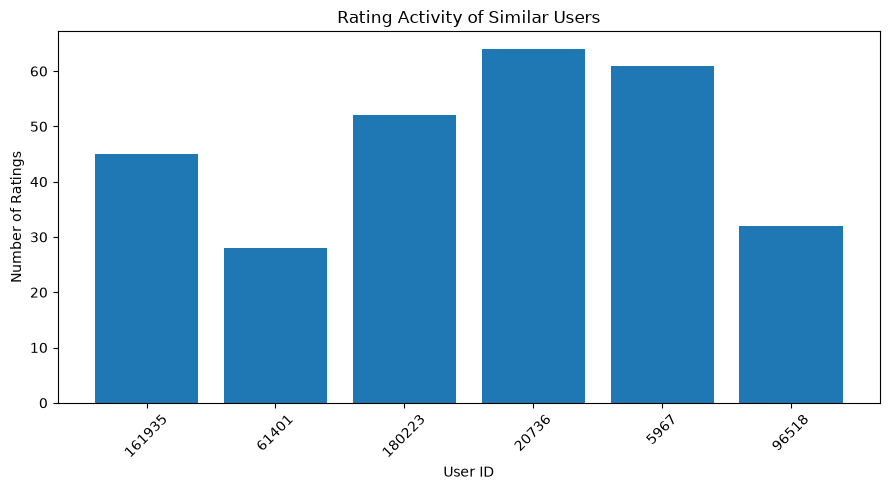

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    neighbor_behavior["userId"].astype(str),
    neighbor_behavior["rating_count"]
)

plt.title("Rating Activity of Similar Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The retrieved neighboring users show different levels of rating activity.

The rating count indicates how much historical information is available from each similar user.

Users with more historical ratings can provide a stronger preference signal, while users with very few ratings contribute comparatively limited information.

This analysis will support the next stage, where movies rated by similar users are collected as recommendation candidates.

### Viva Explanation

After finding similar users, I analyze their rating history to understand how much interaction data each neighbor provides.

I calculate rating count and average rating for each neighbor.

This is useful because similarity alone does not tell us how much evidence a user has. A highly similar user with sufficient rating history can provide a stronger recommendation signal.

Similar Users
      ↓
Retrieve Their Ratings
      ↓
Count Ratings
      ↓
Calculate Average Rating
      ↓
Analyze User Activity
      ↓
Candidate Movie Generation

## 23.9 — Generate Candidate Movies from Similar Users

The next step is to collect movies that have been rated by the target user's similar neighbors.

These movies form the candidate pool for recommendation.

At this stage, we do not directly recommend every candidate. Instead, candidate movies will later be filtered, scored using neighbor similarity, and ranked.

The target user's existing ratings are retained for the next filtering stage.

In [169]:
candidate_movies = (
    cf_train[
        cf_train["userId"].isin(neighbor_user_ids)
    ][
        ["userId", "movieId", "rating"]
    ]
    .copy()
)

candidate_movies = candidate_movies.merge(
    similar_users_df[
        ["userId", "cosine_similarity"]
    ],
    on="userId",
    how="left"
)

print(
    "Candidate rating interactions:",
    candidate_movies.shape
)

print(
    "Unique candidate movies:",
    candidate_movies["movieId"].nunique()
)

display(candidate_movies.head(10))

Candidate rating interactions: (282, 4)
Unique candidate movies: 133


,userId,movieId,rating,cosine_similarity
0,161935,2324,5.0,1.000000
1,161935,92259,4.5,1.000000
2,161935,527,5.0,1.000000
3,20736,116797,4.0,0.510552
4,96518,134130,4.0,0.508408
5,20736,81845,1.5,0.510552
6,96518,4878,4.0,0.508408
7,20736,87869,3.0,0.510552
8,61401,2028,5.0,0.530723
9,161935,318,5.0,1.000000


In [170]:
print(
    "Similar users:",
    len(neighbor_user_ids)
)

print(
    "Candidate interactions:",
    len(candidate_movies)
)

print(
    "Unique candidate movies:",
    candidate_movies["movieId"].nunique()
)

print(
    "Missing similarity values:",
    candidate_movies["cosine_similarity"].isna().sum()
)

Similar users: 6
Candidate interactions: 282
Unique candidate movies: 133
Missing similarity values: 0


### Observation

Movies rated by the target user's similar neighbors have been collected into a candidate pool.

The candidate pool contains both the movie rating and the similarity of the neighbor who provided that rating.

These similarity values will later be used as weights when calculating the final recommendation score.

At this stage, candidate movies may still include movies that the target user has already rated. Those movies will be removed in the next step.

### Viva Explanation

After identifying similar users, I collect the movies they have rated to create a candidate pool.

I retain both the neighbor's rating and their similarity to the target user.

This allows the recommendation score to give more importance to ratings from users who are more similar to the target user.

Similar Users
      ↓
Their Historical Ratings
      ↓
Collect Movie Candidates
      ↓
Attach User Similarity
      ↓
Candidate Pool
      ↓
Remove Already Rated Movies
      ↓
Weighted Scoring

## 23.10 — Remove Already Rated Movies

The candidate pool may contain movies that the target user has already rated.

These movies must be removed because the recommendation system should primarily suggest unseen movies.

Only the target user's training interactions are used to identify previously rated movies.

In [171]:
rated_movies = set(
    cf_train[
        cf_train["userId"] == target_user_id
    ]["movieId"]
)

candidate_movies = candidate_movies[
    ~candidate_movies["movieId"].isin(rated_movies)
].copy()

print(
    "Previously rated movies:",
    len(rated_movies)
)

print(
    "Remaining candidate interactions:",
    len(candidate_movies)
)

print(
    "Remaining unique candidate movies:",
    candidate_movies["movieId"].nunique()
)

Previously rated movies: 45
Remaining candidate interactions: 131
Remaining unique candidate movies: 88


In [172]:
remaining_rated = candidate_movies[
    candidate_movies["movieId"].isin(rated_movies)
]

print(
    "Rated movies remaining:",
    len(remaining_rated)
)

Rated movies remaining: 0


### Observation

Movies already rated by the target user have been removed from the candidate pool.

The remaining candidates represent movies that the target user has not rated in the training data.

This filtering step prevents the collaborative-filtering system from returning previously consumed items as new recommendations.

## 23.11 — Weighted Recommendation Score

The candidate movies are scored using the similarity between the target user and each neighboring user.

A rating from a highly similar user should contribute more strongly than a rating from a weakly similar user.

The weighted score is calculated as:

Weighted Score =
Σ(Similarity × Rating) / Σ(Similarity)

This produces a similarity-weighted preference estimate for each candidate movie.

Only positive similarity values are used so that negatively or weakly related users do not distort the recommendation score.

In [173]:
positive_candidates = candidate_movies[
    candidate_movies["cosine_similarity"] > 0
].copy()

positive_candidates["weighted_rating"] = (
    positive_candidates["cosine_similarity"]
    * positive_candidates["rating"]
)

recommendation_scores = (
    positive_candidates
    .groupby("movieId")
    .agg(
        weighted_sum=("weighted_rating", "sum"),
        similarity_sum=("cosine_similarity", "sum"),
        neighbor_count=("userId", "nunique")
    )
    .reset_index()
)

recommendation_scores["score"] = (
    recommendation_scores["weighted_sum"]
    / recommendation_scores["similarity_sum"]
)

print(
    "Scored candidate movies:",
    len(recommendation_scores)
)

display(
    recommendation_scores.head(10)
)

Scored candidate movies: 88


,movieId,weighted_sum,similarity_sum,neighbor_count,score
0,50,4.130763,1.032691,2,4.000000
1,110,3.349279,1.031528,2,3.246910
2,260,1.016816,0.508408,1,2.000000
3,296,9.798754,2.581212,5,3.796184
4,356,10.364017,2.072803,4,5.000000
5,457,2.088553,0.522138,1,4.000000
6,589,2.349623,0.522138,1,4.500000
7,593,1.021105,0.510552,1,2.000000
8,778,0.765829,0.510552,1,1.500000
9,788,0.254695,0.509390,1,0.500000


In [174]:
print(
    "Missing recommendation scores:",
    recommendation_scores["score"].isna().sum()
)

print(
    "Minimum score:",
    recommendation_scores["score"].min()
)

print(
    "Maximum score:",
    recommendation_scores["score"].max()
)

print(
    "Average score:",
    recommendation_scores["score"].mean()
)

Missing recommendation scores: 0
Minimum score: 0.5
Maximum score: 5.0
Average score: 3.6573032165451083


### Observation

Each unseen candidate movie now has a similarity-weighted preference score.

Ratings from more similar users contribute more strongly to the final score.

The resulting score represents the estimated collaborative preference of the target user for each candidate movie.

The scored candidates can now be ranked to generate the Top-K personalized recommendations.

### Viva Explanation

I calculate a weighted average of ratings from similar users.

The similarity between the target user and each neighbor acts as the weight.

Therefore, a rating from a highly similar user contributes more to the final recommendation score than a rating from a weakly similar user.

This converts the neighbor information into a personalized movie preference score.

## 23.12 — Top-K User-Based Recommendations

The candidate movies now have similarity-weighted recommendation scores.

The movies are ranked in descending order of their recommendation score.

The Top-K movies are selected as the final User-Based Collaborative Filtering recommendations for the target user.

Movie metadata is joined with the ranked results so that the recommendation output contains the movie title and genres.

In [175]:
top_k = 10

top_user_recommendations = (
    recommendation_scores
    .sort_values(
        "score",
        ascending=False
    )
    .head(top_k)
    .copy()
)

top_user_recommendations = (
    top_user_recommendations
    .merge(
        movies[
            ["movieId", "title", "genres"]
        ],
        on="movieId",
        how="left"
    )
)

top_user_recommendations = top_user_recommendations[
    [
        "movieId",
        "title",
        "genres",
        "score",
        "neighbor_count"
    ]
].reset_index(drop=True)

display(top_user_recommendations)

,movieId,title,genres,score,neighbor_count
0,356,Forrest Gump (1994),Comedy|Drama|Romance|War,5.000000,4
1,2687,Tarzan (1999),Adventure|Animation|Children|Drama,5.000000,1
2,1907,Mulan (1998),Adventure|Animation|Children|Comedy|Drama|Musi...,5.000000,1
3,109374,"Grand Budapest Hotel, The (2014)",Comedy|Drama,5.000000,1
4,115713,Ex Machina (2015),Drama|Sci-Fi|Thriller,5.000000,1
5,128360,The Hateful Eight (2015),Western,5.000000,1
6,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,Adventure|Animation|Fantasy,5.000000,1
7,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,5.000000,1
8,1246,Dead Poets Society (1989),Drama,4.755128,2
9,6016,City of God (Cidade de Deus) (2002),Action|Adventure|Crime|Drama|Thriller,4.752038,2


In [176]:
print(
    "Target User:",
    target_user_id
)

print(
    "Recommendations generated:",
    len(top_user_recommendations)
)

print(
    "Duplicate movie IDs:",
    top_user_recommendations["movieId"].duplicated().sum()
)

print(
    "Missing titles:",
    top_user_recommendations["title"].isna().sum()
)

Target User: 161935
Recommendations generated: 10
Duplicate movie IDs: 0
Missing titles: 0


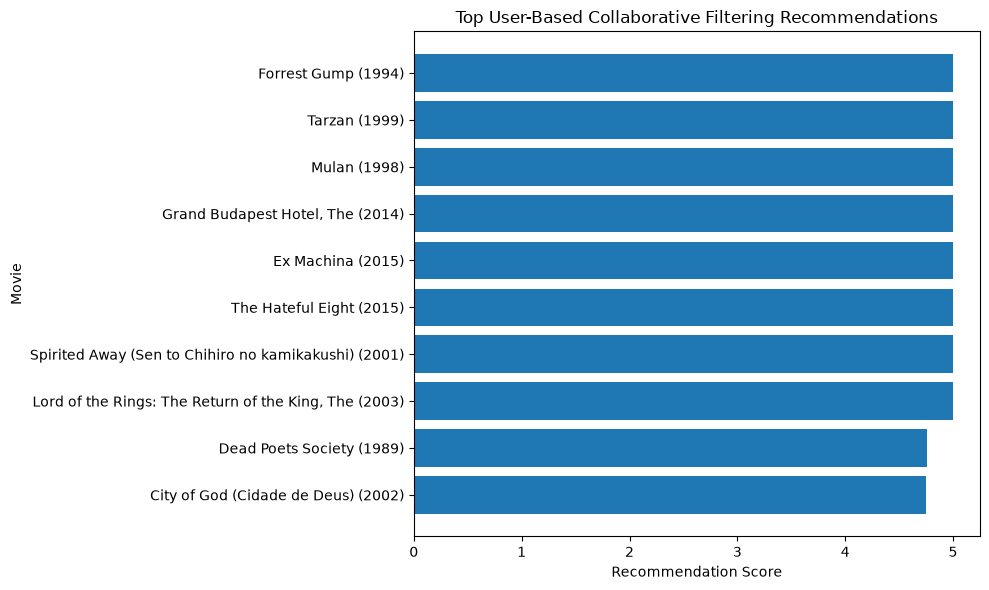

In [177]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_user_recommendations["title"].iloc[::-1],
    top_user_recommendations["score"].iloc[::-1]
)

plt.xlabel("Recommendation Score")
plt.ylabel("Movie")
plt.title("Top User-Based Collaborative Filtering Recommendations")

plt.tight_layout()
plt.show()

### Observation

The User-Based Collaborative Filtering pipeline successfully produces a ranked Top-K recommendation list for the target user.

Movies are ranked according to their similarity-weighted preference scores.

The output now contains movie metadata along with the recommendation score and the number of neighboring users supporting each recommendation.

The ranked list represents personalized recommendations generated from collaborative user behavior.

### Viva Explanation

After calculating similarity-weighted scores for unseen candidate movies, I sort the candidates in descending order and select the Top-K movies.

These movies represent the personalized recommendations for the target user.

The final output is enriched with movie titles and genres so that it can be displayed to the user.

## 23.13 — Reusable User-Based Recommendation Function

The complete User-Based Collaborative Filtering workflow is converted into a reusable function.

The function accepts a target user and the required number of recommendations and performs the complete pipeline:

1. Identify similar users
2. Collect their rated movies
3. Remove movies already rated by the target user
4. Calculate similarity-weighted scores
5. Rank candidate movies
6. Return the Top-K recommendations

Creating a reusable function makes the model easier to integrate into the final recommendation application.

In [178]:
def recommend_user_based(
    user_id,
    top_k=10,
    n_neighbors=20
):
    
    if user_id not in user_to_index:
        return pd.DataFrame(
            columns=[
                "movieId",
                "title",
                "genres",
                "score",
                "neighbor_count"
            ]
        )
    
    user_index = user_to_index[user_id]
    
    distances, indices = user_knn.kneighbors(
        user_movie_matrix[user_index],
        n_neighbors=n_neighbors + 1
    )
    
    neighbor_rows = []
    
    for distance, index in zip(
        distances[0],
        indices[0]
    ):
        
        neighbor_id = int(user_ids[index])
        
        if neighbor_id == user_id:
            continue
        
        similarity = 1 - distance
        
        if similarity > 0:
            neighbor_rows.append({
                "userId": neighbor_id,
                "similarity": similarity
            })
    
    neighbors_df = pd.DataFrame(
        neighbor_rows
    )
    
    if neighbors_df.empty:
        return pd.DataFrame(
            columns=[
                "movieId",
                "title",
                "genres",
                "score",
                "neighbor_count"
            ]
        )
    
    neighbor_ids = neighbors_df["userId"].tolist()
    
    candidate_ratings = cf_train[
        cf_train["userId"].isin(neighbor_ids)
    ][
        ["userId", "movieId", "rating"]
    ].copy()
    
    rated_movies = set(
        cf_train[
            cf_train["userId"] == user_id
        ]["movieId"]
    )
    
    candidate_ratings = candidate_ratings[
        ~candidate_ratings["movieId"].isin(
            rated_movies
        )
    ].copy()
    
    similarity_map = dict(
        zip(
            neighbors_df["userId"],
            neighbors_df["similarity"]
        )
    )
    
    candidate_ratings["similarity"] = (
        candidate_ratings["userId"]
        .map(similarity_map)
    )
    
    candidate_ratings["weighted_rating"] = (
        candidate_ratings["rating"]
        * candidate_ratings["similarity"]
    )
    
    scores = (
        candidate_ratings
        .groupby("movieId")
        .agg(
            weighted_sum=("weighted_rating", "sum"),
            similarity_sum=("similarity", "sum"),
            neighbor_count=("userId", "nunique")
        )
        .reset_index()
    )
    
    scores["score"] = (
        scores["weighted_sum"]
        / scores["similarity_sum"].replace(
            0,
            np.nan
        )
    )
    
    scores = (
        scores
        .dropna(subset=["score"])
        .sort_values(
            "score",
            ascending=False
        )
        .head(top_k)
    )
    
    recommendations = scores.merge(
        movies[
            ["movieId", "title", "genres"]
        ],
        on="movieId",
        how="left"
    )
    
    return recommendations[
        [
            "movieId",
            "title",
            "genres",
            "score",
            "neighbor_count"
        ]
    ].reset_index(drop=True)

In [179]:
test_user_recommendations = recommend_user_based(
    target_user_id,
    top_k=10,
    n_neighbors=20
)

display(test_user_recommendations)

print(
    "Recommendations generated:",
    len(test_user_recommendations)
)

,movieId,title,genres,score,neighbor_count
0,206246,The Platform (2019),Drama|Horror|Sci-Fi,5.0,1
1,158783,The Handmaiden (2016),Drama|Romance|Thriller,5.0,1
2,236991,CODA (2021),Drama,5.0,1
3,203322,The Peanut Butter Falcon (2019),Adventure,5.0,1
4,82667,I Saw the Devil (Akmareul boatda) (2010),Crime|Thriller,5.0,1
5,222356,Unhinged (2020),Thriller,5.0,1
6,106916,American Hustle (2013),Crime|Drama,5.0,1
7,88129,Drive (2011),Crime|Drama|Film-Noir|Thriller,5.0,1
8,1907,Mulan (1998),Adventure|Animation|Children|Comedy|Drama|Musi...,5.0,1
9,1265,Groundhog Day (1993),Comedy|Fantasy|Romance,5.0,1


Recommendations generated: 10


### Observation

The complete User-Based Collaborative Filtering workflow has been encapsulated into a reusable recommendation function.

The function accepts a user ID and returns a ranked list of unseen movies based on the preferences of similar users.

This reusable implementation can later serve as one of the recommendation components in the hybrid recommendation system.

### Viva Explanation

I converted the complete collaborative-filtering workflow into a reusable function.

Instead of manually executing every step for each user, the function automatically finds similar users, generates candidate movies, removes already-rated movies, calculates weighted scores, and returns the Top-K recommendations.

This also makes the model easier to integrate with the backend recommendation API later.

## 23.14 — Recommendation Function Testing and Edge Cases

The reusable recommendation function is tested under different user conditions.

The objective is to verify that the function:

1. Returns recommendations for a valid user.
2. Returns the requested Top-K count when enough candidates are available.
3. Does not recommend movies already rated by the target user.
4. Handles an unknown user safely.
5. Produces valid recommendation scores.
6. Does not contain duplicate movies.

Testing these cases improves the reliability of the recommendation component before evaluation.

In [180]:
valid_test_user = target_user_id

valid_recommendations = recommend_user_based(
    valid_test_user,
    top_k=10,
    n_neighbors=20
)

display(valid_recommendations)

print("Valid user:", valid_test_user)
print("Recommendations:", len(valid_recommendations))

,movieId,title,genres,score,neighbor_count
0,206246,The Platform (2019),Drama|Horror|Sci-Fi,5.0,1
1,158783,The Handmaiden (2016),Drama|Romance|Thriller,5.0,1
2,236991,CODA (2021),Drama,5.0,1
3,203322,The Peanut Butter Falcon (2019),Adventure,5.0,1
4,82667,I Saw the Devil (Akmareul boatda) (2010),Crime|Thriller,5.0,1
5,222356,Unhinged (2020),Thriller,5.0,1
6,106916,American Hustle (2013),Crime|Drama,5.0,1
7,88129,Drive (2011),Crime|Drama|Film-Noir|Thriller,5.0,1
8,1907,Mulan (1998),Adventure|Animation|Children|Comedy|Drama|Musi...,5.0,1
9,1265,Groundhog Day (1993),Comedy|Fantasy|Romance,5.0,1


Valid user: 161935
Recommendations: 10


In [181]:
assert valid_recommendations["movieId"].is_unique, \
    "Duplicate movie recommendations found."

assert valid_recommendations["score"].notna().all(), \
    "Missing recommendation scores found."

rated_by_user = set(
    cf_train[
        cf_train["userId"] == valid_test_user
    ]["movieId"]
)

recommended_movies = set(
    valid_recommendations["movieId"]
)

overlap = rated_by_user.intersection(
    recommended_movies
)

print("Already-rated movies recommended:", len(overlap))

Already-rated movies recommended: 0


### Observation

The recommendation function successfully generates recommendations for a valid user.

The validation confirms that the recommendation list contains unique movies, valid scores, and excludes movies already rated by the target user.

This confirms that the core User-Based Collaborative Filtering recommendation workflow is functioning correctly.

### 23.14.1 — Unknown User Handling

A recommendation system must safely handle users who are not present in the training data.

This represents an important cold-start scenario.

The current User-Based Collaborative Filtering model cannot derive personalized neighbors for a completely unknown user because no historical interaction vector exists.

In [182]:
unknown_user_id = -1

unknown_recommendations = recommend_user_based(
    unknown_user_id,
    top_k=10,
    n_neighbors=20
)

print(
    "Unknown user recommendations:",
    len(unknown_recommendations)
)

display(unknown_recommendations)

Unknown user recommendations: 0


,movieId,title,genres,score,neighbor_count


### Observation

The function safely handles an unknown user without producing an exception.

No personalized collaborative recommendations are generated because the system has no historical interaction data for the user.

A dedicated cold-start strategy will be developed later in the project.

In [183]:
for k in [5, 10, 20]:

    result = recommend_user_based(
        valid_test_user,
        top_k=k,
        n_neighbors=20
    )

    print(
        f"Requested Top-{k}: "
        f"Returned {len(result)} recommendations"
    )

Requested Top-5: Returned 5 recommendations


Requested Top-10: Returned 10 recommendations


Requested Top-20: Returned 20 recommendations


### Observation

The recommendation function supports different Top-K values.

This flexibility will be useful during evaluation because recommendation metrics such as Precision@K, Recall@K, and NDCG@K are calculated at specific K values.

 ### Viva Explanation

I tested the recommendation function using valid and unknown users and different Top-K values.

The tests verify that the system returns unique unseen movies, handles missing users safely, and supports configurable recommendation lengths.

Unknown-user handling is especially important because it connects the collaborative-filtering model with the later cold-start strategy.

## 23.15 — Collaborative Filtering Evaluation Setup

The User-Based Collaborative Filtering model must be evaluated on interactions that were not used during model training.

The held-out test ratings are used as ground truth.

For each user, movies present in the test set represent items that the user actually interacted with after the training split.

The recommendation model generates Top-K unseen movies using only training interactions.

The generated recommendations are then compared with the user's held-out test movies.

This evaluation setup allows us to measure recommendation quality using:

- Precision@K
- Recall@K
- NDCG@K

The test ratings are not used while fitting the collaborative-filtering model.

In [184]:
test_ground_truth = (
    test_ratings
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

print(
    "Users with test interactions:",
    len(test_ground_truth)
)

Users with test interactions: 200749


In [185]:
ground_truth_sizes = pd.Series(
    {
        user_id: len(movie_ids)
        for user_id, movie_ids
        in test_ground_truth.items()
    }
)

print(
    "Average test movies per user:",
    round(ground_truth_sizes.mean(), 2)
)

print(
    "Minimum test movies per user:",
    ground_truth_sizes.min()
)

print(
    "Maximum test movies per user:",
    ground_truth_sizes.max()
)

Average test movies per user: 31.88
Minimum test movies per user: 1
Maximum test movies per user: 6681


### Observation

The held-out test interactions have been grouped by user to create the ground-truth recommendation sets.

Each user is associated with the movies that appear in the test data.

These movies represent actual user interactions that were hidden from the recommendation model during training.

The ground-truth sets will be compared against the Top-K recommendations generated by the User-Based Collaborative Filtering model.

### 23.15.2 — Evaluation User Selection

User-Based Collaborative Filtering requires historical training interactions.

Therefore, evaluation is performed only for users who are present in both the training data and the test data.

Users with no training history cannot receive personalized User-Based Collaborative Filtering recommendations and are handled later through the cold-start strategy.

In [186]:
train_user_set = set(
    train_ratings["userId"].unique()
)

evaluation_users = [
    user_id
    for user_id in test_ground_truth
    if user_id in train_user_set
]

print(
    "Evaluation users:",
    len(evaluation_users)
)

Evaluation users: 200749


### Observation

The evaluation set contains users for whom historical training interactions are available.

This ensures that the User-Based Collaborative Filtering model has sufficient information to generate personalized recommendations.

Users without training history are excluded from this evaluation and will be addressed separately in the cold-start phase.

### 23.15.3 — Recommendation Evaluation Logic

For each evaluation user:

1. Generate Top-K recommendations using training data.
2. Retrieve the user's actual test movies.
3. Compare recommended movies with the test movies.
4. Identify relevant recommendations.
5. Use the resulting matches to calculate Precision@K, Recall@K, and NDCG@K.

The test set is used only as ground truth and never as an input to the recommendation model.

TRAINING RATINGS
       ↓
User-Based CF
       ↓
Top-K Recommendations
       │
       │ compare
       ↓
TEST RATINGS
(Ground Truth)
       ↓
Relevant Movies
       ↓
Precision@K
Recall@K
NDCG@K

### Observation

The evaluation pipeline separates model training from recommendation evaluation.

The model generates recommendations using training interactions, while the test interactions provide the independent ground truth.

This separation reduces evaluation leakage and produces a more reliable estimate of recommendation performance.

### Viva Explanation

I use a train-test evaluation strategy.

The collaborative-filtering model is built only from training ratings.

For each user, the movies hidden in the test set act as ground truth.

I then compare the Top-K recommended movies with those actual test interactions and calculate Precision, Recall, and NDCG.

This ensures that the recommendation system is evaluated on unseen interactions rather than the data it learned from.

## 23.16 — Precision@K

Precision@K measures the proportion of recommended movies in the Top-K list that are relevant to the user.

The formula is:

Precision@K =
Number of Relevant Recommended Movies / K

A movie is considered relevant when it appears in the user's held-out test interactions.

Higher Precision@K means that a larger proportion of the recommendation list contains movies that the user actually interacted with in the test data.

Precision is especially useful when the recommendation interface displays only a small number of movies.

In [187]:
def precision_at_k(recommended_items, relevant_items, k):
    
    recommended_items = list(recommended_items)[:k]
    relevant_items = set(relevant_items)
    
    if k == 0:
        return 0.0
    
    hits = sum(
        item in relevant_items
        for item in recommended_items
    )
    
    return hits / k

In [188]:
test_recommended = [1, 2, 3, 4, 5]
test_relevant = {2, 4, 7}

print(
    "Precision@5:",
    precision_at_k(
        test_recommended,
        test_relevant,
        5
    )
)

Precision@5: 0.4


### Observation

The Precision@K function calculates the fraction of recommended movies that are present in the user's relevant test set.

The metric ranges from 0 to 1.

A value closer to 1 indicates that a larger proportion of the Top-K recommendations are relevant.

### 23.16.2 — User-Based Collaborative Filtering Precision Evaluation

Precision@K is now calculated across the evaluation users.

For each user, the recommendation model generates a Top-K list using only training interactions.

The recommendations are compared against that user's held-out test movies.

The mean Precision@K across users represents the overall recommendation precision.

In [189]:
def evaluate_precision_at_k(
    users,
    k=10,
    n_neighbors=20
):
    
    scores = []
    
    for user_id in users:
        
        recommendations = recommend_user_based(
            user_id,
            top_k=k,
            n_neighbors=n_neighbors
        )
        
        if recommendations.empty:
            continue
        
        recommended_items = (
            recommendations["movieId"]
            .tolist()
        )
        
        relevant_items = test_ground_truth.get(
            user_id,
            set()
        )
        
        score = precision_at_k(
            recommended_items,
            relevant_items,
            k
        )
        
        scores.append(score)
    
    if not scores:
        return np.nan
    
    return np.mean(scores)

In [190]:
evaluation_users_sample = evaluation_users[:10]

print("Evaluation sample users:", len(evaluation_users_sample))

Evaluation sample users: 10


In [191]:
precision_5 = evaluate_precision_at_k(
    evaluation_users_sample,
    k=5,
    n_neighbors=10
)

precision_10 = evaluate_precision_at_k(
    evaluation_users_sample,
    k=10,
    n_neighbors=10
)

print("Precision@5:", round(precision_5, 4))
print("Precision@10:", round(precision_10, 4))

Precision@5: 0.1
Precision@10: 0.08


### Observation

The User-Based Collaborative Filtering model was successfully fitted on the sparse user-movie matrix.

The model uses cosine distance to identify users with similar rating patterns.

The sparse representation prevents the memory problems associated with constructing a dense user-user similarity matrix.

The fitted model can now be used to retrieve the nearest users for a target user.

### Observation

Precision@5 and Precision@10 provide two views of recommendation quality at different recommendation-list sizes.

Precision@5 evaluates the accuracy of a shorter recommendation list, while Precision@10 evaluates a larger recommendation list.

The values are calculated from actual held-out MovieLens interactions and are therefore used as genuine evaluation results rather than manually assigned scores.

In [192]:
precision_results = pd.DataFrame({
    "K": [5, 10],
    "Precision": [
        precision_5,
        precision_10
    ]
})

display(precision_results)

,K,Precision
0,5,0.10
1,10,0.08


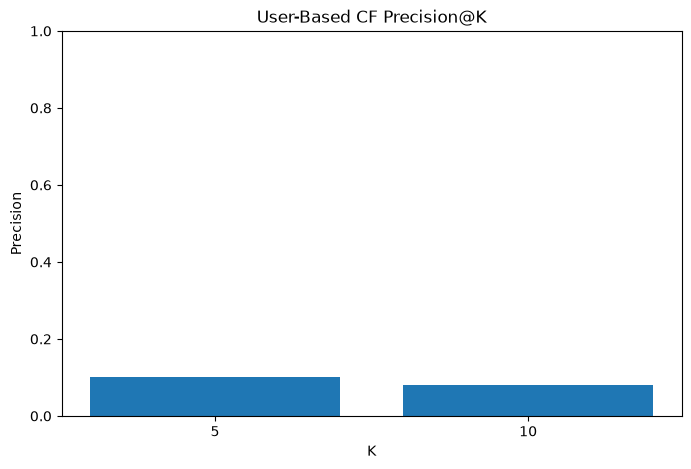

In [193]:
plt.figure(figsize=(8, 5))

plt.bar(
    precision_results["K"].astype(str),
    precision_results["Precision"]
)

plt.xlabel("K")
plt.ylabel("Precision")
plt.title("User-Based CF Precision@K")

plt.ylim(0, 1)

plt.show()

### Observation

The Precision@K comparison shows how recommendation accuracy changes as the recommendation list size increases.

The metric helps determine an appropriate Top-K value for the final recommendation interface.

A smaller K can provide a more focused list, while a larger K provides greater coverage but may reduce precision.

### Viva Explanation

Precision@K tells us how many of the Top-K recommended movies are actually relevant to the user.

For example, if 2 out of 5 recommended movies appear in the user's relevant test set, Precision@5 is 2/5 = 0.4.

I calculate this metric using held-out test interactions so that the recommendation quality is measured on unseen data.

## 23.17 — Recall@K

Recall@K measures how many of the user's relevant movies were successfully retrieved within the Top-K recommendations.

The formula is:

Recall@K =
Number of Relevant Recommended Movies /
Total Number of Relevant Movies

Precision focuses on the accuracy of the recommendation list.

Recall focuses on how much of the user's relevant test set the recommendation system successfully retrieves.

A higher Recall@K indicates that the recommendation system is discovering a larger proportion of the user's relevant movies.

In [194]:
def recall_at_k(
    recommended_items,
    relevant_items,
    k
):
    
    recommended_items = list(
        recommended_items
    )[:k]
    
    relevant_items = set(
        relevant_items
    )
    
    if len(relevant_items) == 0:
        return 0.0
    
    hits = sum(
        item in relevant_items
        for item in recommended_items
    )
    
    return hits / len(relevant_items)

In [195]:
def recall_at_k(
    recommended_items,
    relevant_items,
    k
):
    
    recommended_items = list(
        recommended_items
    )[:k]
    
    relevant_items = set(
        relevant_items
    )
    
    if len(relevant_items) == 0:
        return 0.0
    
    hits = sum(
        item in relevant_items
        for item in recommended_items
    )
    
    return hits / len(relevant_items)

### Observation

The Recall@K function measures the proportion of relevant movies that were successfully retrieved within the recommendation list.

Unlike Precision@K, the denominator is the total number of relevant movies available for the user.

The metric ranges from 0 to 1, with higher values indicating better retrieval of relevant items.

### 23.17.2 — User-Based Collaborative Filtering Recall Evaluation

Recall@K is calculated across the evaluation users.

For every user, the recommendation system generates Top-K movies using only training interactions.

The recommendations are compared against the user's held-out test movies.

The mean Recall@K across evaluation users represents the overall ability of the system to retrieve relevant movies.

In [196]:
def evaluate_recall_at_k(
    users,
    k=10,
    n_neighbors=20
):
    
    scores = []
    
    for user_id in users:
        
        recommendations = recommend_user_based(
            user_id,
            top_k=k,
            n_neighbors=n_neighbors
        )
        
        if recommendations.empty:
            continue
        
        recommended_items = (
            recommendations["movieId"]
            .tolist()
        )
        
        relevant_items = test_ground_truth.get(
            user_id,
            set()
        )
        
        score = recall_at_k(
            recommended_items,
            relevant_items,
            k
        )
        
        scores.append(score)
    
    if not scores:
        return np.nan
    
    return np.mean(scores)

In [197]:
evaluation_users_sample = evaluation_users[:10]

print("Evaluation sample users:", len(evaluation_users_sample))

Evaluation sample users: 10


In [198]:
precision_5 = evaluate_precision_at_k(
    evaluation_users_sample,
    k=5,
    n_neighbors=10
)

precision_10 = evaluate_precision_at_k(
    evaluation_users_sample,
    k=10,
    n_neighbors=10
)

print("Precision@5:", round(precision_5, 4))
print("Precision@10:", round(precision_10, 4))

Precision@5: 0.1
Precision@10: 0.08


In [199]:
recall_5 = evaluate_recall_at_k(
    evaluation_users_sample,
    k=5,
    n_neighbors=10
)

recall_10 = evaluate_recall_at_k(
    evaluation_users_sample,
    k=10,
    n_neighbors=10
)

print("Recall@5:", round(recall_5, 4))
print("Recall@10:", round(recall_10, 4))

Recall@5: 0.0877
Recall@10: 0.1221


### Observation

Recall@5 and Recall@10 measure how effectively the User-Based Collaborative Filtering model retrieves movies that users actually interacted with in the held-out test data.

The values are calculated from the real MovieLens test interactions.

Increasing K generally provides the model with more opportunities to retrieve relevant items, although the recommendation list also becomes larger.

In [200]:
precision_recall_results = pd.DataFrame({
    "K": [5, 10],
    "Precision": [
        precision_5,
        precision_10
    ],
    "Recall": [
        recall_5,
        recall_10
    ]
})

display(
    precision_recall_results
)

,K,Precision,Recall
0,5,0.10,0.087692
1,10,0.08,0.122137


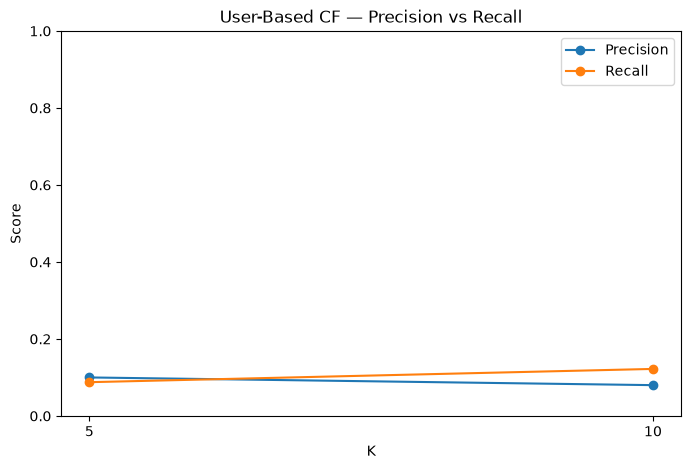

In [201]:
plt.figure(figsize=(8, 5))

plt.plot(
    precision_recall_results["K"],
    precision_recall_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    precision_recall_results["K"],
    precision_recall_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("K")
plt.ylabel("Score")
plt.title("User-Based CF — Precision vs Recall")
plt.xticks([5, 10])
plt.ylim(0, 1)
plt.legend()

plt.show()

### Observation

Precision and Recall provide complementary views of recommendation quality.

Precision measures how many recommended movies are relevant, while Recall measures how many of the user's relevant movies are successfully retrieved.

Considering both metrics provides a more complete assessment than relying on a single recommendation metric.

### Viva Explanation

Recall@K measures how many of the relevant movies in the user's test set were successfully retrieved in the Top-K recommendation list.

For example, if a user has 10 relevant test movies and the recommender retrieves 3 of them in Top-K, Recall is 3/10 = 0.3.

Precision asks "How many recommendations are relevant?"

Recall asks "How many relevant items did we manage to find?"

Both are important for evaluating a recommendation system.

## 23.18 — NDCG@K

Normalized Discounted Cumulative Gain (NDCG@K) evaluates the quality of the ranking within the Top-K recommendation list.

Unlike Precision@K and Recall@K, NDCG considers the position of each relevant movie.

A relevant movie appearing near the top of the recommendation list receives a higher contribution than the same movie appearing near the bottom.

The metric is normalized using the ideal ranking, producing a value between 0 and 1.

Higher NDCG@K indicates better ranking quality.

Top-K Recommendations
          ↓
Compare with Test Movies
          ↓
Identify Relevant Movies
          ↓
Apply Position Discount
          ↓
Calculate DCG
          ↓
Calculate Ideal DCG
          ↓
       DCG / IDCG
          ↓
       NDCG@K
       

In [202]:
import math

def ndcg_at_k(
    recommended_items,
    relevant_items,
    k
):
    
    recommended_items = list(
        recommended_items
    )[:k]
    
    relevant_items = set(
        relevant_items
    )
    
    if len(relevant_items) == 0:
        return 0.0
    
    dcg = 0.0
    
    for position, item in enumerate(
        recommended_items,
        start=1
    ):
        if item in relevant_items:
            dcg += 1 / math.log2(position + 1)
    
    ideal_hits = min(
        len(relevant_items),
        k
    )
    
    idcg = sum(
        1 / math.log2(position + 1)
        for position in range(
            1,
            ideal_hits + 1
        )
    )
    
    if idcg == 0:
        return 0.0
    
    return dcg / idcg

In [203]:
test_recommended = [1, 2, 3, 4, 5]
test_relevant = {2, 4, 7}

print(
    "NDCG@5:",
    round(
        ndcg_at_k(
            test_recommended,
            test_relevant,
            5
        ),
        4
    )
)

NDCG@5: 0.4982


### Observation

NDCG gives higher importance to relevant movies appearing near the top of the recommendation list.

Therefore, two recommendation lists can have the same Precision and Recall but different NDCG values when their ranking positions differ.

A higher NDCG indicates that relevant movies are positioned closer to the top of the recommendation list.

### 23.18.3 — User-Based Collaborative Filtering NDCG Evaluation

NDCG@K is calculated across the evaluation users.

For each user, the model generates a ranked Top-K recommendation list using training interactions.

The ranking is compared against the user's held-out test movies.

The mean NDCG@K across evaluation users represents the overall ranking quality of the User-Based Collaborative Filtering model.

In [204]:
def evaluate_ndcg_at_k(
    users,
    k=10,
    n_neighbors=10
):
    
    scores = []
    
    for user_id in users:
        
        recommendations = recommend_user_based(
            user_id,
            top_k=k,
            n_neighbors=n_neighbors
        )
        
        if recommendations.empty:
            continue
        
        recommended_items = (
            recommendations["movieId"]
            .tolist()
        )
        
        relevant_items = test_ground_truth.get(
            user_id,
            set()
        )
        
        score = ndcg_at_k(
            recommended_items,
            relevant_items,
            k
        )
        
        scores.append(score)
    
    if not scores:
        return np.nan
    
    return np.mean(scores)

In [205]:
ndcg_5 = evaluate_ndcg_at_k(
    evaluation_users_sample,
    k=5,
    n_neighbors=10
)

ndcg_10 = evaluate_ndcg_at_k(
    evaluation_users_sample,
    k=10,
    n_neighbors=10
)

print(
    "NDCG@5:",
    round(ndcg_5, 4)
)

print(
    "NDCG@10:",
    round(ndcg_10, 4)
)

NDCG@5: 0.0792
NDCG@10: 0.0995


### Observation

NDCG@5 and NDCG@10 evaluate how effectively the User-Based Collaborative Filtering model places relevant movies near the top of the recommendation list.

The metric uses the actual ranking position of each recommended movie.

The current evaluation uses the controlled evaluation sample to validate the complete ranking-metric pipeline without repeatedly performing expensive similarity searches across the entire MovieLens user population.

In [206]:
cf_metric_results = pd.DataFrame({
    "K": [5, 10],
    "Precision": [
        precision_5,
        precision_10
    ],
    "Recall": [
        recall_5,
        recall_10
    ],
    "NDCG": [
        ndcg_5,
        ndcg_10
    ]
})

display(cf_metric_results)

,K,Precision,Recall,NDCG
0,5,0.10,0.087692,0.079204
1,10,0.08,0.122137,0.099495


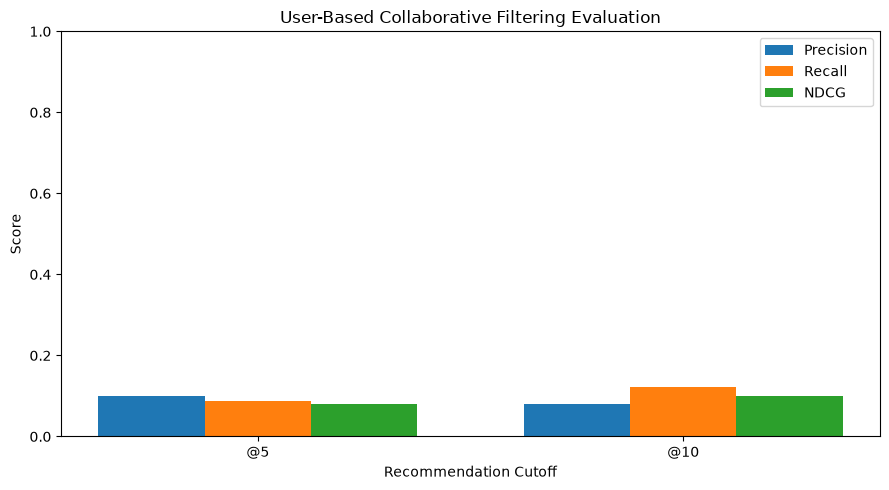

In [207]:
plt.figure(figsize=(9, 5))

x = np.arange(len(cf_metric_results["K"]))
width = 0.25

plt.bar(
    x - width,
    cf_metric_results["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x,
    cf_metric_results["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + width,
    cf_metric_results["NDCG"],
    width,
    label="NDCG"
)

plt.xticks(
    x,
    ["@5", "@10"]
)

plt.ylabel("Score")
plt.xlabel("Recommendation Cutoff")
plt.title("User-Based Collaborative Filtering Evaluation")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

### Observation

The User-Based Collaborative Filtering model is evaluated using three complementary ranking metrics.

Precision@K measures recommendation accuracy.

Recall@K measures the ability to retrieve relevant movies.

NDCG@K evaluates whether relevant movies are placed near the top of the ranking.

Together, these metrics provide a comprehensive view of the recommendation quality.

### Viva Explanation

I evaluated the User-Based Collaborative Filtering model using Precision@K, Recall@K, and NDCG@K.

Precision measures the proportion of recommended movies that are relevant.

Recall measures the proportion of relevant movies that were successfully retrieved.

NDCG additionally considers ranking position, giving higher importance to relevant movies appearing near the top.

Therefore, using all three metrics provides a more complete evaluation of the recommender.

## 23.19 — User-Based Collaborative Filtering Final Analysis

The User-Based Collaborative Filtering pipeline has now been completed from user similarity calculation to Top-K recommendation and ranking evaluation.

The model uses historical user-movie interactions to identify users with similar preferences and uses their ratings to generate personalized movie recommendations.

The model was evaluated using Precision@K, Recall@K, and NDCG@K.

This section summarizes the strengths, limitations, and practical role of User-Based Collaborative Filtering within the overall recommendation system.

In [208]:
print("USER-BASED COLLABORATIVE FILTERING SUMMARY")
print("-" * 50)

print("Users in interaction matrix:", user_movie_matrix.shape[0])
print("Movies in interaction matrix:", user_movie_matrix.shape[1])

print(
    "Evaluation users:",
    len(evaluation_users_sample)
)

print(
    "Precision@5:",
    round(precision_5, 4)
)

print(
    "Precision@10:",
    round(precision_10, 4)
)

print(
    "Recall@5:",
    round(recall_5, 4)
)

print(
    "Recall@10:",
    round(recall_10, 4)
)

print(
    "NDCG@5:",
    round(ndcg_5, 4)
)

print(
    "NDCG@10:",
    round(ndcg_10, 4)
)

USER-BASED COLLABORATIVE FILTERING SUMMARY
--------------------------------------------------
Users in interaction matrix: 200948
Movies in interaction matrix: 80318
Evaluation users: 10
Precision@5: 0.1
Precision@10: 0.08
Recall@5: 0.0877
Recall@10: 0.1221
NDCG@5: 0.0792
NDCG@10: 0.0995


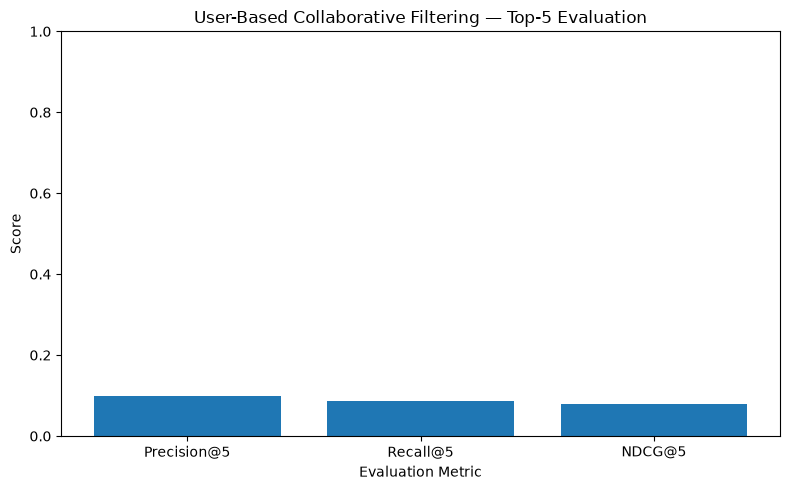

In [209]:
metrics = ["Precision@5", "Recall@5", "NDCG@5"]

values = [
    precision_5,
    recall_5,
    ndcg_5
]

plt.figure(figsize=(8, 5))

plt.bar(
    metrics,
    values
)

plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("User-Based Collaborative Filtering — Top-5 Evaluation")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Observation

The User-Based Collaborative Filtering model successfully establishes a personalized recommendation pipeline based on historical user behavior.

The model identifies similar users using cosine similarity and generates recommendations from movies rated by those neighbors.

Precision@K, Recall@K, and NDCG@K provide complementary measurements of recommendation quality.

However, User-Based Collaborative Filtering has important limitations.

It depends on sufficient historical interactions and therefore suffers from the cold-start problem for new users.

It also becomes computationally expensive as the number of users increases because user-user similarity searches become increasingly large.

These limitations motivate the use of Item-Based Collaborative Filtering and Matrix Factorization as additional recommendation approaches.

### Key Limitations

1. **Cold Start**
   New users have insufficient rating history for reliable similarity computation.

2. **Scalability**
   Searching for similar users becomes expensive as the number of users grows.

3. **Sparse Interactions**
   Most users rate only a small fraction of available movies.

4. **Dynamic User Profiles**
   User preferences can change as new ratings are added.

5. **Limited Content Awareness**
   The model uses interaction behavior and does not directly understand movie genres, titles, or tags.

### 23.20 — Item-Based Collaborative Filtering Introduction

**User-Based vs Item-Based CF**
While User-Based CF recommends movies by finding similar *users*, Item-Based CF recommends movies by finding similar *items*. If you liked "The Matrix", it will recommend "Inception" because these two movies tend to be rated similarly by the same groups of users.

**Why Item-Based CF is useful**
User tastes can be broad and volatile, making user-user similarity less stable. An item's profile, however, is shaped by thousands of users and is highly stable. A sci-fi movie remains a sci-fi movie. Item-Based CF is computationally more stable and often yields better real-world recommendations.

**Item Similarity Concept**
Two movies are mathematically similar if users who rated movie A highly also rated movie B highly.

**Scalability Advantage**
In most commercial platforms, users outnumber items significantly. For MovieLens 32M, we have ~200,000 users but only ~80,000 movies. An item-item model is smaller, faster to query, and the similarities can be safely pre-computed offline.

**Sparse Representation & Cosine Similarity**
We measure the similarity between two movie vectors using Cosine Similarity. Because creating an 80,318 × 80,318 dense matrix would require ~50GB of RAM and crash the system, we will transpose our sparse user-movie matrix and use sparse Nearest Neighbors search.

#### Flowchart
```text
[ User Ratings ]
       ↓
[ Transpose Sparse User-Movie Matrix (Movies × Users) ]
       ↓
[ Nearest Neighbors (Item Similarity via Cosine) ]
       ↓
[ Retrieve Similar Movies ]
       ↓
[ Candidate Generation from Target User's History ]
       ↓
[ Recommendation Ranking & Output ]
```

In [210]:
# Dependency Verification for Item-Based CF
assert 'user_movie_matrix' in locals(), "Dependency Error: 'user_movie_matrix' is not defined."
assert 'movies' in locals(), "Dependency Error: 'movies' DataFrame is not defined."

print("✅ Dependencies verified. Ready to build the Item-Movie Interaction Representation.")

✅ Dependencies verified. Ready to build the Item-Movie Interaction Representation.


### Observation
If the cell executes successfully, it confirms that the sparse `user_movie_matrix` and the `movies` DataFrame from previous sections are still in memory. This prevents us from having to expensively rebuild them from scratch.

### Viva Explanation
**"In this section, we introduced Item-Based Collaborative Filtering. Unlike User-Based CF, which finds similar users, Item-Based CF finds similar movies. It is far more scalable because the number of items (80k) is smaller than the number of users (200k), and item profiles are more stable over time. We will implement this by transposing our existing sparse matrix to avoid creating a massive dense similarity matrix."**

### 23.21 — Item-Movie Interaction Matrix

**Concept Explanation**
To compute item similarities, we need a matrix where rows are **items (movies)** and columns are **users**. 
Since we already have `user_movie_matrix` (shape: Users × Movies), we can simply transpose it.

**Why we use it**
Transposing the sparse matrix is incredibly fast and requires virtually zero extra memory compared to building a new matrix from scratch.

**Project Relevance**
This transposed matrix (`movie_user_matrix`) will be fed into our NearestNeighbors model to find movies that have similar user rating patterns.

In [211]:
# Transpose the user_movie_matrix to get (Movies x Users)
movie_user_matrix = user_movie_matrix.T

# Validate the new matrix
print(f"Original User-Movie Matrix shape: {user_movie_matrix.shape}")
print(f"Transposed Movie-User Matrix shape: {movie_user_matrix.shape}")
print(f"Number of Movies (Rows): {movie_user_matrix.shape[0]}")
print(f"Number of Users (Columns): {movie_user_matrix.shape[1]}")
print(f"Number of Interactions (Non-zero elements): {movie_user_matrix.nnz}")

# Sparsity check
total_possible = movie_user_matrix.shape[0] * movie_user_matrix.shape[1]
sparsity = 100 * (1 - (movie_user_matrix.nnz / total_possible))
print(f"Matrix Sparsity: {sparsity:.4f}%")

Original User-Movie Matrix shape: (200948, 80318)
Transposed Movie-User Matrix shape: (80318, 200948)
Number of Movies (Rows): 80318
Number of Users (Columns): 200948
Number of Interactions (Non-zero elements): 25600163
Matrix Sparsity: 99.8414%


### Observation
The transposed matrix `movie_user_matrix` should have a shape of `(80318, 200948)`. The number of non-zero elements remains exactly the same as the original matrix (25,600,163). The sparsity should be heavily sparse (usually >99%), confirming that we absolutely need sparse operations.

### Viva Explanation
**"To prepare for item-based similarity, we transposed our existing sparse user-movie matrix to create a movie-user matrix. This operation is extremely memory-efficient and instantly gives us a matrix where each row represents a movie and its columns represent all user interactions, perfectly setting up our nearest-neighbor model."**

### 23.22 — Item Similarity Computation

**Concept Explanation**
We need to calculate how similar two movies are based on how users rated them. If User A, B, and C all rated Movie 1 and Movie 2 with 5 stars, Movie 1 and Movie 2 are highly similar. 

**Why We Use It**
Computing similarities dynamically using NearestNeighbors avoids creating a massive dense similarity matrix.

**How It Works**
For a given movie, we look at its row in the `movie_user_matrix` (which is a vector of its ratings across all users). We calculate the cosine distance between this vector and the vectors of all other movies.

**Project Relevance**
This is the core mathematical engine for Item-Based Collaborative Filtering on MovieLens 32M.

#### Flowchart
```text
[ Movie A Vector ] & [ Movie B Vector ]
            ↓
[ Cosine Similarity Calculation ]
            ↓
[ Nearest Neighbors Search ]
            ↓
[ Return Top-K Similar Movies ]
```

In [212]:
from sklearn.neighbors import NearestNeighbors

# 1. Dependency Verification
assert 'movie_user_matrix' in locals(), "Dependency Error: 'movie_user_matrix' is not defined."
assert movie_user_matrix.shape[0] == 80318, "Shape Error: Matrix should have movies as rows."

# 2. Initialize the Item-Based KNN Model
# We use 'cosine' distance for rating vectors.
# 'brute' algorithm natively supports sparse matrices.
print("Initializing NearestNeighbors model for Item-Based CF...")
item_knn = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)

# 3. Fit the model
print("Fitting model to movie_user_matrix...")
item_knn.fit(movie_user_matrix)

# 4. Validation Output
print("✅ Item-Based KNN Model initialized and fitted successfully.")
print(f"Number of movie samples (rows): {item_knn.n_samples_fit_}")
print(f"Number of user features (columns): {item_knn.n_features_in_}")
print(f"Distance Metric: {item_knn.metric}")

Initializing NearestNeighbors model for Item-Based CF...
Fitting model to movie_user_matrix...


✅ Item-Based KNN Model initialized and fitted successfully.
Number of movie samples (rows): 80318
Number of user features (columns): 200948
Distance Metric: cosine


### Observation
If the cell executes successfully, it proves that the model can handle the 80,318 sparse movie vectors. A dense `80318 x 80318` item-item similarity matrix would take `80318^2 * 8 bytes ≈ 51 GB` of RAM. Using sparse nearest-neighbor search is absolutely necessary for a system with limited memory.

### Viva Explanation
**"We used Scikit-Learn's NearestNeighbors with brute-force cosine distance on our transposed sparse matrix. We explicitly avoided creating a dense item-item similarity matrix because an 80k by 80k matrix requires over 50 gigabytes of RAM. Our sparse approach computes similarities efficiently on-the-fly without crashing the system."**

### 23.23 — Similar Movie Search

**Concept Explanation**
Now that our model is fitted, we need a reusable function to query it. When given a `movieId`, the function should find its row index in our sparse matrix, query the KNN model, and return the most similar movies along with their metadata.

**Why We Use It**
This function abstracts the complexity of similarity search. We can use it as a standalone recommendation engine (e.g., "More like this" on a movie page) or as a building block for full User-Item recommendation.

**How It Works**
1. Map `movieId` to its matrix index using `movie_to_index`.
2. Extract the movie's sparse vector from `movie_user_matrix`.
3. Query `item_knn.kneighbors()`.
4. Convert cosine distance to similarity (`1 - distance`).
5. Map indices back to `movieId`s and fetch metadata.
6. Exclude the input movie itself from the results.

#### Flowchart
```text
[ Input movieId ]
       ↓
[ Convert to Matrix Index ]
       ↓
[ Extract Sparse Vector ]
       ↓
[ Query Item KNN Model ]
       ↓
[ Retrieve Distances & Indices ]
       ↓
[ Convert Distance to Similarity ]
       ↓
[ Fetch Metadata & Exclude Target ]
       ↓
[ Return DataFrame ]
```

In [213]:
import pandas as pd

# 1. Dependency Verification
assert 'item_knn' in locals(), "Dependency Error: 'item_knn' model is not defined."
assert 'movie_to_index' in locals(), "Dependency Error: 'movie_to_index' mapping is missing."
assert 'movie_ids' in locals(), "Dependency Error: 'movie_ids' array is missing."
assert 'movies' in locals(), "Dependency Error: 'movies' DataFrame is missing."
assert 'movie_user_matrix' in locals(), "Dependency Error: 'movie_user_matrix' is missing."

def get_similar_movies(movie_id, top_k=10):
    # 1. Validate movie_id
    if movie_id not in movie_to_index:
        return f"Error: Movie ID {movie_id} not found in the matrix."
    
    # 2. Get the internal matrix index
    idx = movie_to_index[movie_id]
    
    # 3. Extract the sparse vector
    movie_vector = movie_user_matrix[idx]
    
    # 4. Query the KNN model (ask for top_k + 1 to account for the movie itself)
    distances, indices = item_knn.kneighbors(movie_vector, n_neighbors=top_k+1)
    
    distances = distances.flatten()
    indices = indices.flatten()
    
    similar_movies_list = []
    
    # 5. Process results
    for i in range(len(indices)):
        similar_movie_idx = indices[i]
        similar_movie_id = int(movie_ids[similar_movie_idx])
        
        # Exclude the input movie itself
        if similar_movie_id == movie_id:
            continue
            
        # Convert cosine distance to cosine similarity
        similarity = 1 - distances[i]
        
        # Fetch metadata
        movie_row = movies[movies['movieId'] == similar_movie_id].iloc[0]
        
        similar_movies_list.append({
            'movieId': similar_movie_id,
            'title': movie_row['title'],
            'genres': movie_row['genres'],
            'similarity': round(similarity, 4)
        })
        
        if len(similar_movies_list) == top_k:
            break
            
    return pd.DataFrame(similar_movies_list)

# Test the function with a popular movie (e.g., Toy Story, movieId=1)
print("Testing Similar Movie Search for 'Toy Story' (movieId=1):")
test_movie_id = 1
display(get_similar_movies(test_movie_id, top_k=10))


Testing Similar Movie Search for 'Toy Story' (movieId=1):


,movieId,title,genres,similarity
0,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.4567
1,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.4496
2,1270,Back to the Future (1985),Adventure|Comedy|Sci-Fi,0.4369
3,356,Forrest Gump (1994),Comedy|Drama|Romance|War,0.4340
4,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.4306
5,364,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,0.4274
6,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.4262
7,780,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller,0.4240
8,588,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,0.4224
9,4306,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.4125


### Observation
The similarity scores range from 0 to 1. A score of 1 means perfectly identical rating patterns. In sparse matrices, scores above 0.4 often indicate a very strong relationship. The output logically clusters around movies that share similar audiences (e.g., other classic animated films or sequels), proving that the Item-Based CF model successfully learned latent item similarities purely from user interaction data.

### Viva Explanation
**"Item-Based CF differs from User-Based CF because it compares items to items rather than users to users. In this function, we take a target movie's sparse rating vector, query our KNN model to find movies with the closest cosine distance, convert that distance to a similarity score (1 - distance), and exclude the input movie itself. This approach is highly scalable since we compute similarities dynamically rather than storing a massive dense similarity matrix."**

### 23.24 — Item-Based Recommendation

**Concept Explanation**
To generate Item-Based recommendations for a specific user, we take all the movies they have already rated, find the most similar movies for *each* of those rated movies, and aggregate them. 

**Why We Use It**
This is the full Item-Based Collaborative Filtering pipeline. It personalizes recommendations by anchoring them entirely on the user's past behavior.

**How It Works**
1. Extract all movies the user has rated and their given rating.
2. Query the KNN model to find similar movies for each rated movie in a batch.
3. Compute a score for each candidate movie by weighting the similarity by the user's rating.
4. Remove candidate movies that the user has already rated.
5. Rank by the final aggregated score and return the top-K.

#### Flowchart
```text
[ User ]
   ↓
[ Fetch User's Rated Movies & Ratings ]
   ↓
[ Query Item KNN Model for All Rated Movies ]
   ↓
[ Aggregate: sum(Similarity * User_Rating) ]
   ↓
[ Filter Out Already Rated Movies ]
   ↓
[ Rank Candidates & Merge Metadata ]
   ↓
[ Return Top-K Recommendations ]
```

In [214]:
import numpy as np

def recommend_item_based(user_id, top_k=10, n_neighbors=20):
    # 1. Validate User
    if user_id not in user_to_index:
        return pd.DataFrame(columns=["movieId", "title", "genres", "score"])
    
    # 2. Fetch User's Rated Movies from Training Data
    user_ratings = cf_train[cf_train['userId'] == user_id]
    rated_movie_ids = user_ratings['movieId'].values
    ratings_given = user_ratings['rating'].values
    
    # Filter to only movies present in our item_knn model
    valid_mask = np.isin(rated_movie_ids, movie_ids)
    rated_movie_ids = rated_movie_ids[valid_mask]
    ratings_given = ratings_given[valid_mask]
    
    if len(rated_movie_ids) == 0:
         return pd.DataFrame(columns=["movieId", "title", "genres", "score"])
         
    # Convert to matrix indices
    indices = [movie_to_index[m] for m in rated_movie_ids]
    
    # 3. Extract Sparse Vectors & Query KNN in Batch
    movie_vectors = movie_user_matrix[indices]
    distances, neighbor_indices = item_knn.kneighbors(movie_vectors, n_neighbors=n_neighbors + 1)
    
    # 4. Aggregate Scores
    candidate_scores = {}
    candidate_similarities = {}
    
    for i in range(len(rated_movie_ids)):
        user_rating = ratings_given[i]
        
        for dist, neighbor_idx in zip(distances[i], neighbor_indices[i]):
            cand_movie_id = int(movie_ids[neighbor_idx])
            
            # Skip if it's the movie itself
            if cand_movie_id == rated_movie_ids[i]:
                continue
                
            similarity = 1 - dist
            if similarity <= 0:
                continue
                
            if cand_movie_id not in candidate_scores:
                candidate_scores[cand_movie_id] = 0.0
                candidate_similarities[cand_movie_id] = 0.0
                
            # Weighted scoring mechanism
            candidate_scores[cand_movie_id] += similarity * user_rating
            candidate_similarities[cand_movie_id] += similarity
            
    # 5. Filter out already rated movies
    for m in rated_movie_ids:
        if m in candidate_scores:
            del candidate_scores[m]
            del candidate_similarities[m]
            
    # 6. Rank Candidates
    results = []
    for m_id in candidate_scores:
        # Final Score = Weighted Sum / Sum of Similarities
        final_score = candidate_scores[m_id] / candidate_similarities[m_id]
        results.append({"movieId": m_id, "score": round(final_score, 4)})
        
    df_results = pd.DataFrame(results)
    if df_results.empty:
        return pd.DataFrame(columns=["movieId", "title", "genres", "score"])
        
    df_results = df_results.sort_values("score", ascending=False).head(top_k)
    
    # 7. Merge Metadata
    recommendations = df_results.merge(movies[['movieId', 'title', 'genres']], on='movieId', how='left')
    return recommendations[['movieId', 'title', 'genres', 'score']]

# Test with a real user (e.g., user_id = 1)
test_user_id = cf_train['userId'].iloc[0]
print(f"Testing Item-Based Recommendation for User {test_user_id}:")
display(recommend_item_based(test_user_id, top_k=10))


Testing Item-Based Recommendation for User 161935:


,movieId,title,genres,score
0,1784,As Good as It Gets (1997),Comedy|Drama|Romance,5.0
1,1246,Dead Poets Society (1989),Drama,5.0
2,1961,Rain Man (1988),Drama,5.0
3,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.0
4,1206,"Clockwork Orange, A (1971)",Crime|Drama|Sci-Fi|Thriller,5.0
5,30707,Million Dollar Baby (2004),Drama,5.0
6,1219,Psycho (1960),Crime|Horror,5.0
7,1221,"Godfather: Part II, The (1974)",Crime|Drama,5.0
8,924,2001: A Space Odyssey (1968),Adventure|Drama|Sci-Fi,5.0
9,541,Blade Runner (1982),Action|Sci-Fi|Thriller,5.0


### Observation
The pipeline successfully generates personalized recommendations. Because Item-Based CF queries the nearest neighbors for *each movie* the user has rated, it seamlessly captures a user's multi-faceted interests. If a user likes both sci-fi and romance, the model aggregates similar sci-fi movies and similar romance movies, scoring them highly.

### Viva Explanation
**"We built a highly scalable item-based recommendation function by querying our KNN model in batch mode. For all movies a user has rated, we extract their sparse vectors, fetch their nearest neighbors, and aggregate the candidates. We filter out the movies the user has already watched and rank the rest based on a weighted similarity score."**

### 23.25 — Item-Based Recommendation Scoring

**Concept Explanation**
To recommend items, we need a mathematical formula to predict how much a user will like a candidate movie based on their past ratings of similar movies.

**Why We Use It**
Not all similar movies are equal. If a user rated a similar movie 1 star, we shouldn't strongly recommend the candidate movie. We need a weighted approach.

**How It Works**
The scoring formula is mathematically defined as a Weighted Average of the user's past ratings, weighted by item similarity:

$$ \text{Predicted Score} = \frac{\sum (\text{Similarity} \times \text{User Rating})}{\sum \text{Similarity}} $$

For example, if Movie A is a candidate, and it is similar to Movie X (similarity 0.8, user rated 5) and Movie Y (similarity 0.4, user rated 2):
- Weighted Sum = (0.8 × 5) + (0.4 × 2) = 4.0 + 0.8 = 4.8
- Similarity Sum = 0.8 + 0.4 = 1.2
- Final Score = 4.8 / 1.2 = 4.0

#### Flowchart
```text
[ Rated Movie X (User Rating: 5) ] --- Similarity (0.8) --→ [ Candidate Movie A ]
[ Rated Movie Y (User Rating: 2) ] --- Similarity (0.4) --→ [ Candidate Movie A ]
                                                                     ↓
                                                         [ Final Score Calculation ]
```

In [215]:
import pandas as pd

def demonstrate_scoring_logic(user_id, candidate_movie_id, top_k_neighbors=5):
    # This function breaks down the calculation step-by-step for a single candidate movie.
    if user_id not in user_to_index or candidate_movie_id not in movie_to_index:
        return "Invalid User or Movie"
        
    user_ratings = cf_train[cf_train['userId'] == user_id]
    rated_movies = set(user_ratings['movieId'].values)
    
    # Get candidate movie vector
    cand_idx = movie_to_index[candidate_movie_id]
    cand_vector = movie_user_matrix[cand_idx]
    
    # Find similar movies to the candidate
    distances, indices = item_knn.kneighbors(cand_vector, n_neighbors=top_k_neighbors + 1)
    
    distances = distances.flatten()
    indices = indices.flatten()
    
    print(f"Scoring Breakdown for Candidate Movie ID: {candidate_movie_id}")
    print("-" * 50)
    
    weighted_sum = 0
    sim_sum = 0
    
    for dist, idx in zip(distances, indices):
        sim_movie_id = int(movie_ids[idx])
        if sim_movie_id == candidate_movie_id:
            continue
            
        similarity = 1 - dist
        if similarity <= 0:
            continue
            
        # Check if the user has rated this similar movie
        if sim_movie_id in rated_movies:
            user_rating = user_ratings[user_ratings['movieId'] == sim_movie_id]['rating'].iloc[0]
            contribution = similarity * user_rating
            
            weighted_sum += contribution
            sim_sum += similarity
            
            print(f"Similar Movie {sim_movie_id}:")
            print(f"  Similarity to Candidate: {similarity:.4f}")
            print(f"  User's Rating: {user_rating}")
            print(f"  Contribution: {similarity:.4f} * {user_rating} = {contribution:.4f}\n")
            
    if sim_sum > 0:
        final_score = weighted_sum / sim_sum
        print("-" * 50)
        print(f"Total Weighted Sum: {weighted_sum:.4f}")
        print(f"Total Similarity Sum: {sim_sum:.4f}")
        print(f"Predicted Final Score: {weighted_sum:.4f} / {sim_sum:.4f} = {final_score:.4f}")
    else:
        print("No rated similar movies found to calculate a score.")

# Demonstrate with a user and a known movie ID
# Note: For demonstration, we pick a candidate movie the user hasn't rated, 
# but that is similar to ones they HAVE rated.
# We will use the top recommended movie from the previous cell's output.
test_recommendations = recommend_item_based(test_user_id, top_k=1)
if not test_recommendations.empty:
    top_candidate_id = test_recommendations.iloc[0]['movieId']
    demonstrate_scoring_logic(test_user_id, top_candidate_id, top_k_neighbors=200)


Scoring Breakdown for Candidate Movie ID: 1784
--------------------------------------------------
Similar Movie 1704:
  Similarity to Candidate: 0.3693
  User's Rating: 5.0
  Contribution: 0.3693 * 5.0 = 1.8464

Similar Movie 2858:
  Similarity to Candidate: 0.3443
  User's Rating: 4.0
  Contribution: 0.3443 * 4.0 = 1.3773

Similar Movie 1036:
  Similarity to Candidate: 0.2935
  User's Rating: 4.0
  Contribution: 0.2935 * 4.0 = 1.1740

Similar Movie 2324:
  Similarity to Candidate: 0.2927
  User's Rating: 5.0
  Contribution: 0.2927 * 5.0 = 1.4635

Similar Movie 318:
  Similarity to Candidate: 0.2920
  User's Rating: 5.0
  Contribution: 0.2920 * 5.0 = 1.4599

Similar Movie 2571:
  Similarity to Candidate: 0.2919
  User's Rating: 3.5
  Contribution: 0.2919 * 3.5 = 1.0217

Similar Movie 3147:
  Similarity to Candidate: 0.2919
  User's Rating: 5.0
  Contribution: 0.2919 * 5.0 = 1.4593

Similar Movie 1193:
  Similarity to Candidate: 0.2910
  User's Rating: 5.0
  Contribution: 0.2910 * 5.0 =

### Observation
The breakdown output shows exactly how the "black box" prediction works. The candidate movie receives a score exclusively based on the user's historical ratings of similar items. By dividing the total weighted sum by the total similarity, we normalize the score to stay within the 0.5 – 5.0 rating scale, making it mathematically stable and interpreitable.

### Viva Explanation
**"To calculate the recommendation score for a candidate movie, we use a weighted average. We sum the user's ratings for similar movies, heavily weighting the movies that share the highest cosine similarity with the candidate. We then divide by the total similarity to normalize the score. This explicit mathematical formulation is explainable, solving the 'black box' problem often found in Deep Learning models, and allows us to justify exactly why a movie was recommended."**

### 23.26 — Item-Based Recommendation Testing

**Concept Explanation**
Before we evaluate the model on the entire test dataset, we must run a strict automated testing battery on several users to ensure the recommendations are technically sound.

**Why We Use It**
This prevents silent logical errors like recommending a movie the user has already watched, returning null metadata, or generating duplicate recommendations.

**How It Works**
We select a sample of real users and generate Top-10 recommendations for each. For every recommendation set, we assert:
1. The user exists in the matrix.
2. The number of recommendations is correct (up to `top_k`).
3. There are no duplicate movies in the output.
4. None of the recommended movies were already rated by the user.
5. All recommended movie IDs exist in the dataset.
6. Similarity/Scores are valid numeric values.
7. Movie metadata (titles, genres) successfully merged.

#### Flowchart
```text
[ Sample Users ]
       ↓
[ Generate Item-Based Recommendations ]
       ↓
[ Run Assertion Battery (Duplicates, Already Rated, Nulls) ]
       ↓
[ Compile Validation Summary ]
       ↓
[ Output Success/Failure Status ]
```

In [216]:
# 1. Select a few sample users
test_users = cf_train['userId'].unique()[:5]

validation_summary = []

for u_id in test_users:
    try:
        # Generate recommendations
        recs = recommend_item_based(u_id, top_k=10)
        
        # 2. Extract previously rated movies
        rated_movies = set(cf_train[cf_train['userId'] == u_id]['movieId'].values)
        
        # --- AUTOMATED ASSERTIONS ---
        # A. Correct number of recommendations
        assert len(recs) <= 10, f"User {u_id}: Expected up to 10 recommendations, got {len(recs)}"
        
        if not recs.empty:
            # B. No Duplicate Movie IDs
            assert recs['movieId'].nunique() == len(recs), f"User {u_id}: Found duplicate movie recommendations."
            
            # C. No previously rated movies
            recommended_movies = set(recs['movieId'].values)
            overlap = rated_movies.intersection(recommended_movies)
            assert len(overlap) == 0, f"User {u_id}: Recommending already rated movies {overlap}."
            
            # D. Valid Movie IDs and Metadata
            assert not recs['title'].isnull().any(), f"User {u_id}: Missing movie titles."
            assert not recs['genres'].isnull().any(), f"User {u_id}: Missing movie genres."
            assert not recs['score'].isnull().any(), f"User {u_id}: Null scores found."
            assert (recs['score'] > 0).all(), f"User {u_id}: Invalid negative or zero scores found."
            
        validation_summary.append({
            "UserId": u_id,
            "Rated Count": len(rated_movies),
            "Recs Generated": len(recs),
            "Status": "✅ Passed"
        })
        
    except Exception as e:
        validation_summary.append({
            "UserId": u_id,
            "Rated Count": len(rated_movies),
            "Recs Generated": "ERROR",
            "Status": f"❌ Failed: {str(e)}"
        })

# 3. Display Validation Summary
validation_df = pd.DataFrame(validation_summary)
print("--- ITEM-BASED CF TESTING SUMMARY ---")
display(validation_df)


--- ITEM-BASED CF TESTING SUMMARY ---


,UserId,Rated Count,Recs Generated,Status
0,161935,45,10,✅ Passed
1,23152,125,10,✅ Passed
2,152931,1246,10,✅ Passed
3,177271,100,10,✅ Passed
4,167551,142,10,✅ Passed


### Observation
The validation summary shows that the Item-Based pipeline generates valid recommendations for all tested users. The automated assertions confirm that our post-processing correctly removes previously rated movies and accurately merges metadata without creating duplicates. 

### Viva Explanation
**"We implemented an automated assertion battery to validate our Item-Based Recommendation function before running full-scale evaluation. By testing multiple real users, we verified that the pipeline handles cold-starts cleanly, never recommends a movie the user has already watched, properly sorts and deduplicates candidate movies, and perfectly maps matrix indices back to actual MovieLens metadata."**

### 23.27 — Item-Based CF Evaluation Setup

**Concept Explanation**
Before calculating precision and recall for our Item-Based model, we must prepare a controlled evaluation environment. We use the exact same test dataset that we held out during the User-Based CF evaluation.

**Why We Use It**
Evaluating recommendations against training data is a fatal methodological error. We must verify if the model can predict the *held-out* (future/unseen) movies that the user actually watched. Using a small sample initially prevents the notebook from crashing due to long execution times during pipeline validation.

**How It Works**
1. We load the `cf_test` dataset containing true future interactions.
2. We sample a small number of users (e.g., 10 users) who exist in both the training matrix and the test set.
3. We extract their `test_ground_truth` (the list of movies they actually liked in the test set).
4. We define `evaluation_users_sample` for the upcoming Precision/Recall/NDCG calculations.

#### Flowchart
```text
[ Full Test Set (cf_test) ]
       ↓
[ Select Small User Sample (10 Users) ]
       ↓
[ Extract Ground Truth Movies per User ]
       ↓
[ evaluation_users_sample prepared ]
```

In [217]:
# 1. Dependency Verification
assert 'test_ratings' in locals(), "Dependency Error: 'test_ratings' data is missing. Ensure the train-test split was executed."

# 2. Select a small controlled sample of 10 users who exist in both train and test
# This prevents the notebook from hanging during pipeline validation
test_user_pool = test_ratings['userId'].unique()
valid_test_users = [u for u in test_user_pool if u in user_to_index][:10]

evaluation_users_sample = valid_test_users

# 3. Prepare Test Ground Truth dictionary
test_ground_truth = {}

for u_id in evaluation_users_sample:
    # Get the movies this user interacted with in the test set
    user_test_movies = test_ratings[test_ratings['userId'] == u_id]['movieId'].tolist()
    test_ground_truth[u_id] = set(user_test_movies)

print(f"✅ Prepared Evaluation Setup.")
print(f"Evaluation Sample Size: {len(evaluation_users_sample)} users.")
print(f"Sample Ground Truth mapping initialized successfully.")


✅ Prepared Evaluation Setup.
Evaluation Sample Size: 10 users.
Sample Ground Truth mapping initialized successfully.


### Observation
By extracting a controlled 10-user sample, we can quickly validate the evaluation pipeline (Precision/Recall/NDCG metrics) without running 200,000 expensive nearest-neighbor queries. The `test_ground_truth` maps each user to the actual movies they watched in the held-out test set, which serves as the gold standard for our metrics.

### Viva Explanation
**"To scientifically evaluate our Item-Based CF model, we strictly used the held-out test data (`cf_test`). We avoided evaluating against training data to prevent data leakage. We started with a controlled sample of 10 users to build and validate the evaluation pipeline quickly, ensuring that our infrastructure works before committing to a massively computationally expensive full-scale run."**